# Transcription Factor Project - Replogle et al. (2022) K562 Dataset Clustering & Embedding
**Robin Anwyl, UCSD Subramaniam Lab**

**Goal:** Analyze the KOLF2.1J genome-wide Perturb-seq dataset from the Nourreddine et al. (2024) preprint to investigate the effects of transcription factor knockdowns (TF KDs). Compare to the Replogle et al. (2022) K562 genome-wide Perturb-seq dataset to explore cell-type-specific transcriptional regulatory networks in hiPSCs vs. chronic myeloid leukemia cells.

**Guiding Questions:** What do TF KD effects reveal about:
* the transcriptional regulatory network of hiPSCs and K562 cells?
* TF crosstalk and co-regulation?
* cell lineage?
* how TFs influence chromatin remodeling?

***

# Import statements

In [2]:
# Using psp_env virtual environment
import sys
import os
repo_root = "/home/ranwyl/KOLF2.1J_Perturbation_Cell_Atlas/"
if repo_root not in sys.path:
    sys.path.insert(0, "/home/ranwyl/KOLF2.1J_Perturbation_Cell_Atlas/")

import psp
import gc
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'

In [3]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import seaborn as sns
sns.set_style("ticks")
from scipy import sparse

# Data preprocessing: normalization, feature selection, subsetting KD cells only

In [3]:
filepath = "/home/ranwyl/data_tf_project/K562_QC_NTC_norm_KDefficiency_Etest_gRNA_filtered.h5ad"
adata_k562 = psp.utils.read_anndata(filepath)
adata_k562

AnnData object with n_obs × n_vars = 244096 × 8246
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'chromium_batch', 'sequencing_lane', 'well_plate', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'celltype', 'perturbation_type', 'n_genes', 'perturbed', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'gene_target_expression (CPM)', 'NTC_target_gene_expression (CPM)', 'target_knockdown', 'target_detected', 'perturbation', 'perturbation_edist', 'perturbation_pvalue', 'perturbation_significant'
    var: 'gene_id', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'n_cells', 'mt', 'ribo', 'hb', 'n_cel

Replogle-normalize data (UMI-normalize, then relative z-normalize)

In [4]:
def replogle_normalize(adata: ad.AnnData,
                        batch_key: str="gem_group",
                        ctrl_key: str="perturbed",
                        ctrl_value: str="False",
                        UMI_count_key: str="UMI_count",
                        clip_min: float | None = None,
                        clip_max: float | None = 10,
                        counts_layer: str | None = None,
                        save_pre_norm_layer: bool=False,
                        pre_norm_layer: str | None = None,
                        save_norm_layer: bool=True,
                        norm_layer: str="replogle_norm") -> None:
    """
    Normalize to median NTC UMI count, relative z-normalize
    KD cells to NTC cells in the same batch, and clip values.
    Expects dataset with only core NTC cells. Expects counts in 
    adata.X or provided counts_layer.
    """
    # Save counts
    if save_pre_norm_layer:
        print(f"Saving pre-normalized data to '{pre_norm_layer}' layer")
        if pre_norm_layer in adata.layers:
            print(f"Overwriting existing '{pre_norm_layer}' layer")
        adata.layers[pre_norm_layer] = adata.X.copy()

    # Use counts layer if available, otherwise adata.X
    if counts_layer:
        if counts_layer in adata.layers:
            print(f"Setting .X to '{counts_layer}' layer")
            adata.X = adata.layers[counts_layer].copy()

    # Normalize to median NTC UMI count
    print("Normalizing .X to median NTC UMI count")
    median_umi_count = adata[adata.obs[ctrl_key] == ctrl_value
                             ].obs[UMI_count_key].median()
    sc.pp.normalize_total(adata, target_sum=median_umi_count)
    
    # Pull out dense X as a numpy array
    X = adata.X
    if sparse.issparse(X):
        X = X.toarray()     # now X is (n_obs, n_vars) numpy
    else:
        X = X.copy()        # be safe if adata.X is a view

    out = np.zeros_like(X)  # final z-normalized pseudobulk

    # For each batch, compute mu/std on controls and fill out
    print("Performing relative z-normalization on .X")
    obs = adata.obs
    for batch in obs[batch_key].unique():
        mask_batch = (obs[batch_key] == batch).values
        mask_ctrl  = mask_batch & (obs[ctrl_key] == ctrl_value).values

        # get control pseudocounts and compute mean/std per gene
        ctrl_mat = X[mask_ctrl]           # shape (#ctrl_cells, n_vars)
        mu  = ctrl_mat.mean(axis=0)       # (n_vars,)
        std = ctrl_mat.std(axis=0)
        # prevent divide-by-zero error temporarily
        zero_std_mask = (std == 0)
        std[zero_std_mask] = 1.0  

        # z-normalize all cells in this batch
        # broadcasting: (n_cells_in_batch, n_vars) - (n_vars,) / (n_vars,)
        out[mask_batch] = (X[mask_batch] - mu) / std
        # set values where std = 0 to NaN
        out[mask_batch][:, zero_std_mask] = np.nan

    # Clip in-place
    print(f"Clipping values of .X to [{clip_min}, {clip_max}]")
    np.clip(out, clip_min, clip_max, out=out)

    # Write back
    adata.X = out

    # Save to new layer
    if save_norm_layer:
        print(f"Saving normalized data to '{norm_layer}' layer")
        if norm_layer in adata.layers:
            print(f"Overwriting existing '{norm_layer}' layer")
        adata.layers[norm_layer] = adata.X.copy()
        print(f"Normalized data stored in .X and '{norm_layer}' layer")
    else:
        print(f"Normalized data stored in .X")

In [5]:
replogle_normalize(adata_k562, batch_key="gem_group", 
                   ctrl_key="perturbed", ctrl_value="False",
                   counts_layer="counts", UMI_count_key="UMI_count", 
                   clip_min=-10, clip_max=10,
                   save_norm_layer=False)

Setting .X to 'counts' layer
Normalizing .X to median NTC UMI count
normalizing counts per cell


    finished (0:00:01)
Performing relative z-normalization on .X
Clipping values of .X to [-10, 10]
Normalized data stored in .X


Feature selection: DEGs with pval < 0.005 and |LFC| > 0.25 in any KD condition

In [4]:
def validate_3_DGE_results_dfs(DGE_results_dfs: list[pd.DataFrame]
                               ) -> list[pd.DataFrame]:
    """
    Check that 3 DGE analysis results DFs have same rows and cols.
    """
    if not len(DGE_results_dfs) == 3:
        raise ValueError("Input must be list of 3 DataFrames")
    DGE_results_1 = DGE_results_dfs[0].sort_index()
    DGE_results_2 = DGE_results_dfs[1].sort_index()
    DGE_results_3 = DGE_results_dfs[2].sort_index()
    if not (DGE_results_1.index.equals(DGE_results_2.index) and 
            DGE_results_2.index.equals(DGE_results_3.index)):
        raise ValueError("DGE results DataFrames must have same index (genes)")
    if not ((set(DGE_results_1.columns) == set(DGE_results_2.columns)) &
            (set(DGE_results_2.columns) == set(DGE_results_3.columns))):
        raise ValueError("DGE results DataFrames must have same columns (KDs)")
    # Return DFs with sorted index
    return [DGE_results_1, DGE_results_2, DGE_results_3]

def build_3_run_DEGs_dict(DGE_results_dfs: list[pd.DataFrame],
                          p_threshold: float,
                          p_threshold_type: str="pvalue",
                          target_type: str="gRNA",
                          lfc_threshold: float = 0,
                          lfc_col: str = "log2FoldChange",
                          validate: bool=True,
                          remove_self_DEGs: bool=True,
                          ) -> dict[str, set[str]]:
    """
    For each KD, find genes that are DEGs of that KD (pass significance 
    and LFC thresholds) in at least 2 DGE analysis runs.
    If remove_self_DEGs is True, then Gene A is removed from the DEG list
    for Gene KD A and so on.
    """
    # Check for valid significance threshold
    if p_threshold_type not in ("pvalue", "padj"):
        raise ValueError("p_threshold_type must be 'pvalue' or 'padj'")
    # Check for valid target type
    if target_type not in ("gRNA", "gene_target"):
        raise ValueError("target_type must be 'gRNA' or 'gene_target'")
    # Check that 3 DGE analysis results DFs have same rows and cols
    if validate:
        DGE_results_dfs = validate_3_DGE_results_dfs(DGE_results_dfs)
    
    # Find genes that are DEGs of the same KD in at least 2 DGE runs
    DGE_results_1, DGE_results_2, DGE_results_3 = \
        DGE_results_dfs[0], DGE_results_dfs[1], DGE_results_dfs[2]
    if target_type == "gRNA":
        targets = {"_".join(col.split("_")[:2]) for col in DGE_results_1.columns}
    else:
        targets = {col.split("_")[0] for col in DGE_results_1.columns}
    targets = sorted(list(targets))
    DEGs_dict = dict()
    for target in targets:
        target_p_col = f"{target}_{p_threshold_type}"
        target_lfc_col = f"{target}_{lfc_col}"
        DEGs_run1 = set(
            DGE_results_1.loc[(DGE_results_1[target_p_col] < p_threshold) & 
            (abs(DGE_results_1[target_lfc_col]) > lfc_threshold)].index)
        DEGs_run2 = set(
            DGE_results_2.loc[(DGE_results_2[target_p_col] < p_threshold) & 
            (abs(DGE_results_2[target_lfc_col]) > lfc_threshold)].index)
        DEGs_run3 = set(
            DGE_results_3.loc[(DGE_results_3[target_p_col] < p_threshold) & 
            (abs(DGE_results_3[target_lfc_col]) > lfc_threshold)].index)                                 
        DEGs_at_least_2 = ((DEGs_run1 & DEGs_run2) | (DEGs_run2 & DEGs_run3) |
                           (DEGs_run1 & DEGs_run3))
        # Remove gene target from DEG list
        if remove_self_DEGs:
            self_gene = target if target_type == "gene_target" else target.split("_")[0]
            DEGs_at_least_2 = DEGs_at_least_2 - {self_gene}
        DEGs_dict[target] = DEGs_at_least_2
    return DEGs_dict

def build_3_run_n_DEGs_df(DEGs_dict: dict[str, set[str]]
                          ) -> pd.DataFrame:
    """
    From a dict of DEGs for each KD, build a DataFrame reporting
    the number of DEGs per KD.
    """
    kds = list(DEGs_dict.keys())
    n_DEGs = [len(DEGs_dict[kd]) for kd in kds]
    n_DEGs_df = pd.DataFrame(n_DEGs, index=kds, columns=["n_DEGs"])
    n_DEGs_df = n_DEGs_df.sort_values(by="n_DEGs", ascending=False)
    return n_DEGs_df

def build_cluster_DEGs_dict(DEGs_dict: dict[str, set[str]],
                            cluster_df: pd.DataFrame
                            ) -> dict[int, set[str]]:
    """
    Build dict of DEGs per cluster.
    """
    cluster_kd_dict = {
        int(cl): list(cluster_df[cl][cluster_df[cl].notna()])
        for cl in cluster_df.columns
    }
    cluster_DEGs_dict = {
        cl: set().union(*[DEGs_dict[kd] for kd in cluster_kd_dict[cl]])
        for cl in cluster_kd_dict
    }
    return cluster_DEGs_dict

def plot_n_DEGs_per_cluster(cluster_DEGs_dict: dict[int, set[str]],
                            title: str, 
                            figsize: tuple[int, int] = (6,3), 
                            xlabel: str="Cluster", 
                            ymax: int | None = None,
                            color: str = "tab:blue"):
    """
    Given a dict of DEGs per cluster, plot number of DEGs per cluster.
    """
    clusters = sorted(list(cluster_DEGs_dict.keys()))
    n_DEGs = [len(cluster_DEGs_dict[cl]) for cl in clusters]
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(x=clusters, y=n_DEGs, ax=ax, color=color)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("# DEGs per cluster")
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)
    ax.yaxis.set_major_formatter('{x:.0f}')
    if ymax:
        ax.set_ylim(0, ymax)
    ax.set_title(title)

def get_DEG_feature_set(DEGs_dict: dict):
    return {gene for DEG_set in DEGs_dict.values() for gene in DEG_set}

In [5]:
filepath1 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed42_5-14-26.pkl"
de_results_k562_1 = pd.read_pickle(filepath1)
filepath2 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed12_5-14-26.pkl"
de_results_k562_2 = pd.read_pickle(filepath2)
filepath3 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed123_5-14-26.pkl"
de_results_k562_3 = pd.read_pickle(filepath3)
de_results_k562 = [de_results_k562_1, de_results_k562_2, de_results_k562_3]

In [6]:
kd_deg_dict_k562 = build_3_run_DEGs_dict(de_results_k562,
    p_threshold=0.005, lfc_threshold=0.25, target_type="gene_target",
    remove_self_DEGs=True)

In [7]:
n_degs_df = build_3_run_n_DEGs_df(kd_deg_dict_k562)

In [105]:
n_degs_df.head(20)

,n_DEGs
DNMT1,389
CXXC1,164
MAX,149
MYB,140
TFDP1,126
TBX1,118
ETV4,106
NKX6-1,103
SETDB1,93
ZBTB17,76


In [8]:
print(", ".join(n_degs_df.head(50).index))

DNMT1, CXXC1, MAX, MYB, TFDP1, TBX1, ETV4, NKX6-1, SETDB1, ZBTB17, POU3F1, TBP, THAP2, NRF1, DRAP1, ZNF84, MBD3, ZNF574, HINFP, ZNF207, SP1, FOXS1, HMX3, PRDM4, FOXO1, TAL1, CARF, UNCX, ZBTB4, DR1, ZNF292, THAP11, CPEB1, AHCTF1, STAT5B, ZNF687, LIN54, JAZF1, FIGLA, ZNF560, ZNF281, YBX3, E4F1, MEIS3, CAMTA2, MEF2A, ZNF143, ZNF236, CLOCK, SP2


In [10]:
tf_kds_to_keep = set(n_degs_df[n_degs_df["n_DEGs"] > 4].index)
print(f"TF KDs with >4 DEGs (excluding self-DEGs): {len(tf_kds_to_keep)}")

TF KDs with >4 DEGs (excluding self-DEGs): 429


In [11]:
kd_deg_dict_k562_mde = {kd:DEGs for kd,DEGs in kd_deg_dict_k562.items() if kd in tf_kds_to_keep}
features = get_DEG_feature_set(kd_deg_dict_k562_mde)
print(f"Feature set for clustering/embedding 429 TF KDs: {len(features)} genes")

Feature set for clustering/embedding 429 TF KDs: 2119 genes


Filter genes to DEGs of the 429 TF KDs (excluding self-DEGs)

In [12]:
adata_k562_mde = adata_k562[:, adata_k562.var_names.isin(features)]
adata_k562_mde

View of AnnData object with n_obs × n_vars = 244096 × 2119
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'chromium_batch', 'sequencing_lane', 'well_plate', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'celltype', 'perturbation_type', 'n_genes', 'perturbed', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'gene_target_expression (CPM)', 'NTC_target_gene_expression (CPM)', 'target_knockdown', 'target_detected', 'perturbation', 'perturbation_edist', 'perturbation_pvalue', 'perturbation_significant'
    var: 'gene_id', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'n_cells', 'mt', 'ribo', 'hb'

Filter cells to 429 TF KDs with >4 DEGs (excluding self-DEGs)

In [13]:
adata_k562_mde = adata_k562_mde[adata_k562_mde.obs.gene.isin(tf_kds_to_keep)].copy()
adata_k562_mde

AnnData object with n_obs × n_vars = 96836 × 2119
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'chromium_batch', 'sequencing_lane', 'well_plate', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'celltype', 'perturbation_type', 'n_genes', 'perturbed', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'gene_target_expression (CPM)', 'NTC_target_gene_expression (CPM)', 'target_knockdown', 'target_detected', 'perturbation', 'perturbation_edist', 'perturbation_pvalue', 'perturbation_significant'
    var: 'gene_id', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'n_cells', 'mt', 'ribo', 'hb', 'n_cell

# Pairwise Pearson correlation matrices

In [14]:
import numpy as np
import pandas as pd
from tqdm_joblib import tqdm_joblib
from joblib import Parallel, parallel_backend, delayed
import matplotlib.pyplot as plt
import seaborn as sns

def compute_mean_profile(adata, group_indices):
    mean_vector = adata.X[group_indices, :].mean(axis=0)
    return mean_vector.A1 if hasattr(mean_vector, 'A1') else mean_vector

def create_corrmatrix(adata: ad.AnnData, 
                    gene_target_obs_key: str="gene_target",
                    title: str='', 
                    mode: str='perturb', 
                    mask_self: bool=True,
                    vmax: float | None = None, 
                    vmin: float | None = None, 
                    n_jobs: int=20, 
                    figsize: tuple[int, int] = (8,8)):
    """
    Version of psp.da.create_corrmatrix() with these changes:
    1) Takes gene_target_obs_key, n_jobs, and figsize as arguments
    2) Gets gene target indices without causing SettingWithCopyWarning
    3) Adds option to mask expression of a target gene to 0 in its own mean 
       expression profile
    """
    # Get indices of each gene target
    gene_target_groups = adata.obs.groupby(gene_target_obs_key).indices
    # Initialize tqdm progress bar
    with tqdm_joblib(desc="Computing mean profiles", 
                     total=len(gene_target_groups)) as progress_bar:
        # Compute the mean expression profile for each group in parallel
        with parallel_backend('threading'):
            mean_profiles = Parallel(n_jobs=n_jobs)(
                delayed(compute_mean_profile)(adata, indices) 
                for indices in gene_target_groups.values()
            )
    mean_profiles = pd.DataFrame(np.array(mean_profiles).T, index=list(adata.var.index),
                                 columns=list(gene_target_groups.keys()))
    # Mask expression of each gene target to 0
    if mask_self:
        shared = mean_profiles.index.intersection(mean_profiles.columns)
        print(f"Masking expression of {len(shared)} gene targets to 0")
        for gene in shared:
            mean_profiles.loc[gene, gene] = 0.0
    
    # Perturbation-perturbation correlations
    if mode == 'perturb':
        corr_matrix = np.corrcoef(mean_profiles.T)
        distance_df = pd.DataFrame(corr_matrix, index=mean_profiles.columns, 
                                   columns=mean_profiles.columns)
    # Gene-gene correlations
    elif mode == 'gene':
        corr_matrix = np.corrcoef(mean_profiles)
        distance_df = pd.DataFrame(corr_matrix, index=mean_profiles.index, 
                                   columns=mean_profiles.index)
    # Plot pairwise Pearson correlation matrix
    lim = np.percentile(abs(corr_matrix.flatten()), 98)
    if vmax is None:
        vmax = lim
    if vmin is None:
        vmin = -lim
    fig = sns.clustermap(distance_df,cmap="RdBu",xticklabels=False, yticklabels=False, center=0, 
        vmax=vmax, vmin=vmin, figsize=figsize)
    fig.ax_heatmap.set_xlabel('')
    fig.ax_heatmap.set_ylabel('');
    fig.ax_heatmap.set_title(title)
    fig.ax_row_dendrogram.set_visible(False)
    fig.ax_col_dendrogram.set_visible(False)
    return(fig,distance_df,mean_profiles)

Computing mean profiles:   0%|          | 0/429 [00:00<?, ?it/s]

Masking expression of 46 gene targets to 0


/home/ranwyl/psp_env/lib64/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
/home/ranwyl/psp_env/lib64/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.


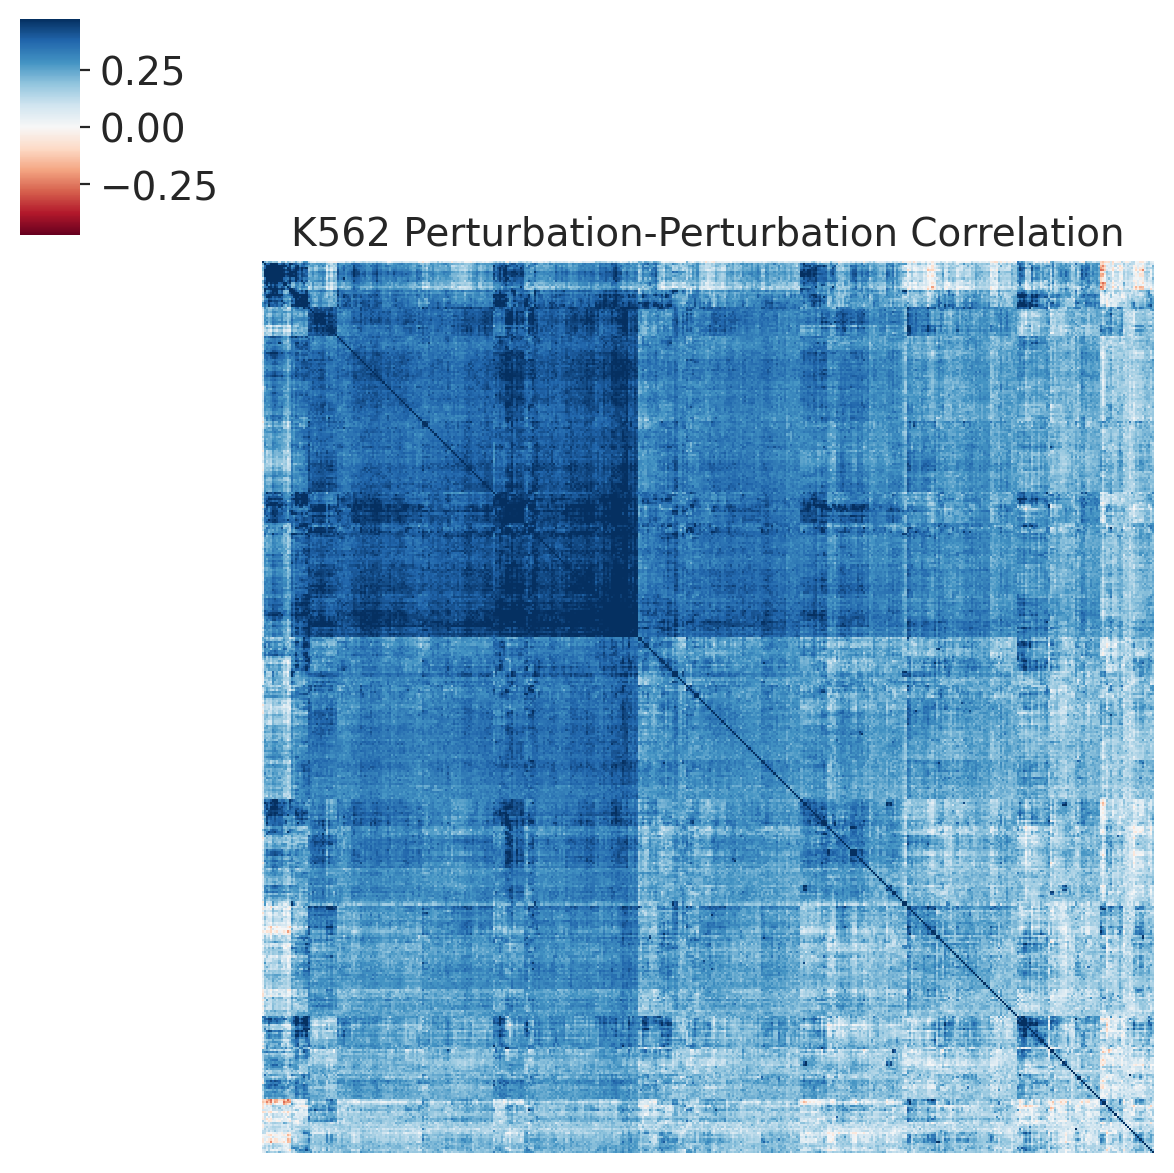

In [15]:
perturb_corr_fig, perturb_corrs, perturb_mean_profiles = \
    create_corrmatrix(adata_k562_mde, 
                      gene_target_obs_key="gene",
                      mode="perturb", 
                      figsize=(6,6),
                      title="K562 Perturbation-Perturbation Correlation")

Computing mean profiles:   0%|          | 0/429 [00:00<?, ?it/s]

Masking expression of 46 gene targets to 0


/home/ranwyl/psp_env/lib64/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
/home/ranwyl/psp_env/lib64/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.


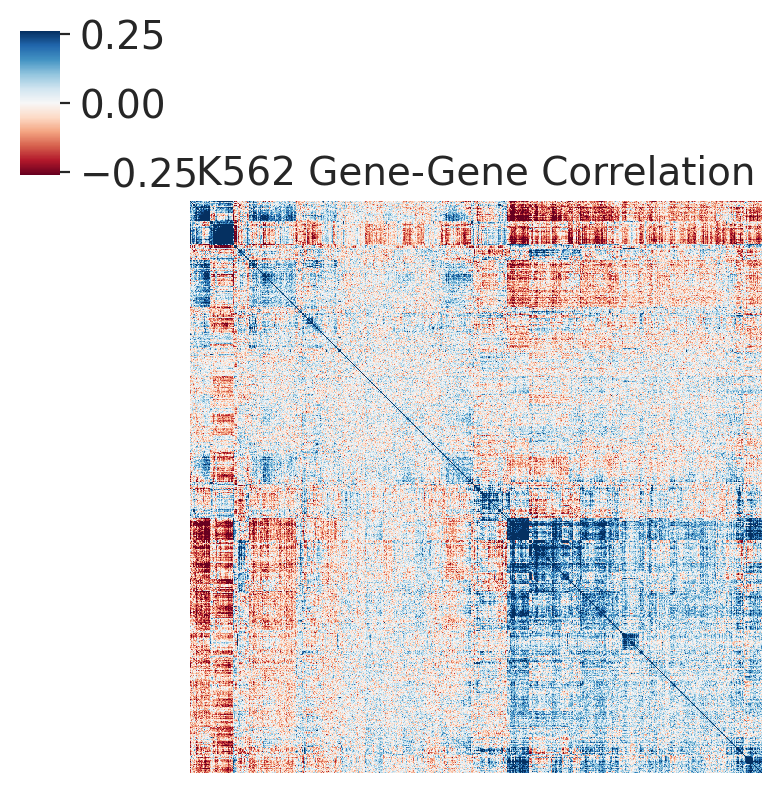

In [17]:
gene_corr_fig, gene_corrs, gene_mean_profiles = \
    create_corrmatrix(adata_k562_mde, gene_target_obs_key="gene",
                      mode="gene", figsize=(4,4),
                      title="K562 Gene-Gene Correlation")

# HBDSCAN clustering

In [16]:
from sklearn.cluster import HDBSCAN

def compute_HDBSCAN_clusters(correlations, clusterer, pallete_clustered = None, 
                             vmin = None, vmax = None, figsize=(8,8)):
    """
    Version of psp.da.compute_HDBSCAN_clusters() with figsize parameter.
    """
    labels = clusterer.fit_predict(1-correlations)
    labels_series = pd.Series(labels, index=correlations.index)
    # Map each cluster label to a distinct color
    unique_labels = sorted(labels_series.unique())
    palette = sns.color_palette("tab20", n_colors=len(unique_labels))
    lut = dict(zip(unique_labels, palette))
    row_colors = labels_series.map(lut)
    if vmin is None:
        vmin = -np.percentile(abs(correlations.values.flatten()), 98)
    if vmax is None:
        vmax = np.percentile(abs(correlations.values.flatten()), 98)
    # Plot a clustermap of the similarity matrix, annotating clusters with colored bars
    g = sns.clustermap(
        correlations,
        cmap="RdBu",
        vmin=vmin,
        vmax=vmax,
        center=0,
        row_colors=row_colors,
        col_colors=row_colors,
        xticklabels=False,
        yticklabels=False,
        figsize=figsize
    )
    # Build a legend for the cluster colors
    g.ax_row_dendrogram.set_visible(False)
    g.ax_col_dendrogram.set_visible(False)
    plt.show()
    print(f"HDBSCAN Found {labels_series.max()+1} Clusters")
    clustered_genes = labels_series[labels_series != -1].index
    sim_clustered = correlations.loc[clustered_genes, clustered_genes]
    print(f"Correlation matrix on only genes assigned a HDBScan Cluster: {len(sim_clustered)} total genes")
    labels_clustered = labels_series.loc[clustered_genes]
    unique_labels_clustered = sorted(labels_clustered.unique())
    if pallete_clustered is None:
        palette_clustered = sns.color_palette("Spectral", n_colors=len(unique_labels_clustered))
    else:
        palette_clustered = pallete_clustered
    lut_clustered = dict(zip(unique_labels_clustered, palette_clustered))
    row_colors_clustered = labels_clustered.map(lut_clustered)
    # Plot a clustermap on the clustered subset
    lim = np.percentile(abs(sim_clustered.values.flatten()), 98)
    g2 = sns.clustermap(
        sim_clustered,
        cmap="RdBu",
        vmin=-.5, vmax=.5,
        center=0,
        row_colors=row_colors_clustered,
        col_colors=row_colors_clustered,
        linewidths=0,      # <-- no lines between cells
        linecolor=None,    # <-- explicit "no line" color
        xticklabels=False,
        yticklabels=False,
        figsize=figsize
    )
    # Hide dendrograms for cleaner presentation
    g2.ax_row_dendrogram.set_visible(False)
    g2.ax_col_dendrogram.set_visible(False)
    # Plot the LUT for clustered genes only (excluding noise)
    fig_lut2, ax_lut2 = plt.subplots(figsize=(max(6, len(unique_labels_clustered) * 0.5), 1))
    for idx, label in enumerate(unique_labels_clustered):
        ax_lut2.bar(idx, 1, color=lut_clustered[label], edgecolor='none')
        ax_lut2.text(idx, 1.05, str(label), ha='center', va='bottom', fontsize=10, rotation=90)
    ax_lut2.set_xticks([])
    ax_lut2.set_yticks([])
    # Add some padding to the x-axis limits for better visualization
    padding = 0.5
    ax_lut2.set_xlim(-0.5 - padding, len(unique_labels_clustered) - 0.5 + padding)
    ax_lut2.set_title("Cluster Color LUT")
    plt.tight_layout()
    plt.show()

    return g, g2, labels_series

def compute_HDBSCAN_clusters_20d_embedding(bulks, correlations, clusterer, axis = 1, 
                                           pallete_clustered = None, figsize=(8,8)):
    """
    Version of psp.da.compute_HDBSCAN_clusters_20d_embedding() with figsize parameter.
    """
    dat = psp.da.standardize(bulks, axis = axis)
    import pymde
    pymde.seed(42)
    mde = pymde.preserve_neighbors(dat.values.T, embedding_dim=20, n_neighbors=7,repulsive_fraction=5)
    Y = mde.embed(verbose=True, eps=1e-9, max_iter=1000)
    labels = clusterer.fit_predict(Y)
    labels_series = pd.Series(labels, index=bulks.index)
    # Map each cluster label to a distinct color
    unique_labels = sorted(labels_series.unique())
    palette = sns.color_palette("tab20", n_colors=len(unique_labels))
    lut = dict(zip(unique_labels, palette))
    row_colors = labels_series.map(lut)
    lim = np.percentile(abs(correlations.values.flatten()), 98)
    # Plot a clustermap of the similarity matrix, annotating clusters with colored bars
    g = sns.clustermap(
        correlations,
        cmap="RdBu",
        vmin=-lim,
        vmax=lim,
        center=0,
        row_colors=row_colors,
        col_colors=row_colors,
        xticklabels=False,
        yticklabels=False,
        figsize=figsize
    )
    # Build a legend for the cluster colors
    g.ax_row_dendrogram.set_visible(False)
    g.ax_col_dendrogram.set_visible(False)
    plt.show()
    print(f"HDBSCAN Found {labels_series.max()+1} Clusters")
    clustered_genes = labels_series[labels_series != -1].index
    sim_clustered = correlations.loc[clustered_genes, clustered_genes]
    print(f"Correlation matrix on only genes assigned a HDBScan Cluster: {len(sim_clustered)} total genes")
    labels_clustered = labels_series.loc[clustered_genes]
    unique_labels_clustered = sorted(labels_clustered.unique())
    palette_clustered = sns.color_palette("tab20", n_colors=len(unique_labels_clustered))
    if pallete_clustered is None:
        palette_clustered = sns.color_palette("hls", n_colors=len(unique_labels_clustered))
    else:
        palette_clustered = pallete_clustered
    lut_clustered = dict(zip(unique_labels_clustered, palette_clustered))
    row_colors_clustered = labels_clustered.map(lut_clustered)
    # Plot a clustermap on the clustered subset
    lim = np.percentile(abs(sim_clustered.values.flatten()), 98)
    g2 = sns.clustermap(
        sim_clustered,
        cmap="RdBu",
        vmin=-.5, vmax=.5,
        center=0,
        row_colors=row_colors_clustered,
        col_colors=row_colors_clustered,
        linewidths=0,      # <-- no lines between cells
        linecolor=None,    # <-- explicit "no line" color   
        xticklabels=False,
        yticklabels=False,
        figsize=figsize
    )
    # Hide dendrograms for cleaner presentation
    g2.ax_row_dendrogram.set_visible(False)
    g2.ax_col_dendrogram.set_visible(False)
     # Plot the LUT for clustered genes only (excluding noise)
    fig_lut2, ax_lut2 = plt.subplots(figsize=(max(6, len(unique_labels_clustered) * 0.5), 1))
    for idx, label in enumerate(unique_labels_clustered):
        ax_lut2.bar(idx, 1, color=lut_clustered[label], edgecolor='none')
        ax_lut2.text(idx, 1.05, str(label), ha='center', va='bottom', fontsize=10, rotation=90)
    ax_lut2.set_xticks([])
    ax_lut2.set_yticks([])
    # Add some padding to the x-axis limits for better visualization
    padding = 0.5
    ax_lut2.set_xlim(-0.5 - padding, len(unique_labels_clustered) - 0.5 + padding)
    ax_lut2.set_title("Cluster Color LUT")
    plt.tight_layout()
    plt.show()
    return g, g2, labels_series

In [17]:
# Get + plot gene targets per cluster

def gene_targets_per_hdbscan_cluster(hdbscan_labels: pd.Series) -> pd.DataFrame:
    """
    Return DataFrame where each column contains the perturbations in a
    HDBSCAN cluster.
    """
    cluster_nums = sorted(list({n for n in hdbscan_labels.values if n != -1}))
    cluster_dict = dict()
    for n in cluster_nums:
        cluster_dict[n] = hdbscan_labels[hdbscan_labels == n].index.tolist()

    # Pad all columns to be the same length
    max_n_perts = max(len(cluster_dict[i]) for i in range(len(cluster_dict)))
    cluster_dict = {cluster:(perts + [np.nan]*(max_n_perts-len(perts))) 
                    for cluster, perts in cluster_dict.items()}
    perts_in_cluster_df = pd.DataFrame(cluster_dict)
    return perts_in_cluster_df

def gene_targets_per_cluster(embedding_df: pd.DataFrame,
                             cluster_col: str="leiden cluster") -> pd.DataFrame:
    """
    Return DataFrame where each column contains the perturbations in a cluster.
    """
    if cluster_col not in embedding_df.columns:
        raise ValueError("Cluster column not found in embedding DataFrame")
    cluster_num_type = type(embedding_df[cluster_col].values[0])
    
    # Get cluster numbers
    cluster_nums = {int(n) for n in embedding_df[cluster_col].values}
    cluster_nums = list(sorted(cluster_nums))
    # Remove HDBSCAN cluster -1 (outliers)
    if -1 in cluster_nums:
        cluster_nums.remove(-1)

    # Get gene targets per cluster
    cluster_dict = dict()
    for n in cluster_nums:
        if cluster_num_type == str:
            cluster = embedding_df[embedding_df[cluster_col] == str(n)]["gene_target"].tolist()
        else:
            cluster = embedding_df[embedding_df[cluster_col] == n]["gene_target"].tolist()
        cluster_dict[n] = cluster

    # Pad all columns to be the same length
    max_n_perts = max(len(cluster_dict[i]) for i in range(len(cluster_dict)))
    cluster_dict = {cluster:(perts + [np.nan]*(max_n_perts-len(perts))) 
                    for cluster, perts in cluster_dict.items()}
    perts_in_cluster_df = pd.DataFrame(cluster_dict)
    return perts_in_cluster_df

def plot_n_perts_per_cluster(perts_in_cluster_df: pd.DataFrame, 
                             title: str, 
                             figsize: tuple[int, int] = (6,3), 
                             xlabel: str="Cluster", 
                             ymax: int | None = None,
                             color: str = "tab:blue"):
    """
    Plot number of perturbations per cluster.
    """
    sns.set_style("whitegrid")
    n_perts_per_cluster = perts_in_cluster_df.count().tolist()
    print(n_perts_per_cluster)
    xvals = [i for i in range(len(n_perts_per_cluster))]
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(x=xvals, y=n_perts_per_cluster, ax=ax,
                color=color)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("# TF KDs in cluster")
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)
    ax.yaxis.set_major_formatter('{x:.0f}')
    if ymax:
        ax.set_ylim(0, ymax)
    ax.set_title(title)

In [18]:
def bulk_by_gene_target_mean(adata: ad.AnnData,
                             gene_target_obs_key: str="gene_target"):
    """
    Version of psp.da.bulk_by_gene_target_mean() that takes
    gene_target_obs_key as parameter.
    """
    # Extract expression data
    X = adata.X
    # Convert sparse matrix to dense if necessary
    if hasattr(X, 'toarray'):
        data = X.toarray()
    else:
        data = X
    # Build DataFrame (cells x genes)
    expr_df = pd.DataFrame(data, index=adata.obs.index, columns=adata.var_names)
    # Add gene_target labels
    expr_df['gene_target'] = adata.obs[gene_target_obs_key]
    # Group by gene_target and compute mean, then transpose to get genes x groups
    bulk_df = expr_df.groupby('gene_target').mean().T
    return bulk_df

Perturbation clusters

/home/ranwyl/psp_env/lib64/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
/home/ranwyl/psp_env/lib64/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.


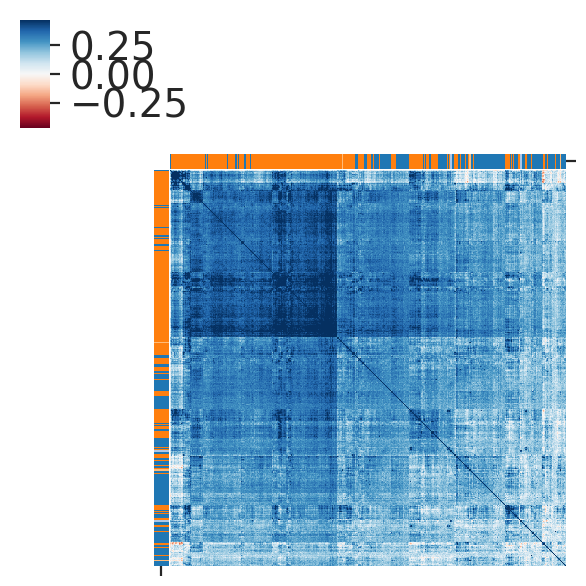

HDBSCAN Found 3 Clusters
Correlation matrix on only genes assigned a HDBScan Cluster: 268 total genes


/home/ranwyl/psp_env/lib64/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
/home/ranwyl/psp_env/lib64/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.


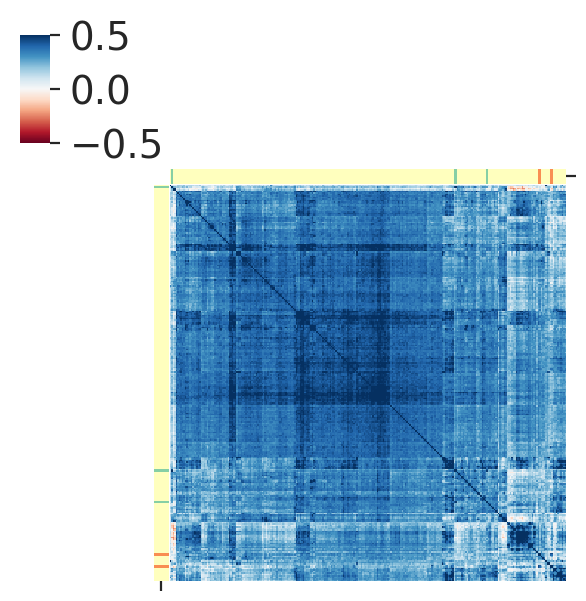

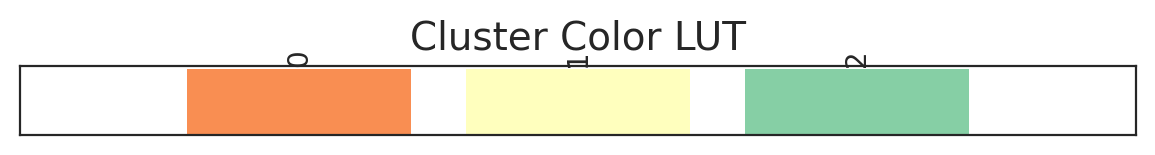

In [21]:
clusterer_perturb_eom = \
    HDBSCAN(metric='precomputed', min_cluster_size=4, cluster_selection_method='eom', min_samples=1)
fig1_eom, fig2_eom, perturbation_HDBSCAN_labels_eom = \
    compute_HDBSCAN_clusters(perturb_corrs, clusterer_perturb_eom, figsize=(3,3))

In [22]:
eom_clusters = pd.DataFrame(
    perturbation_HDBSCAN_labels_eom[perturbation_HDBSCAN_labels_eom != -1].sort_values(),
    columns=["HDBSCAN cluster (eom)"])
eom_clusters.value_counts()

HDBSCAN cluster (eom)
1                        260
0                          4
2                          4
Name: count, dtype: int64

/home/ranwyl/psp_env/lib64/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
/home/ranwyl/psp_env/lib64/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.


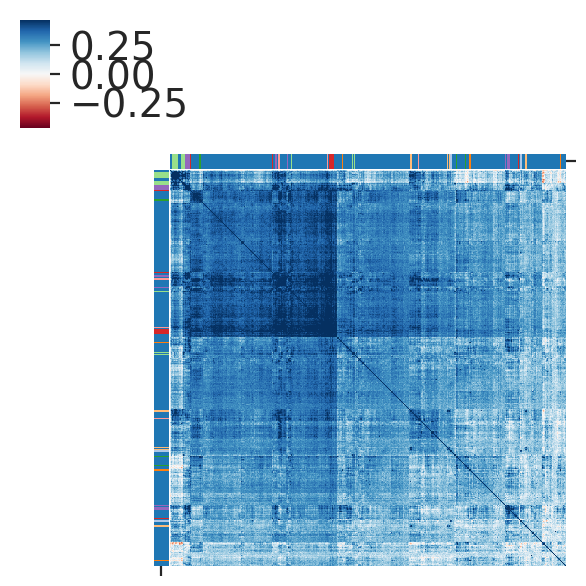

HDBSCAN Found 8 Clusters
Correlation matrix on only genes assigned a HDBScan Cluster: 58 total genes


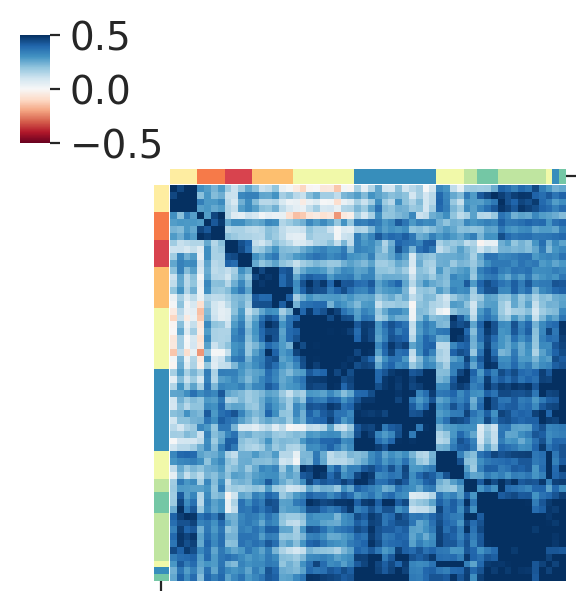

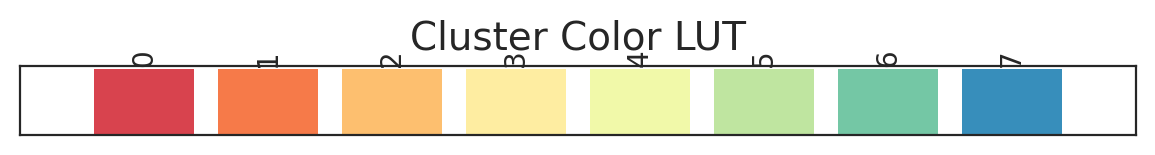

In [19]:
clusterer_perturb_leaf4 = \
    HDBSCAN(metric='precomputed', min_cluster_size=4, cluster_selection_method='leaf', min_samples=1)
fig1_leaf4, fig2_leaf4, perturbation_HDBSCAN_labels_leaf4 = \
    compute_HDBSCAN_clusters(perturb_corrs, clusterer_perturb_leaf4, figsize=(3,3))

In [24]:
leaf_clusters4 = pd.DataFrame(
    perturbation_HDBSCAN_labels_leaf4[perturbation_HDBSCAN_labels_leaf4 != -1].sort_values(),
    columns=["HDBSCAN cluster (leaf)"])
leaf_clusters4.value_counts()

HDBSCAN cluster (leaf)
4                         14
7                         13
5                          9
2                          6
3                          4
1                          4
0                          4
6                          4
Name: count, dtype: int64

In [25]:
for cl in leaf_clusters4["HDBSCAN cluster (leaf)"].unique():
    print(f"Cluster {cl}: "
          f"{', '.join(leaf_clusters4[leaf_clusters4['HDBSCAN cluster (leaf)'] == cl].index)}")

Cluster 0: TFDP1, ZBTB39, SPI1, PRMT3
Cluster 1: DR1, DRAP1, ZNF317, TBPL1
Cluster 2: UNCX, SP5, FLI1, MTF1, SNAPC5, ZBTB44
Cluster 3: E4F1, BHLHE40, MAFA, TRERF1
Cluster 4: NR2F2, ZNF236, ZNF84, TBP, ZNF787, CARF, HHEX, CPEB1, ERG, E2F8, MYSM1, HOXA3, CXXC1, ARID5B
Cluster 5: ZSCAN5A, ZNF718, TEAD3, PRDM16, AHCTF1, PHF1, NRL, SON, LIN54
Cluster 6: PRDM14, PRDM8, TAL1, HMBOX1
Cluster 7: FIGLA, FOXS1, E2F1, PRDM4, HINFP, MAX, MYB, STAT5B, ZNF560, ZNF496, ZNF414, ZNF706, ZNF687


/home/ranwyl/psp_env/lib64/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
/home/ranwyl/psp_env/lib64/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.


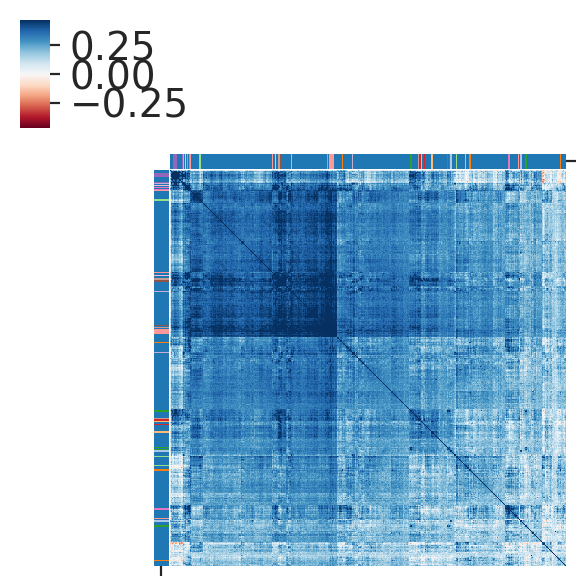

HDBSCAN Found 13 Clusters
Correlation matrix on only genes assigned a HDBScan Cluster: 56 total genes


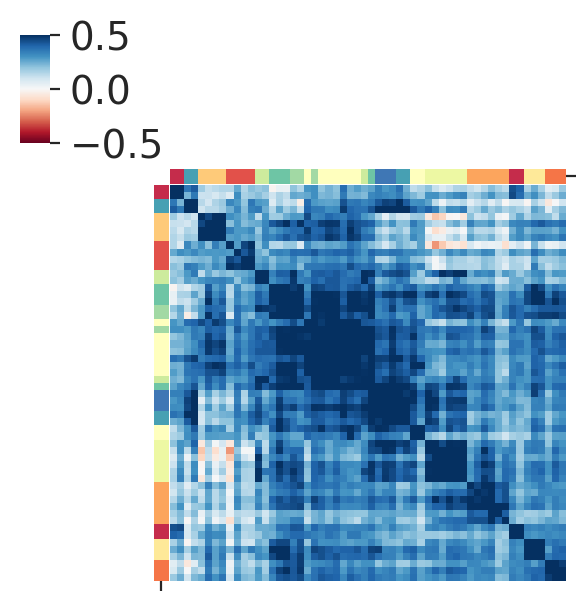

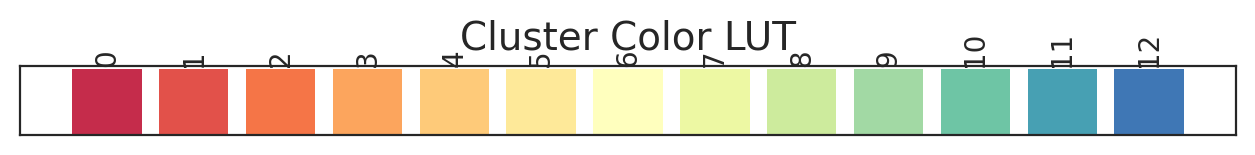

In [26]:
clusterer_perturb_leaf3 = \
    HDBSCAN(metric='precomputed', min_cluster_size=3, cluster_selection_method='leaf', min_samples=1)
fig1_leaf3, fig2_leaf3, perturbation_HDBSCAN_labels_leaf3 = \
    compute_HDBSCAN_clusters(perturb_corrs, clusterer_perturb_leaf3, figsize=(3,3))

In [27]:
leaf_clusters3 = pd.DataFrame(
    perturbation_HDBSCAN_labels_leaf3[perturbation_HDBSCAN_labels_leaf3 != -1].sort_values(),
    columns=["HDBSCAN cluster (leaf)"])
leaf_clusters3.value_counts()

HDBSCAN cluster (leaf)
6                         9
7                         6
3                         6
0                         4
1                         4
11                        4
4                         4
10                        4
2                         3
8                         3
5                         3
9                         3
12                        3
Name: count, dtype: int64

In [28]:
for cl in leaf_clusters3["HDBSCAN cluster (leaf)"].unique():
    print(f"Cluster {cl}: "
          f"{', '.join(leaf_clusters3[leaf_clusters3['HDBSCAN cluster (leaf)'] == cl].index)}")

Cluster 0: PRMT3, ZBTB39, TFDP1, SPI1
Cluster 1: TBPL1, DRAP1, DR1, ZNF317
Cluster 2: PRDM13, FOXG1, IKZF2
Cluster 3: UNCX, SNAPC5, SP5, FLI1, MTF1, ZBTB44
Cluster 4: BHLHE40, E4F1, MAFA, TRERF1
Cluster 5: RBPJL, ZNF704, ETV4
Cluster 6: PRDM16, SON, PHF1, NRL, ZSCAN5A, TEAD3, AHCTF1, LIN54, ZNF718
Cluster 7: HOXA3, ARID5B, CPEB1, ZNF236, ZNF84, TBP
Cluster 8: ZNF787, CARF, ERG
Cluster 9: TP73, STAT5A, KIN
Cluster 10: HMBOX1, PRDM14, PRDM8, TAL1
Cluster 11: STAT5B, MAX, ZNF414, ZNF706
Cluster 12: PRDM4, MYB, ZNF560


In [20]:
perturbation_HDBSCAN_labels = perturbation_HDBSCAN_labels_leaf4

In [21]:
hdbscan_cluster_kds = gene_targets_per_hdbscan_cluster(perturbation_HDBSCAN_labels)
hdbscan_cluster_kds

,0,1,2,3,4,5,6,7
0,PRMT3,DR1,FLI1,BHLHE40,ARID5B,AHCTF1,HMBOX1,E2F1
1,SPI1,DRAP1,MTF1,E4F1,CARF,LIN54,PRDM8,FIGLA
2,TFDP1,TBPL1,SNAPC5,MAFA,CPEB1,NRL,PRDM14,FOXS1
3,ZBTB39,ZNF317,SP5,TRERF1,CXXC1,PHF1,TAL1,HINFP
4,NaN,NaN,UNCX,NaN,E2F8,PRDM16,NaN,MAX
5,NaN,NaN,ZBTB44,NaN,ERG,SON,NaN,MYB
6,NaN,NaN,NaN,NaN,HHEX,TEAD3,NaN,PRDM4
7,NaN,NaN,NaN,NaN,HOXA3,ZNF718,NaN,STAT5B
8,NaN,NaN,NaN,NaN,MYSM1,ZSCAN5A,NaN,ZNF414
9,NaN,NaN,NaN,NaN,NR2F2,NaN,NaN,ZNF496


[4, 4, 6, 4, 14, 9, 4, 13]


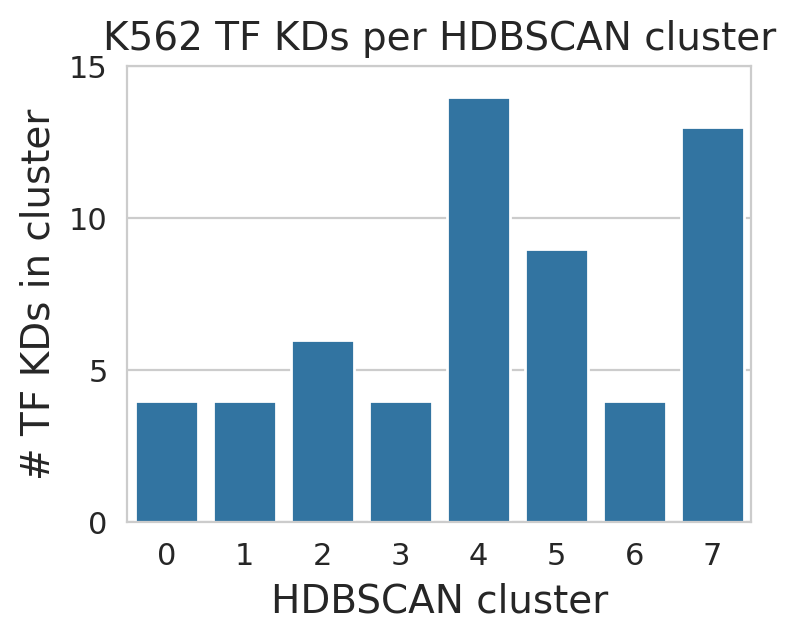

In [31]:
_ = plot_n_perts_per_cluster(hdbscan_cluster_kds,
                             title="K562 TF KDs per HDBSCAN cluster",
                             xlabel="HDBSCAN cluster", figsize=(4,3),
                             ymax=15)

In [32]:
hdbscan_filepath = "/home/ranwyl/output_files_tf_project/K562_hdbscan_clusters_6-3-26.csv"
hdbscan_cluster_kds.to_csv(hdbscan_filepath)

In [33]:
hdbscan_filepath = "/home/ranwyl/output_files_tf_project/K562_hdbscan_clusters_6-3-26.csv"
hdbscan_cluster_kds_display = pd.read_csv(hdbscan_filepath, index_col=0, keep_default_na=False)
hdbscan_cluster_kds_display

,0,1,2,3,4,5,6,7
0,PRMT3,DR1,FLI1,BHLHE40,ARID5B,AHCTF1,HMBOX1,E2F1
1,SPI1,DRAP1,MTF1,E4F1,CARF,LIN54,PRDM8,FIGLA
2,TFDP1,TBPL1,SNAPC5,MAFA,CPEB1,NRL,PRDM14,FOXS1
3,ZBTB39,ZNF317,SP5,TRERF1,CXXC1,PHF1,TAL1,HINFP
4,,,UNCX,,E2F8,PRDM16,,MAX
5,,,ZBTB44,,ERG,SON,,MYB
6,,,,,HHEX,TEAD3,,PRDM4
7,,,,,HOXA3,ZNF718,,STAT5B
8,,,,,MYSM1,ZSCAN5A,,ZNF414
9,,,,,NR2F2,,,ZNF496


In [22]:
bulks_mde = bulk_by_gene_target_mean(adata_k562_mde, gene_target_obs_key="gene")

Gene clusters

In [ ]:
clusterer_gene = \
    HDBSCAN(metric='euclidean', min_cluster_size=10, cluster_selection_method='leaf', min_samples=1)
fig1, fig2, gene_HDBSCAN_labels = \
    compute_HDBSCAN_clusters_20d_embedding(bulks_mde, gene_corrs, clusterer_gene, figsize=(6,6))

# CORUM complexes

In [44]:
def build_corum_complex_gene_dict(corum_txt_filepath: str) -> dict[str, list[str]]:
    """
    From a CORUM complex .txt file, build dict of each CORUM complex ID 
    mapped to a list of its genes. Uses code from psp.da.annotate_clusters()
    """
    corum_table = pd.read_csv(corum_txt_filepath, sep='\t')
    complexes = {
        name: subs.split(';')
        for name, subs in zip(corum_table['complex_name'],
                              corum_table['subunits_gene_name'])
    }
    return complexes

In [45]:
def find_corum_complexes_in_clusters(corum_complexes_perturb: list[tuple[str, str]],
                                     cluster_kds_df: pd.DataFrame,
                                     cluster_type: str="Leiden"):
    df_cl_nums, df_complexes = list(), list()
    for complex in corum_complexes_perturb:
        protein1, protein2 = complex
        if protein1 in cluster_kds_df.values:
            protein1_cl = cluster_kds_df.columns[cluster_kds_df.eq(protein1).any()][0]
        else:
            protein1_cl = None
        if protein2 in cluster_kds_df.values:
            protein2_cl = cluster_kds_df.columns[cluster_kds_df.eq(protein2).any()][0]
        else:
            protein2_cl = None
        if protein1_cl is None or protein2_cl is None:
            continue
        if protein1_cl == protein2_cl:
            df_cl_nums.append(protein1_cl)
            df_complexes.append(f"{protein1}-{protein2}")
    corum_df = pd.DataFrame({f"{cluster_type} cluster": df_cl_nums,
                             "CORUM complex": df_complexes})
    return corum_df

In [46]:
corum_filepath = "/home/ranwyl/reference_tf_project/corum_humanComplexes.txt"
corum_complexes = build_corum_complex_gene_dict(corum_filepath)

In [48]:
corum_perturb, non_corum_perturb = \
    psp.da.get_corum_perturbation_pairs_from_list(perturb_corrs.columns.unique(), corum_complexes)

22 CORUM complexes present


Mann-Whitney U statistic: 989888.0, p-value: 0.5433320575440728


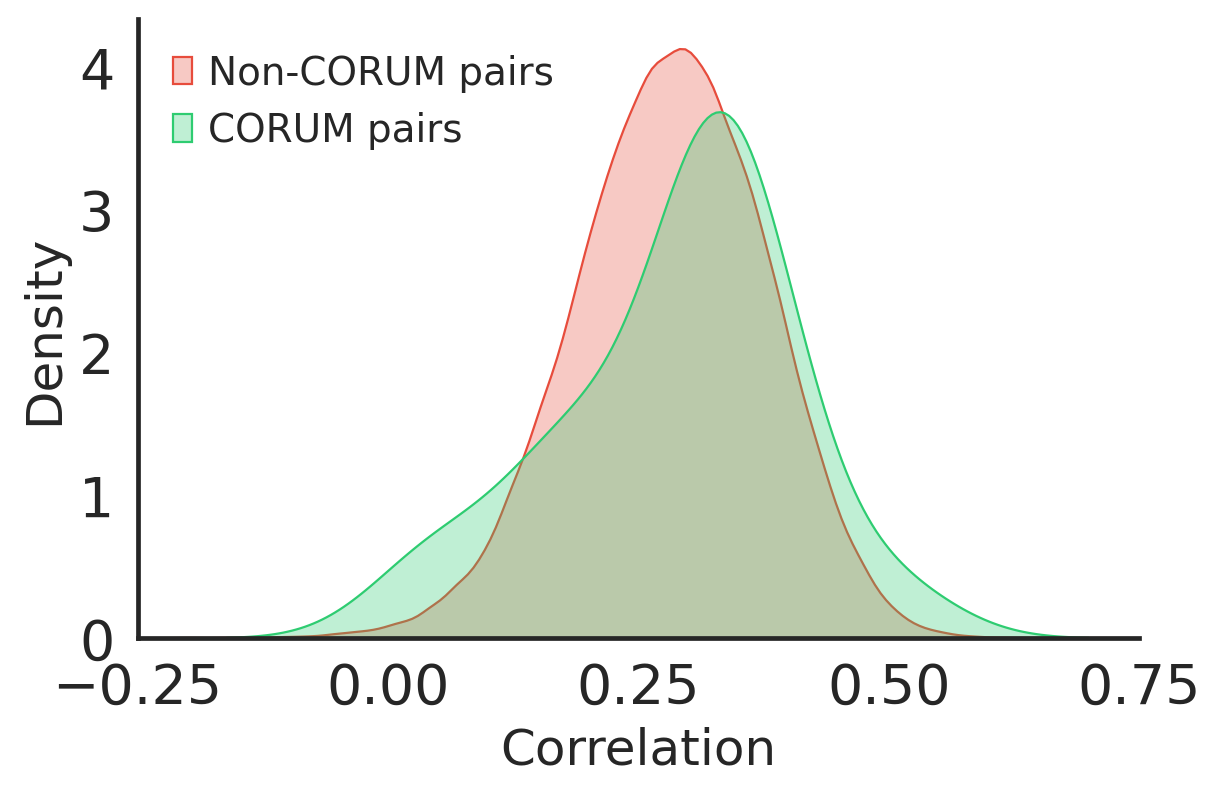

In [49]:
corum_perturb_fig, corum_perturb_u_stat, corum_perturb_p_value = \
    psp.da.benchmark_corum_vs_noncorum_pairs(perturb_corrs, corum_perturb, non_corum_perturb)

In [39]:
print(len(corum_perturb))
print(corum_perturb[:5])

20
[('E2F1', 'TFDP1'), ('ERG', 'FOS'), ('FOXG1', 'FOXO3'), ('FOXG1', 'SMAD4'), ('FOXO1', 'SMAD4')]


In [40]:
hdbscan_corum_df = find_corum_complexes_in_clusters(corum_perturb, hdbscan_cluster_kds, "HDBSCAN")
hdbscan_corum_df

,HDBSCAN cluster,CORUM complex


# Minimum Distortion Embedding Functions

In [23]:
# Generate embeddings

from sklearn.manifold import SpectralEmbedding
import pymde
import leidenalg
import igraph as ig
from sklearn.neighbors import kneighbors_graph

def embed_spectral_mde(mp_standardized, 
                       n_components: int=20,
                       spectral_n_neighbors: int=25,
                       mde_n_neighbors: int=7, 
                       repulsive_fraction: float=5,
                       random_state: int=42):
    """
    Function from psp KOLF_Perturbation_Atlas_Data_Analysis.ipynb 
    example notebook. Modified to take spectral_n_neighbors as arg.
    """
    embedder = SpectralEmbedding(
        n_components=n_components,
        n_neighbors=spectral_n_neighbors,
        affinity='nearest_neighbors',
        eigen_solver='arpack',
        random_state=random_state,
    )
    X = embedder.fit_transform(mp_standardized)
    pymde.seed(random_state)
    mde = pymde.preserve_neighbors(X, embedding_dim=2, 
                                   n_neighbors=mde_n_neighbors,
                                   repulsive_fraction=repulsive_fraction)
    Y = mde.embed(verbose=True, eps=1e-9, max_iter=2000)
    return Y

def build_mde_df(Y, bulk_df, perturbation_HDBSCAN_labels, n_neighbors=6, seed=12):
    # --- 1) Leiden clustering on the 2D coords ---
    knn_graph = kneighbors_graph(Y, n_neighbors=n_neighbors, include_self=False)
    sources, targets = knn_graph.nonzero()
    g = ig.Graph(directed=False)
    g.add_vertices(Y.shape[0])
    g.add_edges(list(zip(sources, targets)))
    partition = leidenalg.find_partition(
        g,
        leidenalg.RBConfigurationVertexPartition,
        seed=seed
    )
    leiden_labels = np.array(partition.membership)

    # --- 2) Build embedding_df ---
    embedding_df = pd.DataFrame(Y, columns=['x', 'y'])
    embedding_df['gene_target']    = bulk_df.columns
    embedding_df['leiden cluster'] = leiden_labels.astype(str)
    hdbscan_map = dict(perturbation_HDBSCAN_labels)
    embedding_df['hdbscan cluster'] = embedding_df['gene_target'].map(hdbscan_map)
    embedding_df.index = embedding_df['gene_target']

    # order the Leiden labels numerically
    leiden_cats = sorted(embedding_df['leiden cluster'].unique(), key=lambda x: int(x))
    embedding_df['leiden cluster'] = pd.Categorical(
        embedding_df['leiden cluster'],
        categories=leiden_cats,
        ordered=True
    )
    return embedding_df

In [24]:
# Choosing k for KNN graph (cluster agreement, silhouette scores)

import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_mutual_info_score, adjusted_rand_score
import igraph as ig
import leidenalg
from sklearn.neighbors import kneighbors_graph
from sklearn.metrics import silhouette_score

def plot_cluster_agreement(Y, perturbation_HDBSCAN_labels, title):
    """
    Version of psp.da.plot_cluster_agreement() that returns
    DataFrame of ARI and AMI results.
    """
    # Make everything deterministic
    seed = 42
    random.seed(seed)
    np.random.seed(seed)

    sns.set(style="whitegrid", font_scale=1.2)

    # Define neighbor sizes to test
    neighbor_sizes = list(range(2, 20))

    # Restrict to points assigned by HDBSCAN
    mask = perturbation_HDBSCAN_labels >= 0
    hdb_labels = perturbation_HDBSCAN_labels[mask].values

    # Evaluate clustering agreement for each neighbor size
    ari_scores = []
    ami_scores = []
    for k in neighbor_sizes:
        knn_graph = kneighbors_graph(Y, n_neighbors=k, include_self=False)
        sources, targets = knn_graph.nonzero()
        g = ig.Graph(directed=False)
        g.add_vertices(Y.shape[0])
        g.add_edges(list(zip(sources, targets)))
        # Leiden clustering with fixed seed
        partition = leidenalg.find_partition(
            g,
            leidenalg.RBConfigurationVertexPartition,
            seed=seed
        )
        leiden_labels = np.array(partition.membership)
        # Compute metrics
        ari_scores.append(adjusted_rand_score(hdb_labels, leiden_labels[mask]))
        ami_scores.append(adjusted_mutual_info_score(hdb_labels, leiden_labels[mask]))

    # Plot results
    plt.figure(figsize=(6,4))
    plt.plot(neighbor_sizes, ari_scores, marker='o', linestyle='-', color='C0', label='ARI')
    plt.plot(neighbor_sizes, ami_scores, marker='s', linestyle='--', color='C1', label='AMI')
    plt.xlabel('Number of Leiden Neighbors (k)')
    plt.ylabel('Adjusted score')
    if title:
        plt.title(title)
    else:
        plt.title('Clustering agreement vs. k (Leiden vs. HDBSCAN)')
    plt.xticks(neighbor_sizes)
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Create DataFrame
    score_df = pd.DataFrame({"ARI": ari_scores, "AMI": ami_scores},
                            index=neighbor_sizes)
    return score_df

def plot_silhouette_scores(Y, title):
    """
    Plot silhouette score of MDE Leiden clustering
    for each specified number of neighbors for KNN graph.
    """
    seed=12
    sns.set(style="whitegrid", font_scale=1.2)

    # Define neighbor sizes to test
    neighbor_sizes = list(range(2, 20))

    # Evaluate clustering agreement for each neighbor size
    s_scores = []
    for k in neighbor_sizes:
        knn_graph = kneighbors_graph(Y, n_neighbors=k, include_self=False)
        sources, targets = knn_graph.nonzero()
        g = ig.Graph(directed=False)
        g.add_vertices(Y.shape[0])
        g.add_edges(list(zip(sources, targets)))
        # Leiden clustering with fixed seed
        partition = leidenalg.find_partition(
            g,
            leidenalg.RBConfigurationVertexPartition,
            seed=seed
        )
        leiden_labels = np.array(partition.membership)
        # Compute metrics
        s_scores.append(silhouette_score(Y, labels=leiden_labels, random_state=seed))

    # Plot results
    plt.figure(figsize=(6,4))
    plt.plot(neighbor_sizes, s_scores, marker='o', linestyle='-', color='tab:red')
    plt.xlabel('Number of Leiden Neighbors (k)')
    plt.ylabel('Silhouette score')
    if title:
        plt.title(title)
    else:
        plt.title('Silhouette score vs. k')
    plt.xticks(neighbor_sizes)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

    # Create DataFrame
    score_df = pd.DataFrame({"Silhouette score": s_scores},
                            index=neighbor_sizes)
    return score_df

In [25]:
# Plots
from sklearn.neighbors import kneighbors_graph
import igraph as ig 
import plotly.express as px 
import leidenalg 
from scipy.spatial.distance import pdist, squareform

# Pairwise dist mtx of Leiden cluster centroids
def plot_pairwise_distance_matrix(Y, bulk_df, n_neighbors = 6, seed = 12,
                                  figsize=(6,6), tick_fontsize = 10, title_fontsize=14,
                                  title_y_position=1.02,
                                  title="Pairwise Distance Matrix of Leiden Cluster Centroids"):
    # KNN graph and Leiden clustering
    knn_graph = kneighbors_graph(Y, n_neighbors=n_neighbors, include_self=False)
    sources, targets = knn_graph.nonzero()
    g = ig.Graph(directed=False)
    g.add_vertices(Y.shape[0])
    g.add_edges(list(zip(sources, targets)))
    partition = leidenalg.find_partition(
        g,
        leidenalg.RBConfigurationVertexPartition,
        seed=seed
    )
    leiden_labels = np.array(partition.membership)

    # Pairwise distance matrix of cluster centroids
    embedding_df = pd.DataFrame(Y, columns=['x', 'y'])
    embedding_df['gene_target'] = bulk_df.columns
    embedding_df['cluster'] = leiden_labels
    embedding_df['cluster'] = embedding_df['cluster'].astype(str)
    cluster_groups = embedding_df.groupby('cluster')
    centroids = cluster_groups[['x', 'y']].mean()
    pairwise_distances = pd.DataFrame(
        squareform(pdist(centroids, metric='euclidean')),
        index=centroids.index,
        columns=centroids.index
    )
    sns.set_style("white")
    ax = sns.clustermap(pairwise_distances, cmap='PuBuGn', figsize=figsize,
                        xticklabels=True, yticklabels=True)
    ax.ax_heatmap.tick_params(right=True, bottom=True, labelsize=tick_fontsize)
    ax.fig.suptitle(title, fontsize=title_fontsize, y=title_y_position)
    plt.show()

# MDE plots
def plot_mde_interactive(Y, bulk_df, perturbation_HDBSCAN_labels,
                         n_neighbors=6, seed=12, save_dir_stem=None,
                         marker_size = 7, marker_opacity = 0.7,
                         color_sequence = "Dark24", 
                         title = 'Minimum Distortion Embedding of Mean Normalized Profiles'):
    """
    Plot MDE (interactive version using plotly) with the specified color sequence 
    (Dark24, Bold, Prism, or Vivid). Modified from psp.da.plot_mde().
    """
    # --- 1) Leiden clustering on the 2D coords ---
    knn_graph = kneighbors_graph(Y, n_neighbors=n_neighbors, include_self=False)
    sources, targets = knn_graph.nonzero()
    g = ig.Graph(directed=False)
    g.add_vertices(Y.shape[0])
    g.add_edges(list(zip(sources, targets)))
    partition = leidenalg.find_partition(
        g,
        leidenalg.RBConfigurationVertexPartition,
        seed=seed
    )
    leiden_labels = np.array(partition.membership)

    # --- 2) Build embedding_df ---
    embedding_df = pd.DataFrame(Y, columns=['x', 'y'])
    embedding_df['gene_target']    = bulk_df.columns
    embedding_df['leiden cluster'] = leiden_labels.astype(str)
    hdbscan_map = dict(perturbation_HDBSCAN_labels)
    embedding_df['hdbscan cluster'] = embedding_df['gene_target'].map(hdbscan_map)
    embedding_df.index = embedding_df['gene_target']

    # order the Leiden labels numerically
    leiden_cats = sorted(embedding_df['leiden cluster'].unique(), key=lambda x: int(x))
    embedding_df['leiden cluster'] = pd.Categorical(
        embedding_df['leiden cluster'],
        categories=leiden_cats,
        ordered=True
    )

    # --- 3) Interactive Plotly scatter ---
    if color_sequence.lower() == "dark24":
        color_discrete_sequence=px.colors.qualitative.Dark24
    elif color_sequence.lower() == "bold":
        color_discrete_sequence=px.colors.qualitative.Bold
    elif color_sequence.lower() == "prism":
        color_discrete_sequence=px.colors.qualitative.Prism
    elif color_sequence.lower() == "vivid":
        color_discrete_sequence=px.colors.qualitative.Vivid 
    fig = px.scatter(
        embedding_df,
        x='x', y='y',
        text='gene_target',
        color='leiden cluster',
        category_orders={'leiden cluster': leiden_cats},
        hover_data=['x', 'y', 'gene_target', 'hdbscan cluster'],
        title=title,
        color_discrete_sequence=color_discrete_sequence
    )
    fig.update_traces(
        marker=dict(size=marker_size, opacity=marker_opacity),
        textposition='middle center',
        textfont=dict(size=1)
    )
    fig.update_layout(
        showlegend=True,
        legend=dict(traceorder='normal'),
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        plot_bgcolor='white',
        width=1200,
        height=1000,
        legend_title_text='Leiden Cluster',
        coloraxis_showscale=False
    )

    import plotly.io as pio #type: ignore
    if save_dir_stem is not None:
        pio.write_html(fig, file=save_dir_stem+"_MDE.html", include_plotlyjs="inline",full_html=True)
        embedding_df.to_excel(save_dir_stem+"_MDE_clusters.xlsx", index=False)
    fig.show()
    return embedding_df

def plot_mde_static(Y, bulk_df, n_neighbors = 6, seed = 12, save_dir_stem = None,
                    figsize=(8,6), legend_ncol = 1, title_fontsize=14,
                    title = 'Minimum Distortion Embedding of Mean Normalized Profiles'):
    """
    Plot MDE (static version using matplotlib). Modified from psp.da.plot_mde().
    """
    # --- 1) Leiden clustering on the 2D coords ---
    knn_graph = kneighbors_graph(Y, n_neighbors=n_neighbors, include_self=False)
    sources, targets = knn_graph.nonzero()
    g = ig.Graph(directed=False)
    g.add_vertices(Y.shape[0])
    g.add_edges(list(zip(sources, targets)))
    partition = leidenalg.find_partition(
        g,
        leidenalg.RBConfigurationVertexPartition,
        seed=seed
    )
    leiden_labels = np.array(partition.membership)

    # --- 2) Build embedding_df ---
    embedding_df = pd.DataFrame(Y, columns=['x', 'y'])
    embedding_df['gene_target']    = bulk_df.columns
    embedding_df['leiden cluster'] = leiden_labels.astype(str)
    embedding_df.index = embedding_df['gene_target']

    # order the Leiden labels numerically
    leiden_cats = sorted(embedding_df['leiden cluster'].unique(), key=lambda x: int(x))
    embedding_df['leiden cluster'] = pd.Categorical(
        embedding_df['leiden cluster'],
        categories=leiden_cats,
        ordered=True
    )

    # convert Plotly Dark24 colors to matplotlib-friendly RGB tuples
    plotly_color_list = px.colors.qualitative.Dark24
    leiden_colors = [px.colors.unconvert_from_RGB_255(px.colors.hex_to_rgb(c)) 
                    for c in plotly_color_list]
    leiden_colors = [leiden_colors[i % len(leiden_colors)] for i in range(len(leiden_cats))]

    # seaborn clean style
    sns.set_style('white')
    sns.set_style({'axes.grid': False})

    # --- 4) Static 1×4 Matplotlib figure ---
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # Panel 1: Leiden clusters
    for i, lc in enumerate(leiden_cats):
        sel = embedding_df['leiden cluster'] == lc
        ax.scatter(
            embedding_df.loc[sel, 'x'],
            embedding_df.loc[sel, 'y'],
            color=leiden_colors[i],
            s=13,
            alpha=0.8,
            edgecolor='white',
            linewidth=0.3,
            zorder=2,
            label=f"{lc}"
        )
    ax.set_title(title, fontsize=title_fontsize)
    ax.set_xticks([]); ax.set_yticks([])
    sns.despine(ax=ax, left=True, bottom=True)

    ax.legend(
        bbox_to_anchor=(0.95, 1),
        loc='upper left',
        borderaxespad=0,
        frameon=False,
        title='Leiden Cluster',
        fontsize=10,
        ncol=legend_ncol
    )

    plt.tight_layout()
    plt.show()
    if save_dir_stem is not None:
        fig.savefig(save_dir_stem + "_MDE_views.svg", format='svg', bbox_inches='tight')

def plot_mde_leiden_hdbscan(Y, perturbation_HDBSCAN_labels, bulk_df, n_neighbors = 6, 
                            seed = 12, save_dir_stem = None, legend_ncol=1,
                            suptitle="Minimum Distortion Embedding Leiden and HDBSCAN Clusters",
                            suptitle_fontsize=14):
    """
    Generate 2-panel figure where panel 1 is MDE and panel 2 is
    overlay of HDBSCAN clusters over MDE.
    """
    # --- 1) Leiden clustering on the 2D coords ---
    knn_graph = kneighbors_graph(Y, n_neighbors=n_neighbors, include_self=False)
    sources, targets = knn_graph.nonzero()
    g = ig.Graph(directed=False)
    g.add_vertices(Y.shape[0])
    g.add_edges(list(zip(sources, targets)))
    partition = leidenalg.find_partition(
        g,
        leidenalg.RBConfigurationVertexPartition,
        seed=seed
    )
    leiden_labels = np.array(partition.membership)

    # --- 2) Build embedding_df ---
    embedding_df = pd.DataFrame(Y, columns=['x', 'y'])
    embedding_df['gene_target']    = bulk_df.columns
    embedding_df['leiden cluster'] = leiden_labels.astype(str)
    hdbscan_map = dict(perturbation_HDBSCAN_labels)
    embedding_df['hdbscan cluster'] = embedding_df['gene_target'].map(hdbscan_map)
    embedding_df.index = embedding_df['gene_target']

    # order the Leiden labels numerically
    leiden_cats = sorted(embedding_df['leiden cluster'].unique(), key=lambda x: int(x))
    embedding_df['leiden cluster'] = pd.Categorical(
        embedding_df['leiden cluster'],
        categories=leiden_cats,
        ordered=True
    )

    # convert Plotly Dark24 colors to matplotlib-friendly RGB tuples
    plotly_color_list = px.colors.qualitative.Dark24
    leiden_colors = [px.colors.unconvert_from_RGB_255(px.colors.hex_to_rgb(c)) 
                    for c in plotly_color_list]
    leiden_colors = [leiden_colors[i % len(leiden_colors)] for i in range(len(leiden_cats))]

    # HDBSCAN palette (exclude noise = -1)
    hdb          = embedding_df['hdbscan cluster']
    hdb_clusters = sorted(c for c in hdb.unique() if c != -1)
    hdb_palette  = sns.color_palette('tab10', len(hdb_clusters))

    # seaborn clean style
    sns.set_style('white')
    sns.set_style({'axes.grid': False})


    # --- 4) Static 1×4 Matplotlib figure ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

    # Panel 1: Leiden clusters
    ax = axes[0]
    for i, lc in enumerate(leiden_cats):
        sel = embedding_df['leiden cluster'] == lc
        ax.scatter(
            embedding_df.loc[sel, 'x'],
            embedding_df.loc[sel, 'y'],
            color=leiden_colors[i],
            s=13,
            alpha=0.8,
            edgecolor='white',
            linewidth=0.3,
            zorder=2,
            label=f"{lc}"
        )
    ax.set_title('Leiden clusters')
    ax.set_xticks([]); ax.set_yticks([])
    sns.despine(ax=ax, left=True, bottom=True)

    ax.legend(
        bbox_to_anchor=(0.95, 1),
        loc='upper left',
        borderaxespad=0,
        frameon=False,
        title='Leiden Cluster',
        fontsize=10,
        ncol=legend_ncol
    )

    # Panel 2: HDBSCAN clusters (with legend)
    ax = axes[1]

    # Noise points (-1)
    ax.scatter(
        embedding_df.loc[hdb == -1, 'x'],
        embedding_df.loc[hdb == -1, 'y'],
        color='lightgray',
        edgecolor='white',
        s=13,
        alpha=0.5,
        zorder=1,
        # label='Noise (-1)'
    )

    # Actual HDBSCAN clusters
    for i, hc in enumerate(hdb_clusters):
        sel = (hdb == hc)
        ax.scatter(
            embedding_df.loc[sel, 'x'],
            embedding_df.loc[sel, 'y'],
            color=hdb_palette[i],
            s=14,
            alpha=0.8,
            edgecolor='white',
            linewidth=0.3,
            zorder=2,
            label=f'{hc}'
        )

    ax.set_title('HDBSCAN clusters')
    ax.set_xticks([]); ax.set_yticks([])
    sns.despine(ax=ax, left=True, bottom=True)

    ax.legend(
        bbox_to_anchor=(0.85, 1),
        loc='upper left',
        borderaxespad=0,
        frameon=False,
        title='HDBSCAN Cluster',
        fontsize=10
    )
    
    if suptitle:
        plt.suptitle(suptitle, fontsize=suptitle_fontsize)
    plt.tight_layout()
    plt.show()
    if save_dir_stem is not None:
        fig.savefig(save_dir_stem + "_MDE_views.svg", format='svg', bbox_inches='tight')
    return embedding_df

def plot_mde_leiden_corum(Y, bulk_df, corum_complexes = None, n_neighbors = 6, 
                        seed = 12, save_dir_stem = None, legend_ncol=1,
                        suptitle="Minimum Distortion Embedding Leiden Clusters and CORUM Complexes",
                        suptitle_fontsize=14):
    """
    Generate 2-panel figure where panel 1 is MDE and panel 2 is
    overlay of CORUM complexes over MDE.
    """
    corum, _ = psp.da.get_corum_perturbation_pairs_from_list(bulk_df.columns.unique(), corum_complexes)

    # --- 1) Leiden clustering on the 2D coords ---
    knn_graph = kneighbors_graph(Y, n_neighbors=n_neighbors, include_self=False)
    sources, targets = knn_graph.nonzero()
    g = ig.Graph(directed=False)
    g.add_vertices(Y.shape[0])
    g.add_edges(list(zip(sources, targets)))
    partition = leidenalg.find_partition(
        g,
        leidenalg.RBConfigurationVertexPartition,
        seed=seed
    )
    leiden_labels = np.array(partition.membership)

    # --- 2) Build embedding_df ---
    embedding_df = pd.DataFrame(Y, columns=['x', 'y'])
    embedding_df['gene_target']    = bulk_df.columns
    embedding_df['leiden cluster'] = leiden_labels.astype(str)
    embedding_df.index = embedding_df['gene_target']

    # order the Leiden labels numerically
    leiden_cats = sorted(embedding_df['leiden cluster'].unique(), key=lambda x: int(x))
    embedding_df['leiden cluster'] = pd.Categorical(
        embedding_df['leiden cluster'],
        categories=leiden_cats,
        ordered=True
    )

    # convert Plotly Dark24 colors to matplotlib-friendly RGB tuples
    plotly_color_list = px.colors.qualitative.Dark24
    leiden_colors = [px.colors.unconvert_from_RGB_255(px.colors.hex_to_rgb(c)) 
                    for c in plotly_color_list]
    leiden_colors = [leiden_colors[i % len(leiden_colors)] for i in range(len(leiden_cats))]

    # CORUM
    corum_genes = {g for pair in corum for g in pair}
    is_in_corum  = embedding_df['gene_target'].isin(corum_genes)
    coords       = embedding_df.set_index('gene_target')[['x','y']]

    # seaborn clean style
    sns.set_style('white')
    sns.set_style({'axes.grid': False})


    # --- 4) Static 1×4 Matplotlib figure ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

    # Panel 1: Leiden clusters
    ax = axes[0]
    for i, lc in enumerate(leiden_cats):
        sel = embedding_df['leiden cluster'] == lc
        ax.scatter(
            embedding_df.loc[sel, 'x'],
            embedding_df.loc[sel, 'y'],
            color=leiden_colors[i],
            s=13,
            alpha=0.8,
            edgecolor='white',
            linewidth=0.3,
            zorder=2,
            label=f"{lc}"
        )
    ax.set_title('Leiden clusters')
    ax.set_xticks([]); ax.set_yticks([])
    sns.despine(ax=ax, left=True, bottom=True)

    ax.legend(
        bbox_to_anchor=(0.95, 1),
        loc='upper left',
        borderaxespad=0,
        frameon=False,
        title='Leiden Cluster',
        fontsize=10,
        ncol=legend_ncol
    )

    # Panel 2: CORUM membership (solid dark‑blue dots)
    ax = axes[1]
    # draw CORUM lines behind
    for g1, g2 in corum:
        if g1 in coords.index and g2 in coords.index:
            x1, y1 = coords.loc[g1]
            x2, y2 = coords.loc[g2]
            ax.plot(
                [x1, x2], [y1, y2],
                color='darkblue', linewidth=0.5, alpha=0.2, zorder=1,
            )
    # non‑CORUM points
    ax.scatter(
        embedding_df.loc[~is_in_corum, 'x'],
        embedding_df.loc[~is_in_corum, 'y'],
        color='lightgray', s=10, alpha=0.3, zorder=2,
        label='Non CORUM'
    )
    # CORUM points (solid dark blue)
    ax.scatter(
        embedding_df.loc[ is_in_corum, 'x'],
        embedding_df.loc[ is_in_corum, 'y'],
        color='darkblue', s=10, alpha=0.8, zorder=3,
        label='CORUM Pairs'
    )
    ax.set_title('CORUM membership')
    ax.legend(loc='lower left', frameon=False)
    ax.set_xticks([]); ax.set_yticks([])
    sns.despine(ax=ax, left=True, bottom=True)
    
    if suptitle:
        plt.suptitle(suptitle, fontsize=suptitle_fontsize)
    plt.tight_layout()
    plt.show()
    if save_dir_stem is not None:
        fig.savefig(save_dir_stem + "_MDE_views.svg", format='svg', bbox_inches='tight')
    return embedding_df

In [26]:
# Get + plot gene targets per cluster

def gene_targets_per_hdbscan_cluster(hdbscan_labels: pd.Series) -> pd.DataFrame:
    """
    Return DataFrame where each column contains the perturbations in a
    HDBSCAN cluster.
    """
    cluster_nums = sorted(list({n for n in hdbscan_labels.values if n != -1}))
    cluster_dict = dict()
    for n in cluster_nums:
        cluster_dict[n] = hdbscan_labels[hdbscan_labels == n].index.tolist()

    # Pad all columns to be the same length
    max_n_perts = max(len(cluster_dict[i]) for i in range(len(cluster_dict)))
    cluster_dict = {cluster:(perts + [np.nan]*(max_n_perts-len(perts))) 
                    for cluster, perts in cluster_dict.items()}
    perts_in_cluster_df = pd.DataFrame(cluster_dict)
    return perts_in_cluster_df

def gene_targets_per_cluster(embedding_df: pd.DataFrame,
                             cluster_col: str="leiden cluster") -> pd.DataFrame:
    """
    Return DataFrame where each column contains the perturbations in a cluster.
    """
    if cluster_col not in embedding_df.columns:
        raise ValueError("Cluster column not found in embedding DataFrame")
    cluster_num_type = type(embedding_df[cluster_col].values[0])
    
    # Get cluster numbers
    cluster_nums = {int(n) for n in embedding_df[cluster_col].values}
    cluster_nums = list(sorted(cluster_nums))
    # Remove HDBSCAN cluster -1 (outliers)
    if -1 in cluster_nums:
        cluster_nums.remove(-1)

    # Get gene targets per cluster
    cluster_dict = dict()
    for n in cluster_nums:
        if cluster_num_type == str:
            cluster = embedding_df[embedding_df[cluster_col] == str(n)]["gene_target"].tolist()
        else:
            cluster = embedding_df[embedding_df[cluster_col] == n]["gene_target"].tolist()
        cluster_dict[n] = cluster

    # Pad all columns to be the same length
    max_n_perts = max(len(cluster_dict[i]) for i in range(len(cluster_dict)))
    cluster_dict = {cluster:(perts + [np.nan]*(max_n_perts-len(perts))) 
                    for cluster, perts in cluster_dict.items()}
    perts_in_cluster_df = pd.DataFrame(cluster_dict)
    return perts_in_cluster_df

def plot_n_perts_per_cluster(perts_in_cluster_df: pd.DataFrame, 
                             title: str, 
                             figsize: tuple[int, int] = (6,3), 
                             xlabel: str="Cluster", 
                             ymax: int | None = None,
                             color: str = "tab:blue"):
    """
    Plot number of perturbations per cluster.
    """
    sns.set_style("whitegrid")
    n_perts_per_cluster = perts_in_cluster_df.count().tolist()
    print(n_perts_per_cluster)
    xvals = [i for i in range(len(n_perts_per_cluster))]
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(x=xvals, y=n_perts_per_cluster, ax=ax,
                color=color)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("# TF KDs in cluster")
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)
    ax.yaxis.set_major_formatter('{x:.0f}')
    if ymax:
        ax.set_ylim(0, ymax)
    ax.set_title(title)

In [27]:
# Find KDs or CORUM complexes in clusters

def find_kds_in_leiden_hdbscan_clusters(kd_list: list[str],
                                        leiden_clusters_df: pd.DataFrame,
                                        hdbscan_clusters_df: pd.DataFrame,
                                        sort_by: str="leiden",
                                        nan_as_whitespace: bool=True) -> pd.DataFrame:
    """
    Build DF of each KD in the list and what Leiden and HDBSCAN clusters that
    KD is in.
    """
    kd_list = [kd for kd in kd_list if not isinstance(kd, float)]
    leiden_cluster_res, hdbscan_cluster_res = list(), list()
    results = [leiden_cluster_res, hdbscan_cluster_res]
    dfs = [leiden_clusters_df, hdbscan_clusters_df]
    for kd in kd_list:
        for df, res in zip(dfs, results):
            clusters_with_kd = list(df.columns[df.eq(kd).any()])
            kd_cluster = np.nan if clusters_with_kd == [] else int(clusters_with_kd[0])
            res.append(kd_cluster)
    kds_clusters_df = pd.DataFrame({"Leiden cluster": leiden_cluster_res,
                                    "HDBSCAN cluster": hdbscan_cluster_res},
                                    index=kd_list)
    if nan_as_whitespace:
        kds_clusters_df.fillna("", inplace=True)
    kds_clusters_df = kds_clusters_df.convert_dtypes(convert_string=False)
    if sort_by.lower() == "leiden":
        kds_clusters_df.sort_values(by=["Leiden cluster", "HDBSCAN cluster"],
                                    na_position="last", inplace=True)
    elif sort_by.lower() == "hdbscan":
        kds_clusters_df.sort_values(by=["HDBSCAN cluster", "Leiden cluster"], 
                                    na_position="last", inplace=True)
    return kds_clusters_df

def find_kds_in_clusters(kd_list: list[str], 
                         clusters_df: pd.DataFrame,
                         cluster_col: str="Cluster",
                         sort: bool=True) -> pd.DataFrame:
    """
    Build DF of each KD in the list and what cluster it is in.
    """
    cluster_results = list()
    kd_list = [kd for kd in kd_list if isinstance(kd, str)]
    for kd in kd_list:
        cols_with_kd = list(clusters_df.columns[clusters_df.eq(kd).any()])
        kd_cluster = np.nan if cols_with_kd == [] else int(cols_with_kd[0])
        cluster_results.append(kd_cluster)
    kds_clusters_df = pd.DataFrame(cluster_results, index=kd_list, columns=[cluster_col])
    kds_clusters_df[cluster_col] = kds_clusters_df[cluster_col].astype('Int64')
    if sort:
        kds_clusters_df.sort_values(by=cluster_col, na_position="last", inplace=True)
    return kds_clusters_df

def find_corum_complexes_in_clusters(corum_complexes_perturb: list[tuple[str, str]],
                                     cluster_kds_df: pd.DataFrame,
                                     cluster_type: str="Leiden"):
    df_cl_nums, df_complexes = list(), list()
    for complex in corum_complexes_perturb:
        protein1, protein2 = complex
        if protein1 in cluster_kds_df.values:
            protein1_cl = cluster_kds_df.columns[cluster_kds_df.eq(protein1).any()][0]
        else:
            protein1_cl = None
        if protein2 in cluster_kds_df.values:
            protein2_cl = cluster_kds_df.columns[cluster_kds_df.eq(protein2).any()][0]
        else:
            protein2_cl = None
        if protein1_cl is None or protein2_cl is None:
            continue
        if protein1_cl == protein2_cl:
            df_cl_nums.append(protein1_cl)
            df_complexes.append(f"{protein1}-{protein2}")
    corum_df = pd.DataFrame({f"{cluster_type} cluster": df_cl_nums,
                             "CORUM complex": df_complexes})
    return corum_df

In [121]:
def build_cluster_DEGs_dict(DEGs_dict: dict[str, set[str]],
                            cluster_df: pd.DataFrame
                            ) -> dict[int, set[str]]:
    """
    Build dict of DEGs per cluster.
    """
    cluster_kd_dict = {
        int(cl): list(cluster_df[cl][cluster_df[cl].notna()])
        for cl in cluster_df.columns
    }
    cluster_DEGs_dict = {
        cl: set().union(*[DEGs_dict[kd] for kd in cluster_kd_dict[cl]])
        for cl in cluster_kd_dict
    }
    return cluster_DEGs_dict

def build_n_DEGs_per_cluster_df(cluster_DEGs_dict: dict[int, set[str]]):
    clusters = list(cluster_DEGs_dict.keys())
    n_DEGs = [len(cluster_DEGs_dict[cl]) for cl in cluster_DEGs_dict]
    n_DEGs_per_cluster_df = pd.DataFrame({"n_DEGs": n_DEGs}, index=clusters)
    n_DEGs_per_cluster_df.index.name = "Cluster"
    return n_DEGs_per_cluster_df

def plot_n_DEGs_per_cluster(cluster_DEGs_dict: dict[int, set[str]],
                            title: str, 
                            figsize: tuple[int, int] = (6,3), 
                            xlabel: str="Cluster", 
                            ymax: int | None = None,
                            color: str = "tab:blue"):
    """
    Given a dict of DEGs per cluster, plot number of DEGs per cluster.
    """
    clusters = sorted(list(cluster_DEGs_dict.keys()))
    n_DEGs = [len(cluster_DEGs_dict[cl]) for cl in clusters]
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(x=clusters, y=n_DEGs, ax=ax, color=color)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("# DEGs per cluster")
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', padding=2, fontsize=10, rotation=90)
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)
    ax.yaxis.set_major_formatter('{x:.0f}')
    if ymax:
        ax.set_ylim(0, ymax)
    ax.set_title(title)

# MDE

In [29]:
mp_standardized = psp.da.standardize(perturb_mean_profiles, axis=0)

## MDE (25 spectral nbrs, 7 MDE nbrs, repulsive fraction 5)

In [97]:
mde_embedding = embed_spectral_mde(mp_standardized, 
                                    n_components=20,
                                    spectral_n_neighbors=25,
                                    mde_n_neighbors=7, 
                                    repulsive_fraction=5)

Jun 04 11:52:09 AM: Fitting a centered embedding into R^2, for a graph with 429 items and 13366 edges.
Jun 04 11:52:09 AM: `embed` method parameters: eps=1.0e-09, max_iter=2000, memory_size=10
Jun 04 11:52:09 AM: iteration 0000 | distortion 1.055742 | residual norm 0.191985 | step length 0.232532 | percent change 0.152408
Jun 04 11:52:09 AM: iteration 0200 | distortion 0.185217 | residual norm 0.000231357 | step length 1 | percent change 0.0726747
Jun 04 11:52:10 AM: iteration 0400 | distortion 0.185122 | residual norm 6.32708e-05 | step length 1 | percent change 0.0531845
Jun 04 11:52:12 AM: iteration 0600 | distortion 0.185119 | residual norm 2.70331e-05 | step length 0 | percent change 0
Jun 04 11:52:16 AM: iteration 0800 | distortion 0.185119 | residual norm 2.70331e-05 | step length 0 | percent change 0
Jun 04 11:52:19 AM: iteration 1000 | distortion 0.185119 | residual norm 2.70331e-05 | step length 0 | percent change 0
Jun 04 11:52:22 AM: iteration 1200 | distortion 0.185119 | r

Choose number of neighbors for KNN graph based on agreement with HDBSCAN clusters

In [98]:
pd.options.display.float_format = '{:,.3f}'.format

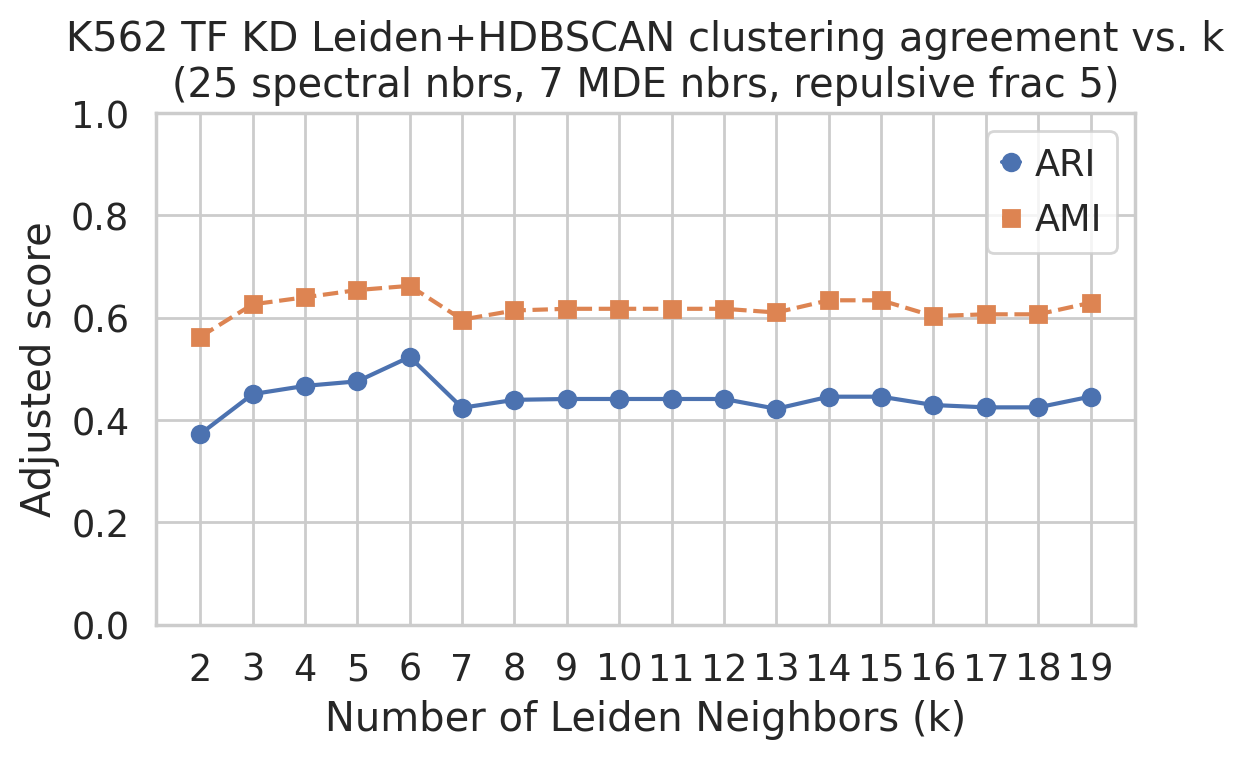

In [99]:
title = "K562 TF KD Leiden+HDBSCAN clustering agreement vs. k\n(25 spectral nbrs, 7 MDE nbrs, repulsive frac 5)"
ari_ami_df = plot_cluster_agreement(mde_embedding, perturbation_HDBSCAN_labels,
                                    title=title)

In [100]:
ari_ami_df.head(10)

,ARI,AMI
2,0.372,0.563
3,0.450,0.626
4,0.467,0.640
5,0.475,0.654
6,0.523,0.662
7,0.424,0.596
8,0.439,0.614
9,0.441,0.617
10,0.441,0.617
11,0.441,0.617


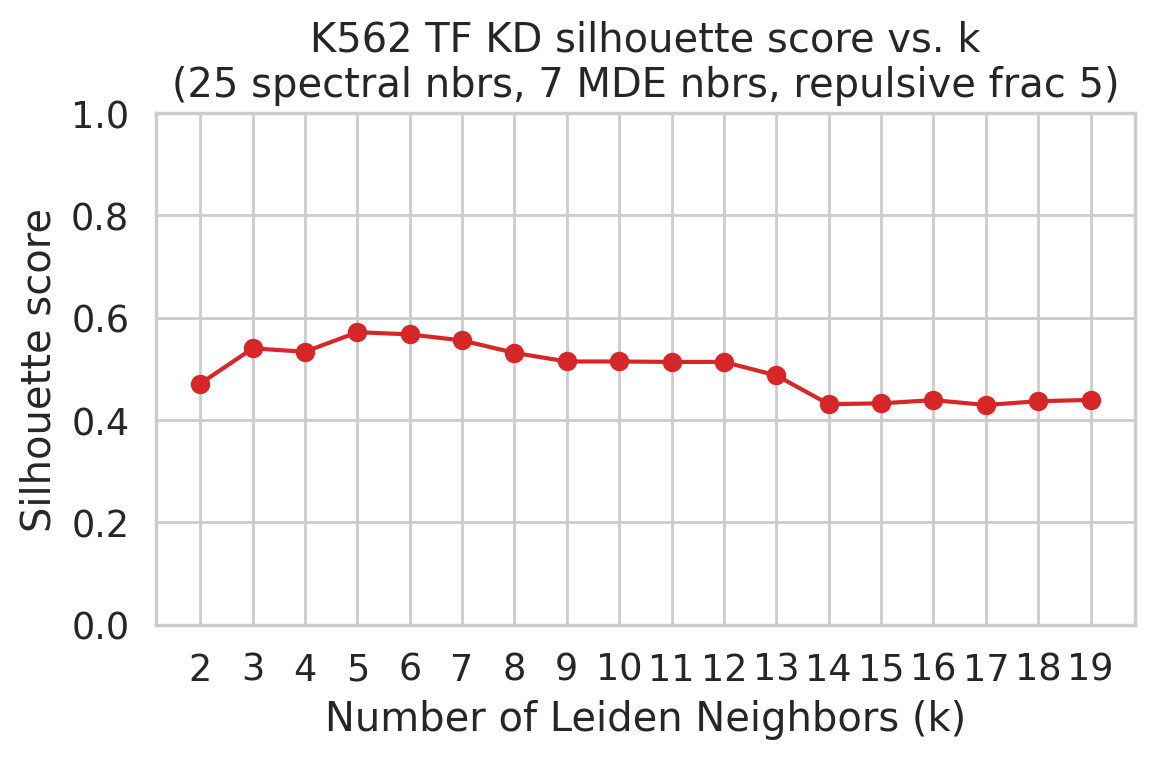

In [101]:
title = "K562 TF KD silhouette score vs. k\n(25 spectral nbrs, 7 MDE nbrs, repulsive frac 5)"
silhouette_score_df = plot_silhouette_scores(mde_embedding, title=title)

In [103]:
silhouette_score_df.head(10)

,Silhouette score
2,0.471
3,0.540
4,0.533
5,0.572
6,0.567
7,0.555
8,0.531
9,0.514
10,0.514
11,0.513


### 6 KNN nbrs

In [104]:
embedding_df = build_mde_df(mde_embedding, bulks_mde, perturbation_HDBSCAN_labels,
                                   n_neighbors=6)

In [ ]:
_ = plot_mde_interactive(mde_embedding, bulks_mde, perturbation_HDBSCAN_labels,
                         n_neighbors=6, # number of neighbors for KNN graph
                         title="K562 TF KD MDE (25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 5)")

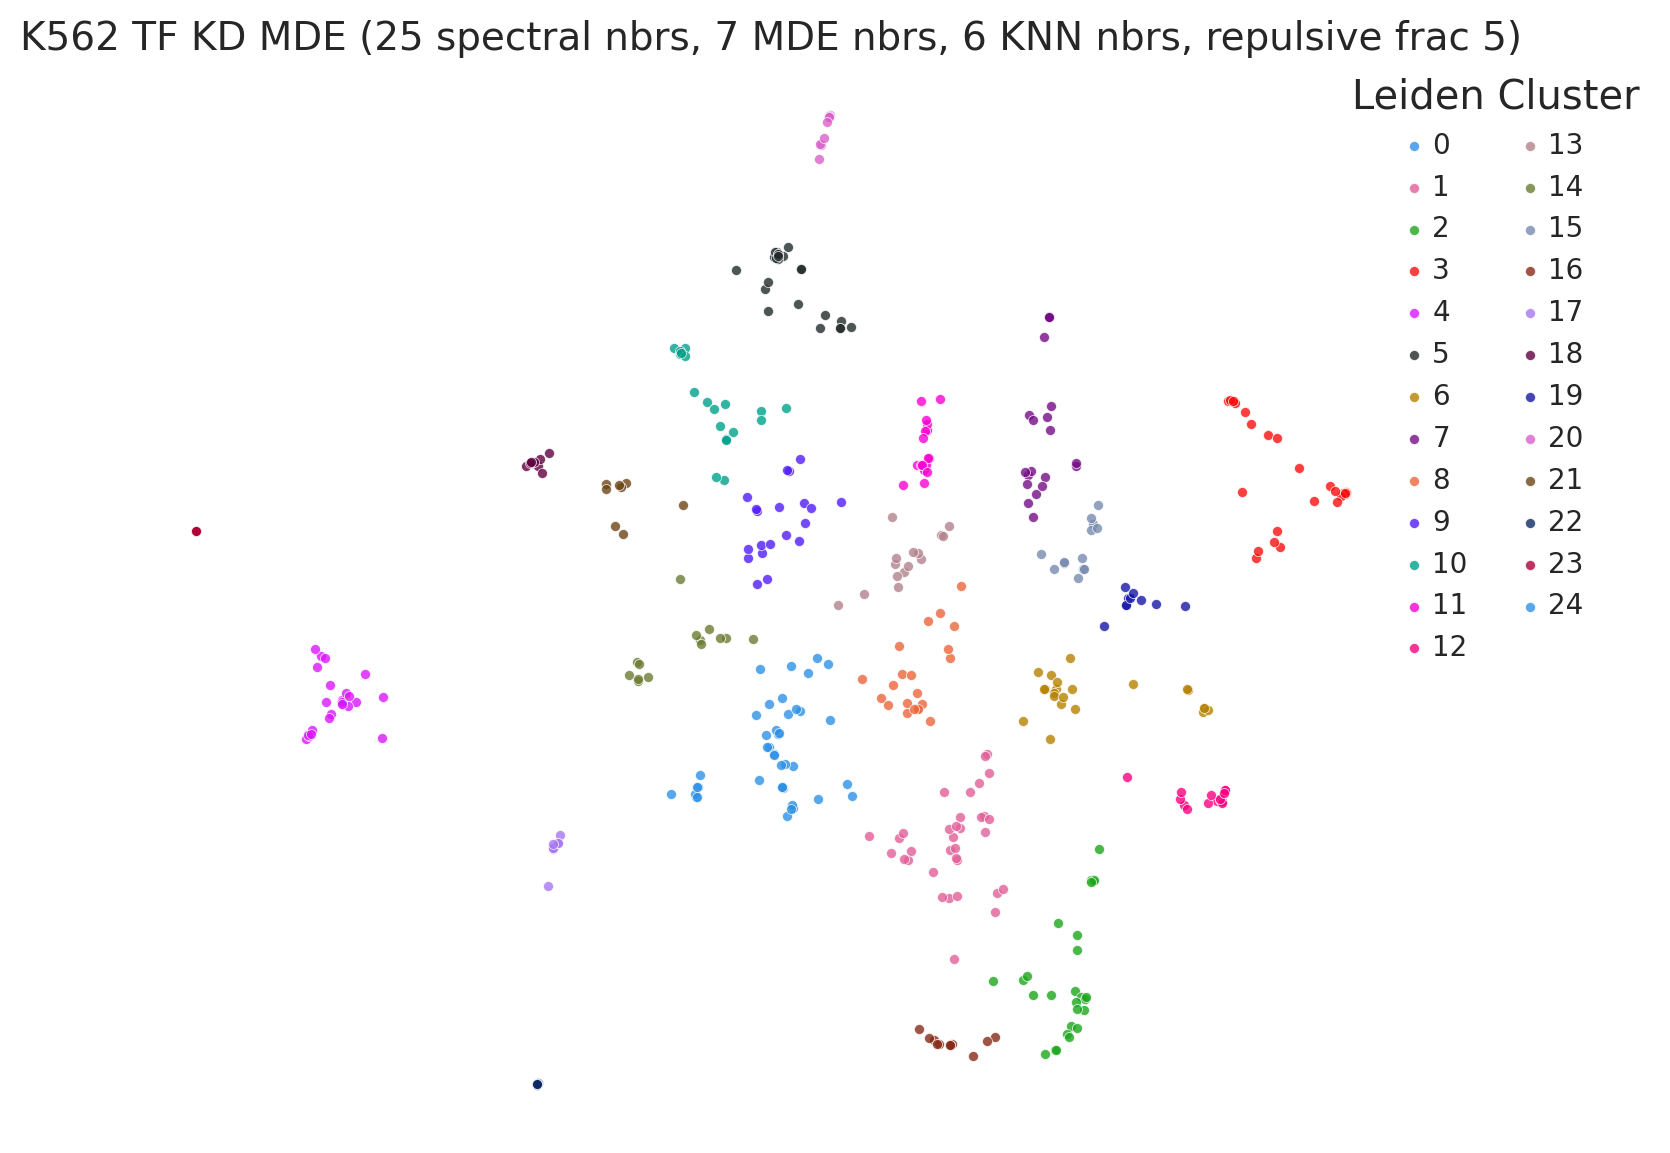

In [41]:
title = "K562 TF KD MDE (25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 5)"
_ = plot_mde_static(mde_embedding, 
                    bulks_mde, 
                    n_neighbors=6, # number of neighbors for KNN graph
                    title_fontsize=14,
                    title=title,
                    legend_ncol=2)

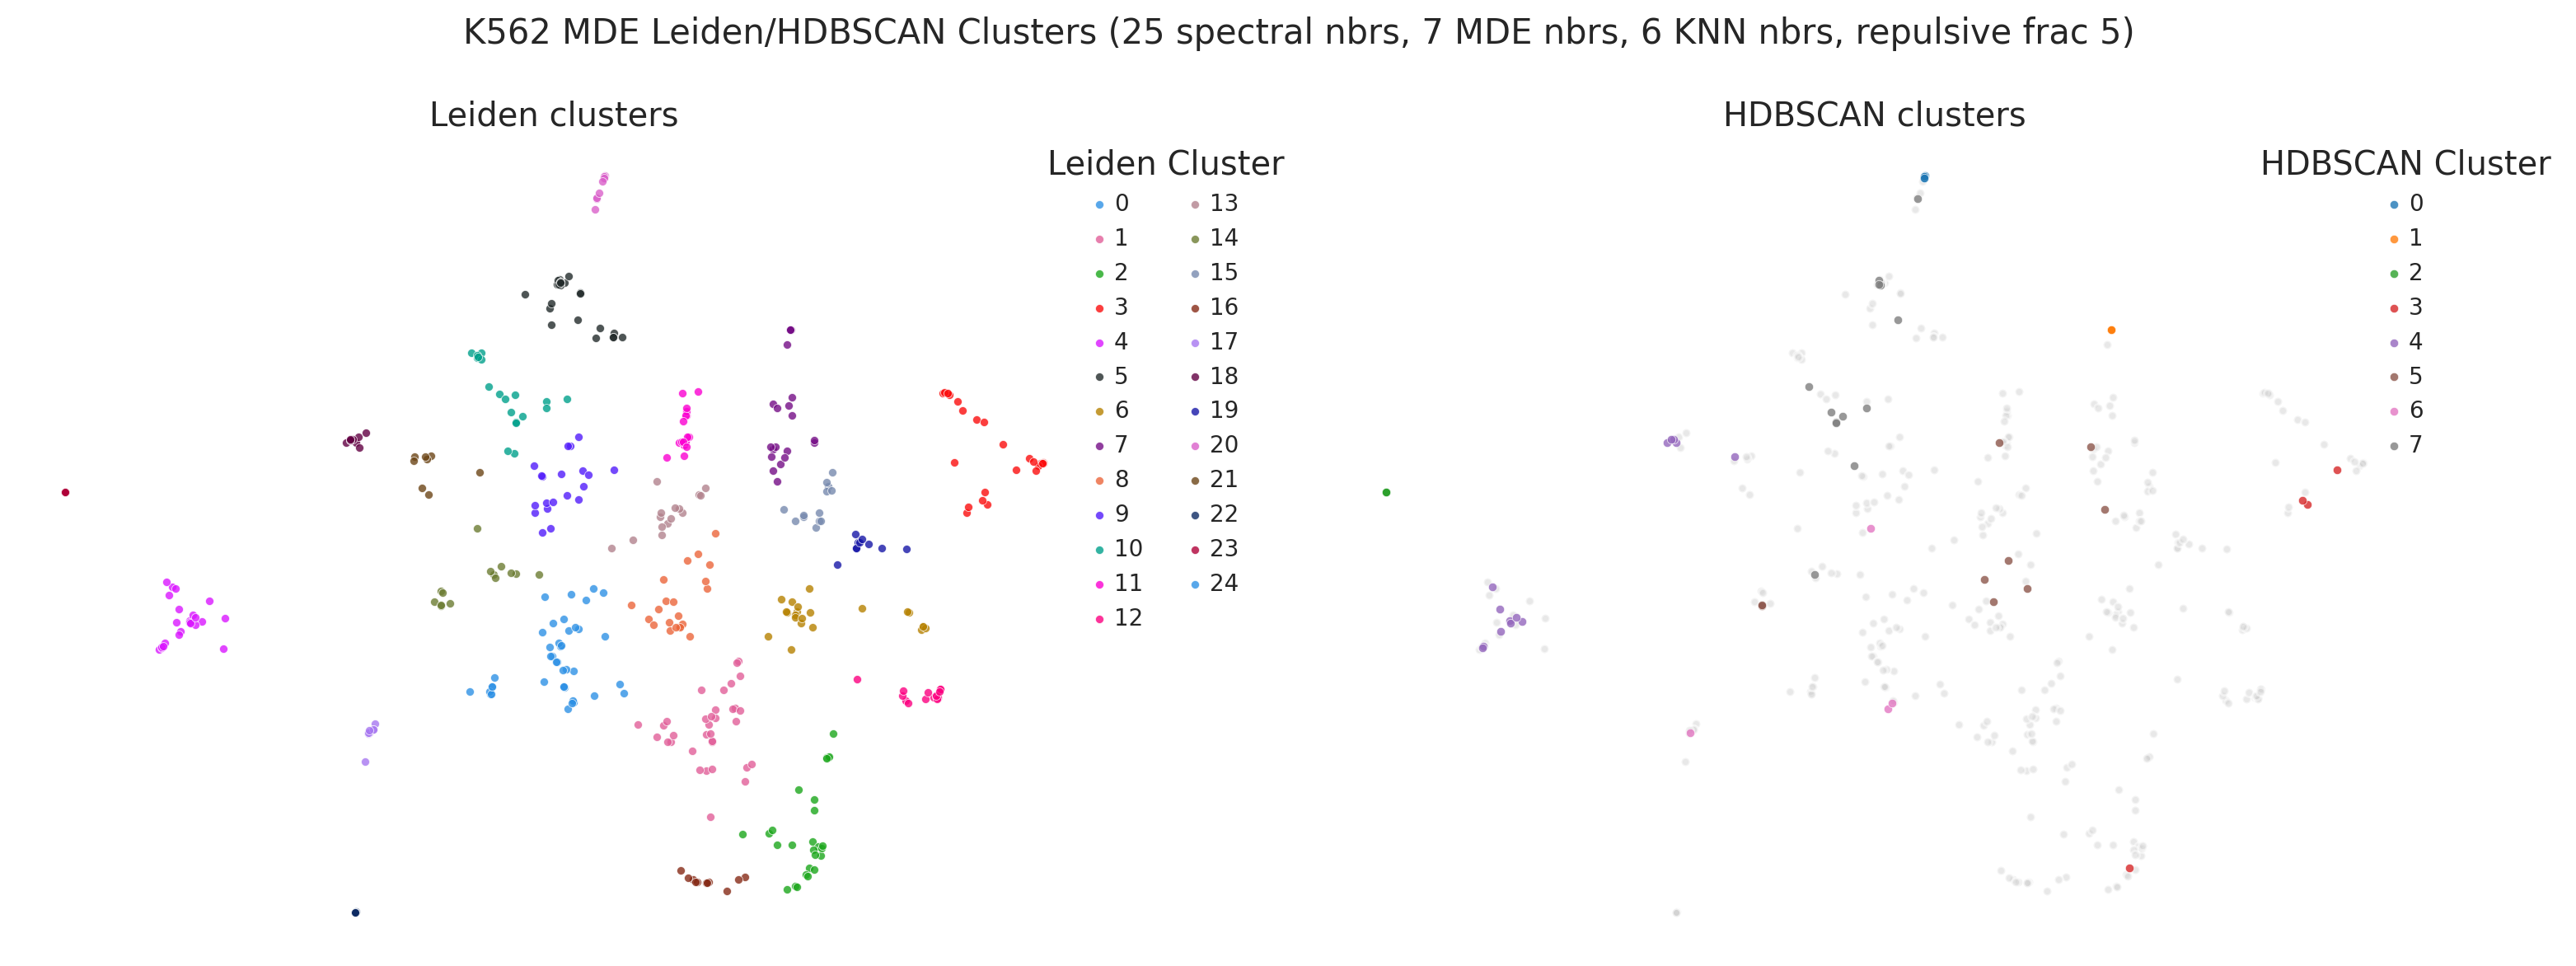

In [42]:
title = "K562 MDE Leiden/HDBSCAN Clusters (25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 5)"
_ = plot_mde_leiden_hdbscan(mde_embedding, perturbation_HDBSCAN_labels, 
                            bulks_mde, n_neighbors=6, suptitle_fontsize=15,
                            suptitle=title, legend_ncol=2)

In [ ]:
title="K562 TF KD MDE Leiden Clusters & CORUM Complexes (25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 5)"
_ = plot_mde_leiden_corum(mde_embedding, bulks_mde, corum_complexes, n_neighbors=6,
                          suptitle=title, legend_ncol=2)

/home/ranwyl/psp_env/lib64/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
/home/ranwyl/psp_env/lib64/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix


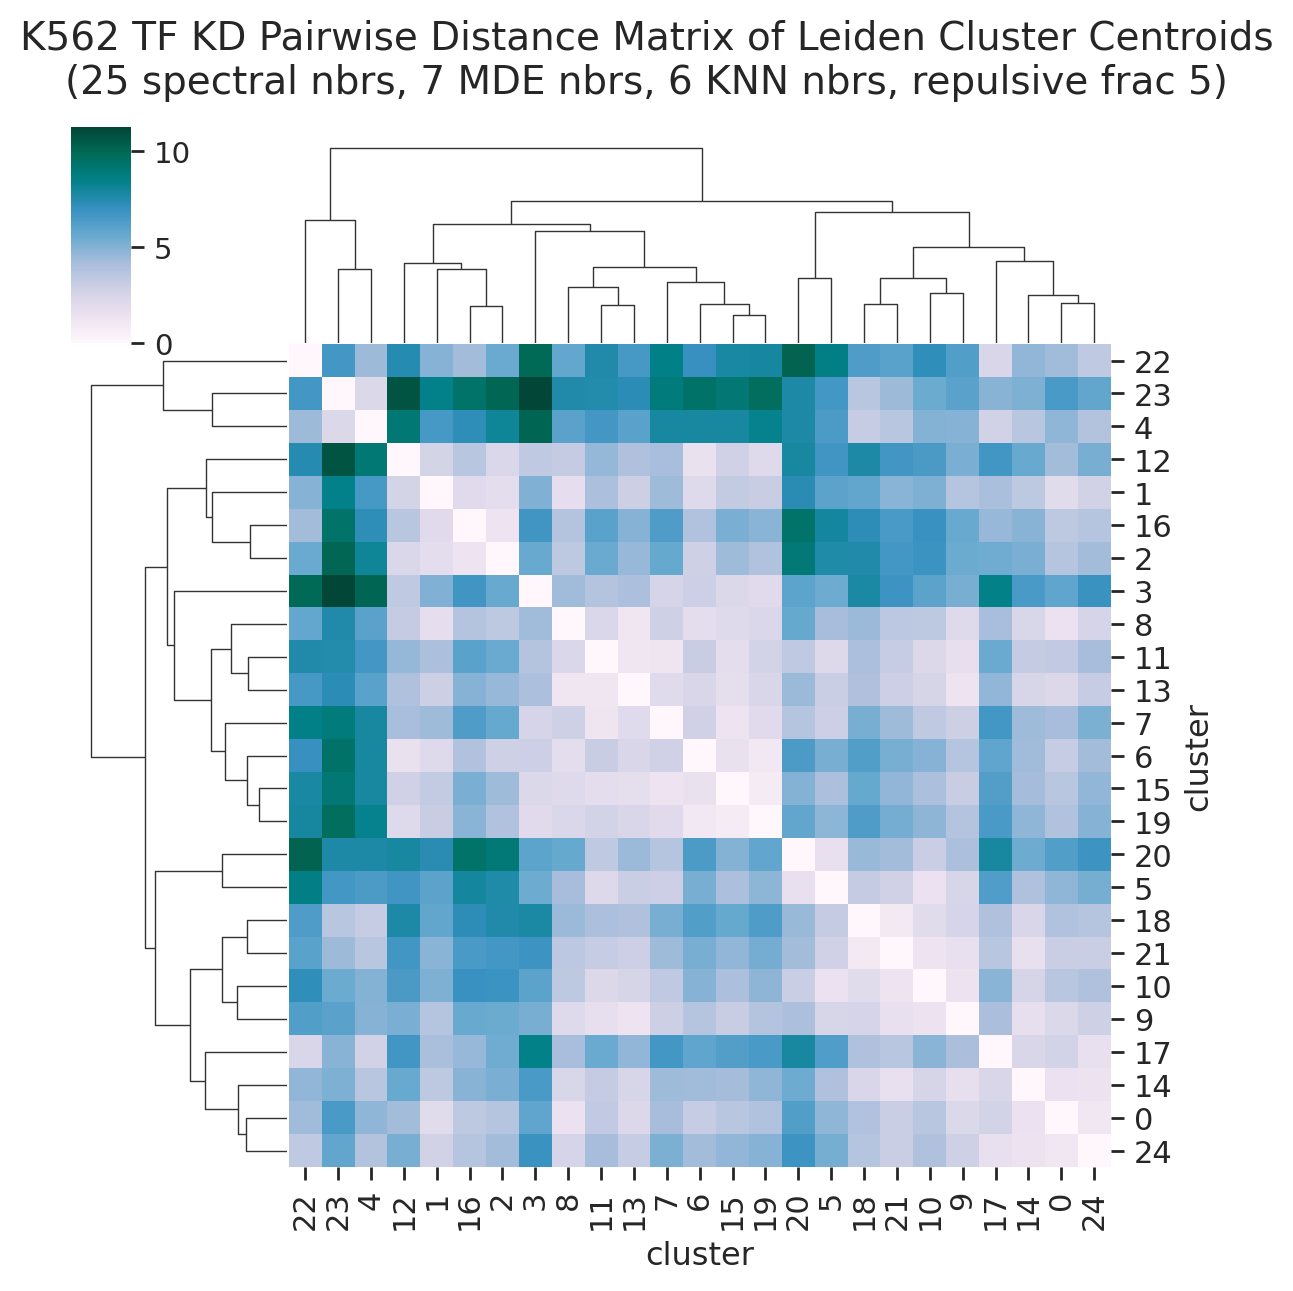

In [51]:
title="K562 TF KD Pairwise Distance Matrix of Leiden Cluster Centroids\n(25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 5)"
plot_pairwise_distance_matrix(mde_embedding, bulks_mde, n_neighbors=6, tick_fontsize=11,
                              title=title, title_y_position=1.07)

In [107]:
leiden_cluster_kds = gene_targets_per_cluster(embedding_df, "leiden cluster")
leiden_cluster_kds.head(10)

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,ALX3,CTCFL,ARID3B,ADNP,ARID5B,ARID2,DLX4,ATF1,FOXI3,CHAMP1,...,AHRR,FOXO1,ETV4,AKAP8L,AEBP1,FIGLA,ERG,EVX2,CREBL2,CXXC4
1,BAZ2B,FEZF1,BATF,ADNP2,CPEB1,ATMIN,EMX1,DR1,IKZF1,FBXL19,...,HES4,HOXA9,HMBOX1,CARF,CLOCK,FOXL2,GMEB1,FOXG1,FLI1,DLX2
2,FOS,HEY1,CEBPB,BHLHE40,CXXC1,CAMTA2,FOXM1,DRAP1,KIN,FOXN1,...,HOXA10,IKZF4,MSANTD4,E2F8,RFX5,HIC2,HOXB6,IKZF2,MTF1,TBX18
3,FOXQ1,IKZF5,FIZ1,CEBPG,DNMT1,CENPT,FOXR1,E2F3,KLF10,GPBP1,...,HOXB9,KLF1,RBPJL,GTF3A,SP100,PRMT3,IRX1,IRF5,SNAPC5,TBX22
4,GBX2,ISL1,FOXD4L1,CHCHD3,HHEX,FOXO4,GZF1,FOSL1,KLF11,GPBP1L1,...,HSFX1,LYL1,TCF3,HMX3,TIGD3,SPI1,PURG,PRDM5,SP5,ZNF470
5,GLYR1,KLF9,HIC1,DMBX1,HLF,FOXS1,JUNB,GLI4,LIN54,HSF5,...,NEUROG2,NFYA,WT1,NR2C1,ZNF22,TFDP1,SOX1,PRDM13,UNCX,ZNF674
6,HOXB5,KLF15,HOXB4,DNTTIP1,HOXA3,HINFP,KLF12,HMGA1,NRL,IRX2,...,RFX1,PAX2,ZNF518A,NR2F2,ZNF182,ZBTB39,THAP10,TET1,ZBTB44,ZSCAN21
7,HOXC4,MAFG,IRF1,E4F1,KLF16,KAT7,MBD1,HOXB8,SAFB2,MYNN,...,SON,ZNF184,ZNF551,PA2G4,ZNF189,ZNF71,ZNF541,ZNF326,NaN,NaN
8,IRF3,NAIF1,KCMF1,ELF4,MEIS3,MEF2A,MLXIPL,KMT2A,TCF15,POGK,...,THAP11,ZNF281,ZNF704,ZNF574,ZNF211,ZNF549,NaN,NaN,NaN,NaN
9,KCNIP3,NKX2-6,LIN28A,ETS1,MXD4,NFIC,PDX1,PPARA,TEAD3,PRDM14,...,ZBTB48,ZNF518B,ZNF853,ZNF787,ZNF672,NaN,NaN,NaN,NaN,NaN


In [53]:
leiden_filepath = \
    "/home/ranwyl/output_files_tf_project/K562_leiden_clusters_spectral25-mde7-knn6-repulsive5_6-4-26.csv"
leiden_cluster_kds.to_csv(leiden_filepath)

In [ ]:
leiden_filepath = \
    "/home/ranwyl/output_files_tf_project/K562_leiden_clusters_spectral25-mde7-knn6-repulsive5_6-4-26.csv"
leiden_cluster_kds = pd.read_csv(leiden_filepath, header=0, index_col=0)
leiden_cluster_kds.head()

[34, 34, 27, 26, 25, 24, 22, 22, 21, 20, 19, 17, 16, 15, 14, 13, 11, 10, 10, 10, 9, 8, 8, 7, 7]


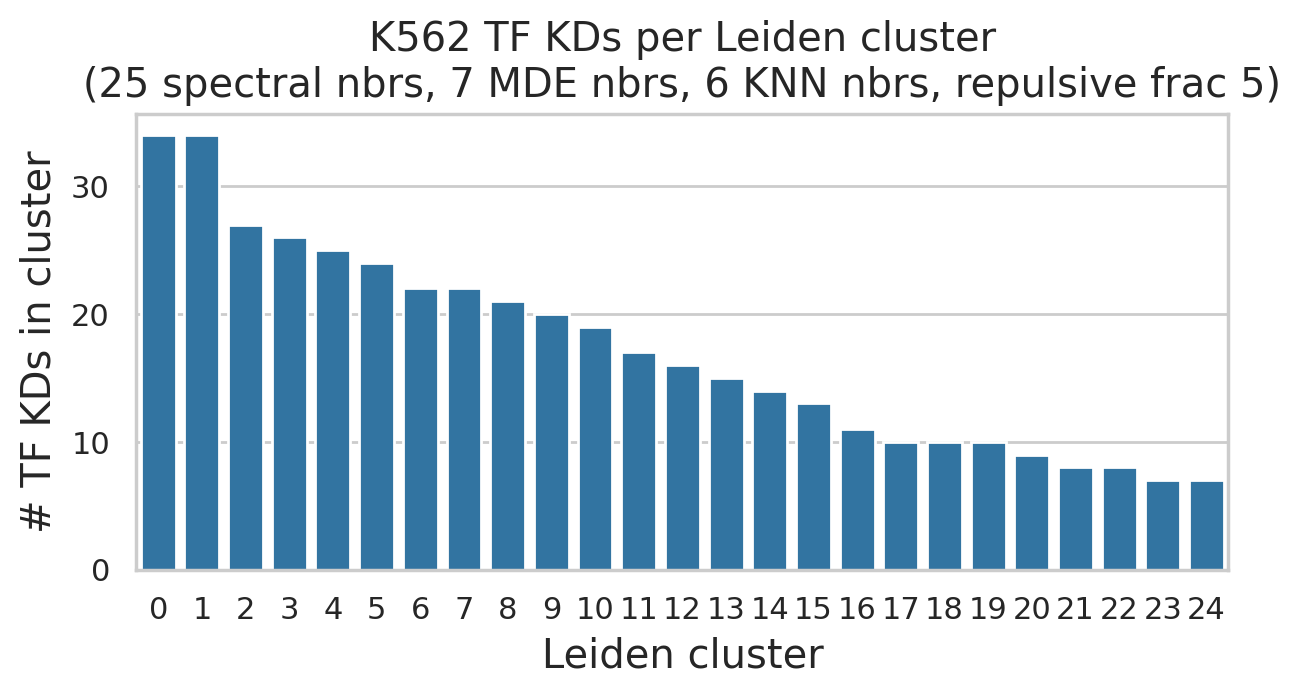

In [108]:
title = "K562 TF KDs per Leiden cluster\n(25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 5)"
plot_n_perts_per_cluster(leiden_cluster_kds, title=title, xlabel="Leiden cluster",
                         figsize=(7,3))

In [109]:
pd.options.display.float_format = '{:,.0f}'.format

In [110]:
leiden_corum_df = find_corum_complexes_in_clusters(corum_perturb, leiden_cluster_kds)
leiden_corum_df

,Leiden cluster,CORUM complex


Which clusters contain KDs of TFs with known functions

In [111]:
erythroid_tfs = ["GATA1", "LDB1", "LMO2", "GATA2", "KLF1", "TAL1", "ZFPM1", "LRF", 
                 "SCL", "MYB", "JUNB", "MYC"]
# GATA2 is downregulated in erythropoiesis
myeloid_tfs = ["SPI1", "CEBPA", "CEBPB", "CEBPE", "GFI1", "RUNX1", "IRF8"]
myeloid_tf_synonyms = ['AML1', 'CBFA2', 'PEPB2A', 'ICSBP']
lymphoid_tfs = ["PAX5", "IKZF1", # B-cell
                "TCF1", "BCL11B", # T-cell
                "GATA3", "ID2"]

In [112]:
print("Erythroid TFs")
find_kds_in_leiden_hdbscan_clusters(erythroid_tfs, leiden_cluster_kds, 
                                    hdbscan_cluster_kds, sort_by="leiden")

Erythroid TFs


,Leiden cluster,HDBSCAN cluster
TAL1,0,6
JUNB,6,
MYB,10,7
ZFPM1,14,
KLF1,16,
GATA1,,
LDB1,,
LMO2,,
GATA2,,
LRF,,


In [113]:
print("Myeloid TFs")
find_kds_in_leiden_hdbscan_clusters(myeloid_tfs, leiden_cluster_kds, 
                                    hdbscan_cluster_kds, sort_by="leiden")

Myeloid TFs


,Leiden cluster,HDBSCAN cluster
CEBPB,2,
SPI1,20,0
CEBPA,,
CEBPE,,
GFI1,,
RUNX1,,
IRF8,,


In [114]:
find_kds_in_leiden_hdbscan_clusters(lymphoid_tfs, leiden_cluster_kds, 
                                    hdbscan_cluster_kds, sort_by="leiden")

,Leiden cluster,HDBSCAN cluster
IKZF1,8,
PAX5,,
TCF1,,
BCL11B,,
GATA3,,
ID2,,


Which clusters contain TF KDs with highest DEG counts?

In [115]:
kds_high_degs = n_degs_df.sort_values(by="n_DEGs", ascending=False).head(20).index.tolist()

In [116]:
find_kds_in_leiden_hdbscan_clusters(kds_high_degs, leiden_cluster_kds,
                                    hdbscan_cluster_kds, sort_by="leiden")

,Leiden cluster,HDBSCAN cluster
TBX1,1,
POU3F1,2,
SETDB1,3,
CXXC1,4,4
TBP,4,4
ZNF84,4,4
DNMT1,4,
NKX6-1,4,
ZBTB17,4,
HINFP,5,7


Which Leiden clusters contain HDBSCAN cluster TF KDs?

In [64]:
hdbscan_tf_kds = hdbscan_cluster_kds.to_numpy().flatten().tolist()
hdbscan_tf_kds = [kd for kd in hdbscan_tf_kds if not isinstance(kd, float)]
print(len(hdbscan_tf_kds))

58


In [65]:
leiden_hdbscan_df = \
    find_kds_in_leiden_hdbscan_clusters(hdbscan_tf_kds, leiden_cluster_kds,
                                    hdbscan_cluster_kds, sort_by="hdbscan")

In [66]:
leiden_hdbscan_df[leiden_hdbscan_df["HDBSCAN cluster"].isin([0, 1, 2, 3])]

,Leiden cluster,HDBSCAN cluster
PRMT3,20,0
SPI1,20,0
TFDP1,20,0
ZBTB39,20,0
DR1,7,1
DRAP1,7,1
TBPL1,7,1
ZNF317,7,1
FLI1,23,2
MTF1,23,2


In [67]:
leiden_hdbscan_df[leiden_hdbscan_df["HDBSCAN cluster"].isin([4, 5])]

,Leiden cluster,HDBSCAN cluster
ARID5B,4,4
CPEB1,4,4
CXXC1,4,4
HHEX,4,4
HOXA3,4,4
MYSM1,4,4
TBP,4,4
ZNF84,4,4
ZNF236,4,4
CARF,18,4


In [68]:
leiden_hdbscan_df[leiden_hdbscan_df["HDBSCAN cluster"].isin([6,7])]

,Leiden cluster,HDBSCAN cluster
PRDM8,0,6
TAL1,0,6
PRDM14,9,6
HMBOX1,17,6
FOXS1,5,7
HINFP,5,7
STAT5B,5,7
ZNF414,5,7
ZNF560,9,7
MAX,10,7


In [69]:
sns.set_style("whitegrid")

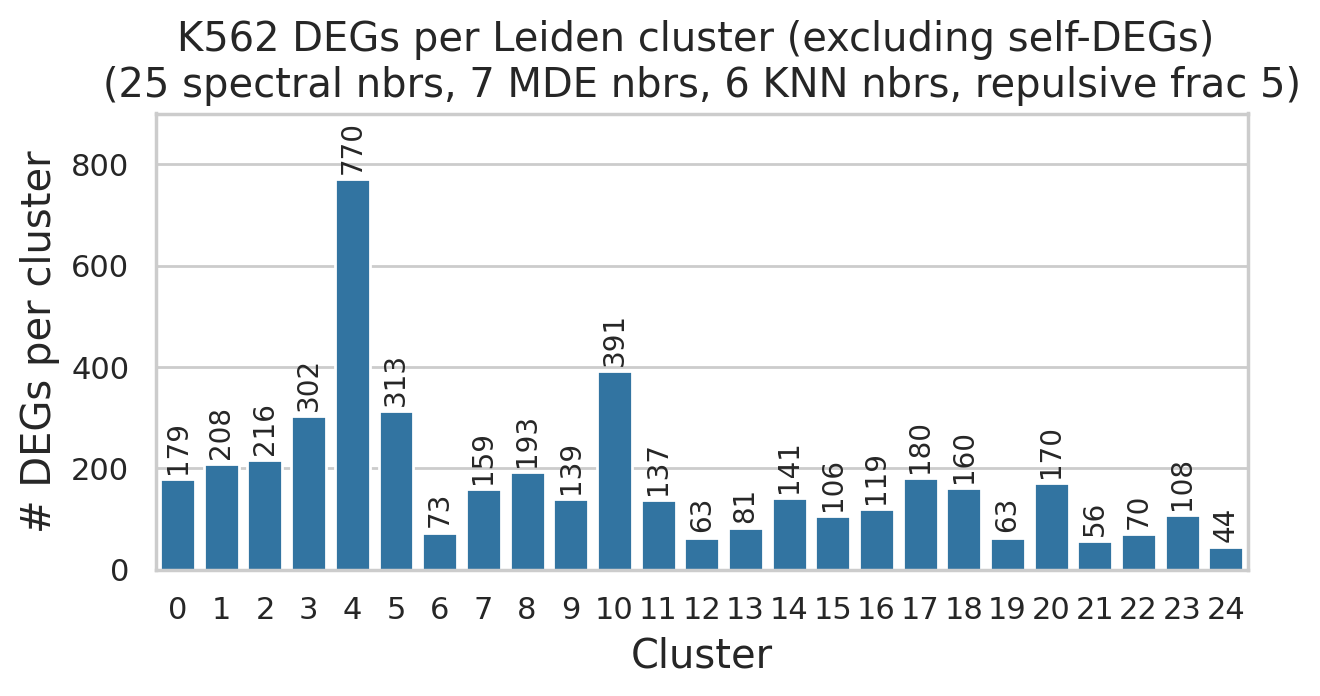

In [124]:
cluster_deg_dict_k562 = build_cluster_DEGs_dict(kd_deg_dict_k562,
                                                leiden_cluster_kds)
title = "K562 DEGs per Leiden cluster (excluding self-DEGs) \n(25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 5)"
_ = plot_n_DEGs_per_cluster(cluster_deg_dict_k562, title=title, figsize=(7,3), ymax=900)

### 8 KNN nbrs

In [73]:
embedding_df = build_mde_df(mde_embedding, bulks_mde, perturbation_HDBSCAN_labels,
                                   n_neighbors=8)

In [ ]:
_ = plot_mde_interactive(mde_embedding, bulks_mde, perturbation_HDBSCAN_labels,
                         n_neighbors=8, # number of neighbors for KNN graph
                         title="K562 TF KD MDE (25 spectral nbrs, 7 MDE nbrs, 8 KNN nbrs, repulsive frac 5)")

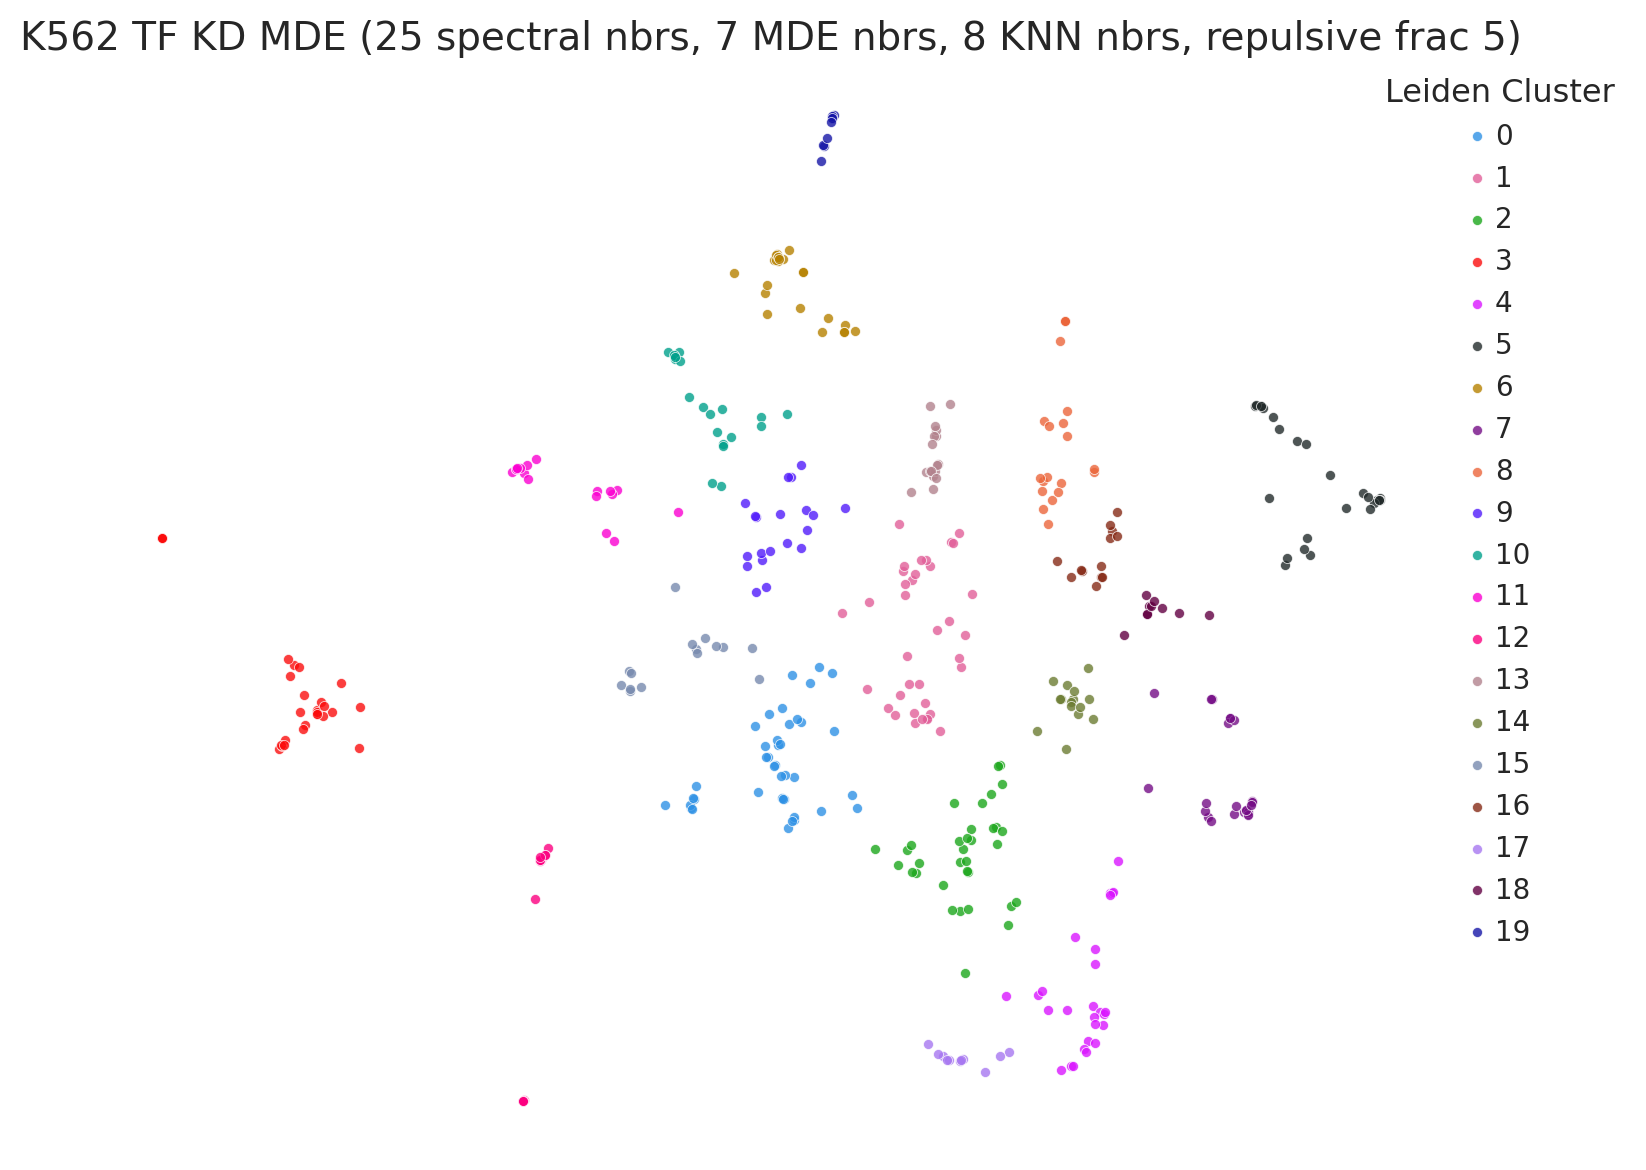

In [74]:
title = "K562 TF KD MDE (25 spectral nbrs, 7 MDE nbrs, 8 KNN nbrs, repulsive frac 5)"
_ = plot_mde_static(mde_embedding, 
                    bulks_mde, 
                    n_neighbors=8, # number of neighbors for KNN graph
                    title_fontsize=14,
                    title=title)

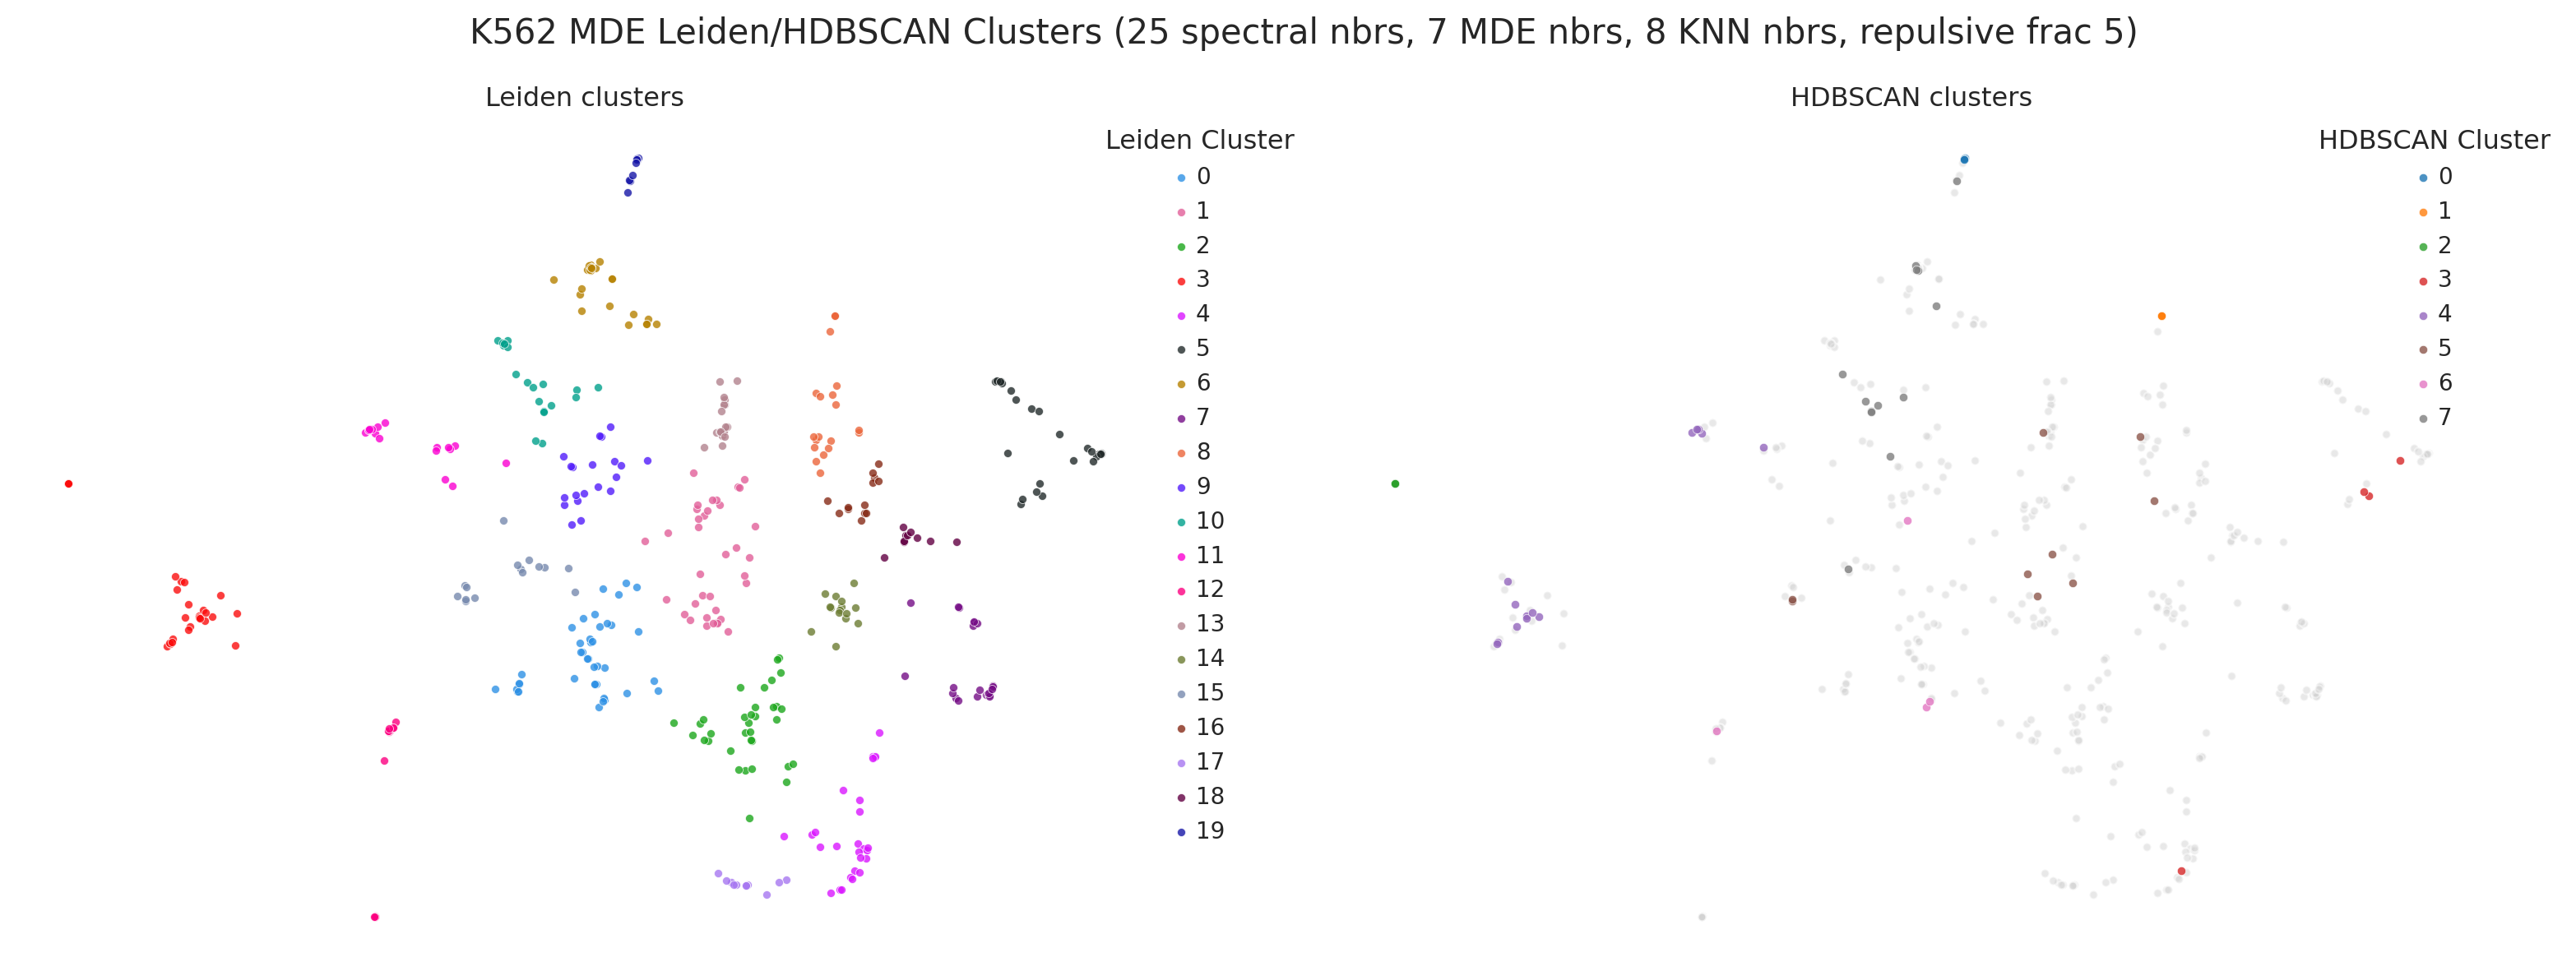

In [75]:
title = "K562 MDE Leiden/HDBSCAN Clusters (25 spectral nbrs, 7 MDE nbrs, 8 KNN nbrs, repulsive frac 5)"
_ = plot_mde_leiden_hdbscan(mde_embedding, perturbation_HDBSCAN_labels, 
                            bulks_mde, n_neighbors=8, suptitle_fontsize=15,
                            suptitle=title)

In [ ]:
# title="K562 TF KD MDE Leiden Clusters & CORUM Complexes (25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 5)"
# _ = plot_mde_leiden_corum(mde_embedding, bulks_mde, corum_complexes, n_neighbors=6,
#                           suptitle=title, legend_ncol=2)

In [ ]:
title="K562 TF KD Pairwise Distance Matrix of Leiden Cluster Centroids\n(25 spectral nbrs, 7 MDE nbrs, 8 KNN nbrs, repulsive frac 5)"
plot_pairwise_distance_matrix(mde_embedding, bulks_mde, n_neighbors=8, tick_fontsize=11,
                              title=title, title_y_position=1.07)

In [77]:
leiden_cluster_kds = gene_targets_per_cluster(embedding_df, "leiden cluster")
leiden_cluster_kds.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,ALX3,FOXI1,CTCFL,ARID5B,ARID3B,ADNP,ARID2,CDX2,ATF1,CHAMP1,FOXK1,AKAP8L,ETV4,AHCTF1,GZF1,CREBZF,AHRR,FOXO1,AEBP1,FIGLA
1,BAZ2B,FOXI3,FEZF1,CPEB1,BATF,ADNP2,ATMIN,DLX4,DR1,FBXL19,FOXN2,CARF,EVX2,BACH1,JUNB,E2F1,HES4,HOXA9,CLOCK,FOXL2
2,CXXC4,GCM2,HEY1,CREBL2,CEBPB,BHLHE40,CAMTA2,EMX1,DRAP1,FOXN1,MAX,E2F8,FOXG1,BHLHA9,KLF12,FLYWCH1,HOXA10,IKZF4,RFX5,HIC2
3,DLX2,HOXD3,IKZF5,CXXC1,FIZ1,CEBPG,CENPT,FOXD3,E2F3,GPBP1,MYB,ERG,HMBOX1,ELF3,MBD1,FOXR2,HOXB9,KLF1,SP100,PRMT3
4,FOS,IKZF1,ISL1,DNMT1,FOXD4L1,CHCHD3,FOXO4,FOXM1,FOSL1,GPBP1L1,NRF1,GMEB1,IKZF2,GSC,MLXIPL,HNF4A,HSFX1,LYL1,TIGD3,SPI1
5,FOXQ1,KIN,KLF9,FLI1,HIC1,DMBX1,FOXS1,FOXO3,GLI4,HSF5,PRDM4,GTF3A,IRF5,GTF2IRD2,PTF1A,MBD3,NEUROG2,NFYA,ZNF22,TFDP1
6,GBX2,KLF10,KLF15,HHEX,HOXB4,DNTTIP1,HINFP,FOXP1,HMGA1,IRX2,SKIL,HMX3,MSANTD4,INSM2,RFX3,MSX2,RFX1,PAX2,ZNF182,ZBTB39
7,GLYR1,KLF11,MAFG,HLF,IRF1,E4F1,KAT7,FOXR1,HOXB8,MYNN,SOX9,HOXB6,PRDM5,LBX1,RUNX3,PHF1,SON,ZNF184,ZNF189,ZNF71
8,HOXB5,LIN54,NAIF1,HOXA3,KCMF1,ELF4,MEF2A,GRHL1,KMT2A,POGK,SOX18,IRX1,PRDM13,MITF,SREBF2,PRDM16,THAP11,ZNF281,ZNF211,ZNF549
9,HOXC4,MAFK,NKX2-6,KLF16,LIN28A,ETS1,NFIC,HEYL,PPARA,PRDM14,SP1,NR2C1,RBPJL,NR2C2,ZFHX2,PRR12,ZBTB48,ZNF518B,ZNF672,NaN


In [ ]:
leiden_filepath = \
    "/home/ranwyl/output_files_tf_project/K562_leiden_clusters_spectral25-mde7-knn6-repulsive5_6-4-26.csv"
leiden_cluster_kds.to_csv(leiden_filepath)

In [ ]:
leiden_filepath = \
    "/home/ranwyl/output_files_tf_project/K562_leiden_clusters_spectral25-mde7-knn6-repulsive5_6-4-26.csv"
leiden_cluster_kds = pd.read_csv(leiden_filepath, header=0, index_col=0)
leiden_cluster_kds.head()

[40, 36, 34, 32, 27, 26, 24, 23, 22, 20, 19, 18, 18, 17, 15, 15, 13, 11, 10, 9]


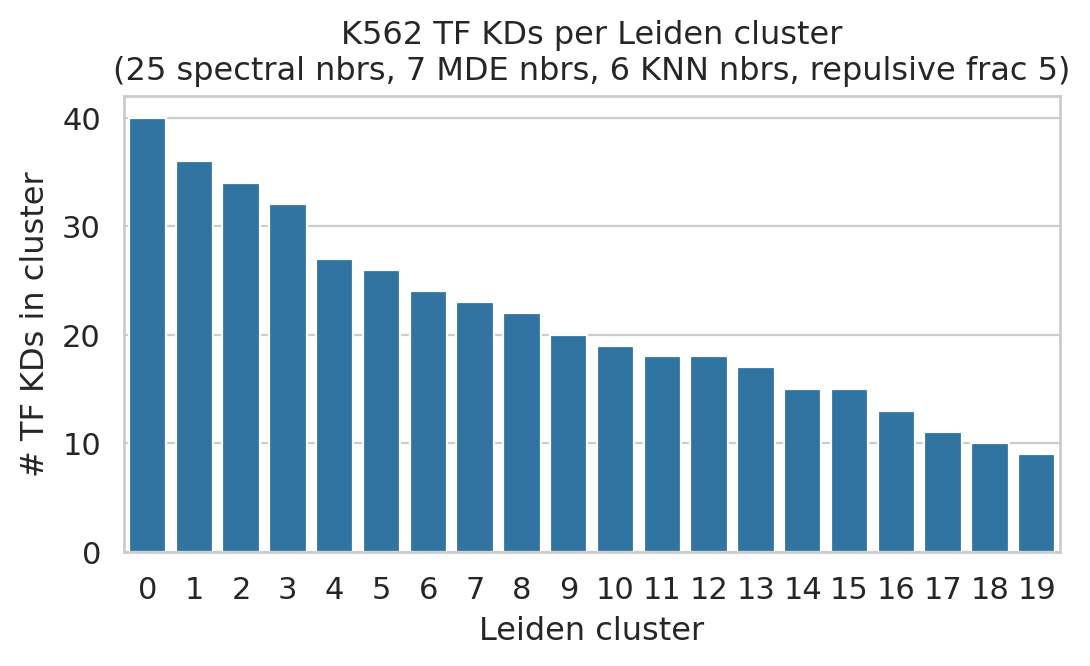

In [79]:
title = "K562 TF KDs per Leiden cluster\n(25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 5)"
plot_n_perts_per_cluster(leiden_cluster_kds, title=title, xlabel="Leiden cluster",
                         figsize=(6,3))

In [80]:
pd.options.display.float_format = '{:,.0f}'.format

In [81]:
leiden_corum_df = find_corum_complexes_in_clusters(corum_perturb, leiden_cluster_kds)
leiden_corum_df

,Leiden cluster,CORUM complex


Which clusters contain KDs of TFs with known functions

In [82]:
erythroid_tfs = ["GATA1", "LDB1", "LMO2", "GATA2", "KLF1", "TAL1", "ZFPM1", "LRF", 
                 "SCL", "MYB", "JUNB", "MYC"]
# GATA2 is downregulated in erythropoiesis
myeloid_tfs = ["SPI1", "CEBPA", "CEBPB", "CEBPE", "GFI1", "RUNX1", "IRF8"]
myeloid_tf_synonyms = ['AML1', 'CBFA2', 'PEPB2A', 'ICSBP']
lymphoid_tfs = ["PAX5", "IKZF1", # B-cell
                "TCF1", "BCL11B", # T-cell
                "GATA3", "ID2"]

In [83]:
print("Erythroid TFs")
find_kds_in_leiden_hdbscan_clusters(erythroid_tfs, leiden_cluster_kds, 
                                    hdbscan_cluster_kds, sort_by="leiden")

Erythroid TFs


,Leiden cluster,HDBSCAN cluster
TAL1,0,6
MYB,10,7
JUNB,14,
ZFPM1,15,
KLF1,17,
GATA1,,
LDB1,,
LMO2,,
GATA2,,
LRF,,


In [84]:
print("Myeloid TFs")
find_kds_in_leiden_hdbscan_clusters(myeloid_tfs, leiden_cluster_kds, 
                                    hdbscan_cluster_kds, sort_by="leiden")

Myeloid TFs


,Leiden cluster,HDBSCAN cluster
CEBPB,4,
SPI1,19,0
CEBPA,,
CEBPE,,
GFI1,,
RUNX1,,
IRF8,,


In [85]:
find_kds_in_leiden_hdbscan_clusters(lymphoid_tfs, leiden_cluster_kds, 
                                    hdbscan_cluster_kds, sort_by="leiden")

,Leiden cluster,HDBSCAN cluster
IKZF1,1,
PAX5,,
TCF1,,
BCL11B,,
GATA3,,
ID2,,


Which clusters contain TF KDs with highest DEG counts?

In [86]:
kds_high_degs = n_degs_df.sort_values(by="n_DEGs", ascending=False).head(20).index.tolist()

In [87]:
find_kds_in_leiden_hdbscan_clusters(kds_high_degs, leiden_cluster_kds,
                                    hdbscan_cluster_kds, sort_by="leiden")

,Leiden cluster,HDBSCAN cluster
TBX1,2,
CXXC1,3,4
TBP,3,4
ZNF84,3,4
DNMT1,3,
NKX6-1,3,
ZBTB17,3,
POU3F1,4,
SETDB1,5,
HINFP,6,7


Which Leiden clusters contain HDBSCAN cluster TF KDs?

In [88]:
hdbscan_tf_kds = hdbscan_cluster_kds.to_numpy().flatten().tolist()
hdbscan_tf_kds = [kd for kd in hdbscan_tf_kds if not isinstance(kd, float)]
print(len(hdbscan_tf_kds))

58


In [89]:
leiden_hdbscan_df = \
    find_kds_in_leiden_hdbscan_clusters(hdbscan_tf_kds, leiden_cluster_kds,
                                    hdbscan_cluster_kds, sort_by="hdbscan")

In [90]:
leiden_hdbscan_df[leiden_hdbscan_df["HDBSCAN cluster"].isin([0, 1, 2, 3])]

,Leiden cluster,HDBSCAN cluster
PRMT3,19,0
SPI1,19,0
TFDP1,19,0
ZBTB39,19,0
DR1,8,1
DRAP1,8,1
TBPL1,8,1
ZNF317,8,1
FLI1,3,2
MTF1,3,2


In [91]:
leiden_hdbscan_df[leiden_hdbscan_df["HDBSCAN cluster"].isin([4, 5])]

,Leiden cluster,HDBSCAN cluster
ARID5B,3,4
CPEB1,3,4
CXXC1,3,4
HHEX,3,4
HOXA3,3,4
MYSM1,3,4
TBP,3,4
ZNF84,3,4
ZNF236,3,4
CARF,11,4


In [92]:
leiden_hdbscan_df[leiden_hdbscan_df["HDBSCAN cluster"].isin([6,7])]

,Leiden cluster,HDBSCAN cluster
PRDM8,0,6
TAL1,0,6
PRDM14,9,6
HMBOX1,12,6
FOXS1,6,7
HINFP,6,7
STAT5B,6,7
ZNF414,6,7
ZNF560,9,7
MAX,10,7


In [93]:
sns.set_style("whitegrid")

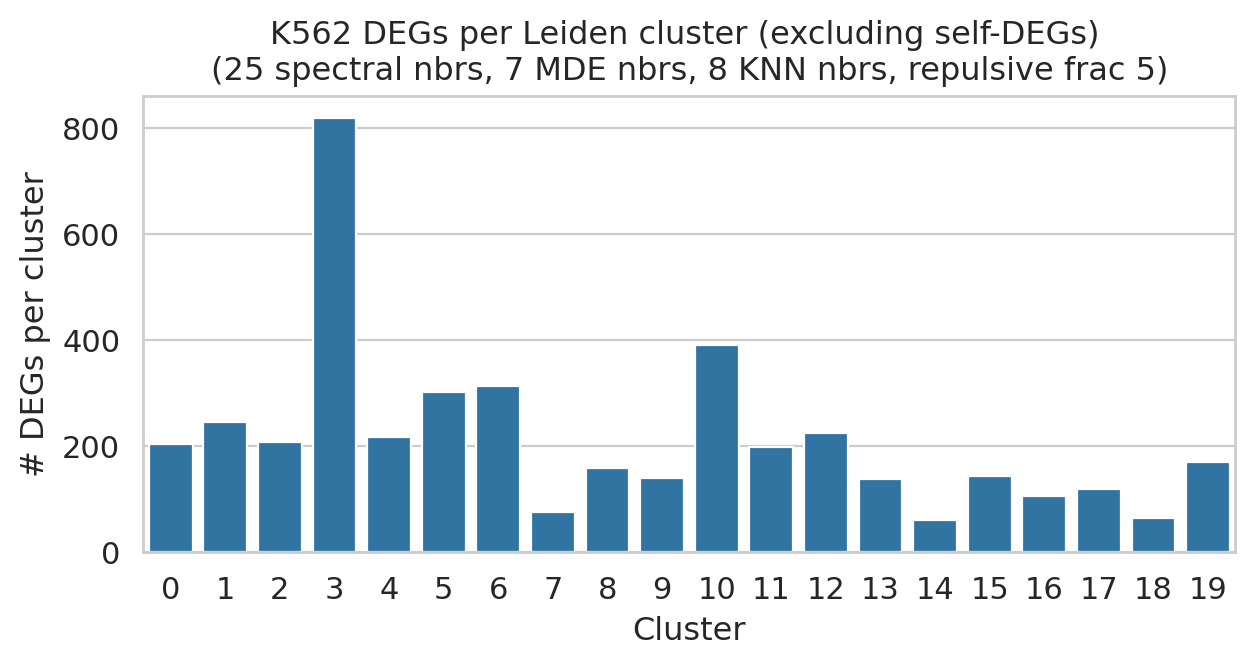

In [94]:
cluster_deg_dict_k562 = build_cluster_DEGs_dict(kd_deg_dict_k562,
                                                leiden_cluster_kds)
title = "K562 DEGs per Leiden cluster (excluding self-DEGs) \n(25 spectral nbrs, 7 MDE nbrs, 8 KNN nbrs, repulsive frac 5)"
_ = plot_n_DEGs_per_cluster(cluster_deg_dict_k562, title=title, figsize=(7,3))

In [95]:
build_n_DEGs_per_cluster_df(cluster_deg_dict_k562)

,n_DEGs
Cluster,
0,204
1,245
2,208
3,820
4,216
5,302
6,313
7,75
8,159


## MDE (25 spectral nbrs, 7 MDE nbrs, repulsive fraction 10)

In [84]:
mde_embedding = embed_spectral_mde(mp_standardized, 
                                    n_components=20,
                                    spectral_n_neighbors=25,
                                    mde_n_neighbors=7, 
                                    repulsive_fraction=10)

Jun 03 11:58:01 PM: Fitting a centered embedding into R^2, for a graph with 429 items and 24455 edges.
Jun 03 11:58:01 PM: `embed` method parameters: eps=1.0e-09, max_iter=2000, memory_size=10
Jun 03 11:58:01 PM: iteration 0000 | distortion 1.137170 | residual norm 0.186764 | step length 1.27403 | percent change 0.812324
Jun 03 11:58:03 PM: iteration 0200 | distortion 0.125903 | residual norm 0.0001812 | step length 1 | percent change 0.26704


Jun 03 11:58:04 PM: iteration 0400 | distortion 0.125302 | residual norm 7.16327e-05 | step length 1 | percent change 0.0428278
Jun 03 11:58:05 PM: iteration 0600 | distortion 0.125008 | residual norm 0.000123934 | step length 1 | percent change 0.0912671
Jun 03 11:58:07 PM: iteration 0800 | distortion 0.124938 | residual norm 3.53364e-05 | step length 1 | percent change 0.0287222
Jun 03 11:58:09 PM: iteration 1000 | distortion 0.124928 | residual norm 1.36208e-05 | step length 0 | percent change 0
Jun 03 11:58:17 PM: iteration 1200 | distortion 0.124928 | residual norm 1.36208e-05 | step length 0 | percent change 0
Jun 03 11:58:24 PM: iteration 1400 | distortion 0.124928 | residual norm 1.36208e-05 | step length 0 | percent change 0
Jun 03 11:58:31 PM: iteration 1600 | distortion 0.124928 | residual norm 1.36208e-05 | step length 0 | percent change 0
Jun 03 11:58:36 PM: iteration 1800 | distortion 0.124928 | residual norm 1.36208e-05 | step length 0 | percent change 0
Jun 03 11:58:41 

Choose number of neighbors for KNN graph based on agreement with HDBSCAN clusters

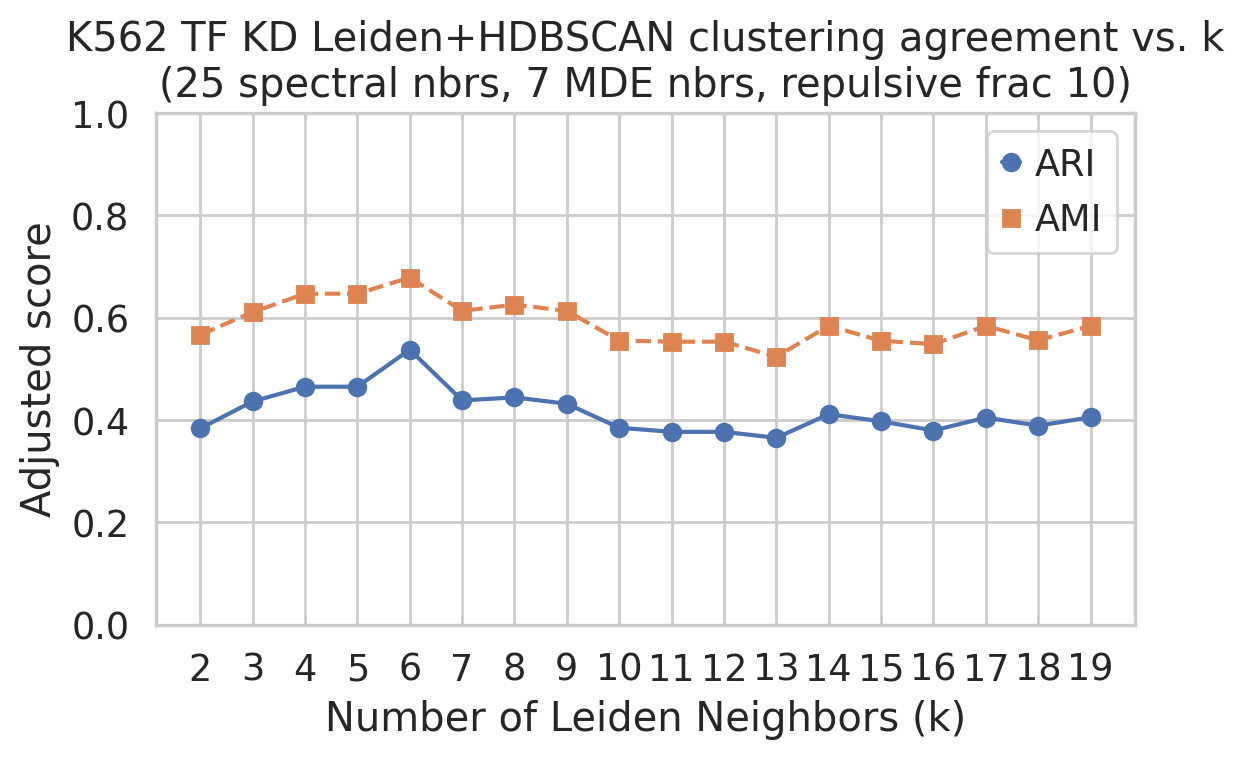

In [55]:
title = "K562 TF KD Leiden+HDBSCAN clustering agreement vs. k\n(25 spectral nbrs, 7 MDE nbrs, repulsive frac 10)"
ari_ami_df = plot_cluster_agreement(mde_embedding, perturbation_HDBSCAN_labels,
                                    title=title)

In [57]:
pd.options.display.float_format = '{:,.3f}'.format

In [58]:
ari_ami_df.head(10)

,ARI,AMI
2,0.383,0.567
3,0.436,0.611
4,0.465,0.647
5,0.465,0.647
6,0.537,0.678
7,0.438,0.613
8,0.444,0.625
9,0.432,0.613
10,0.385,0.555
11,0.377,0.553


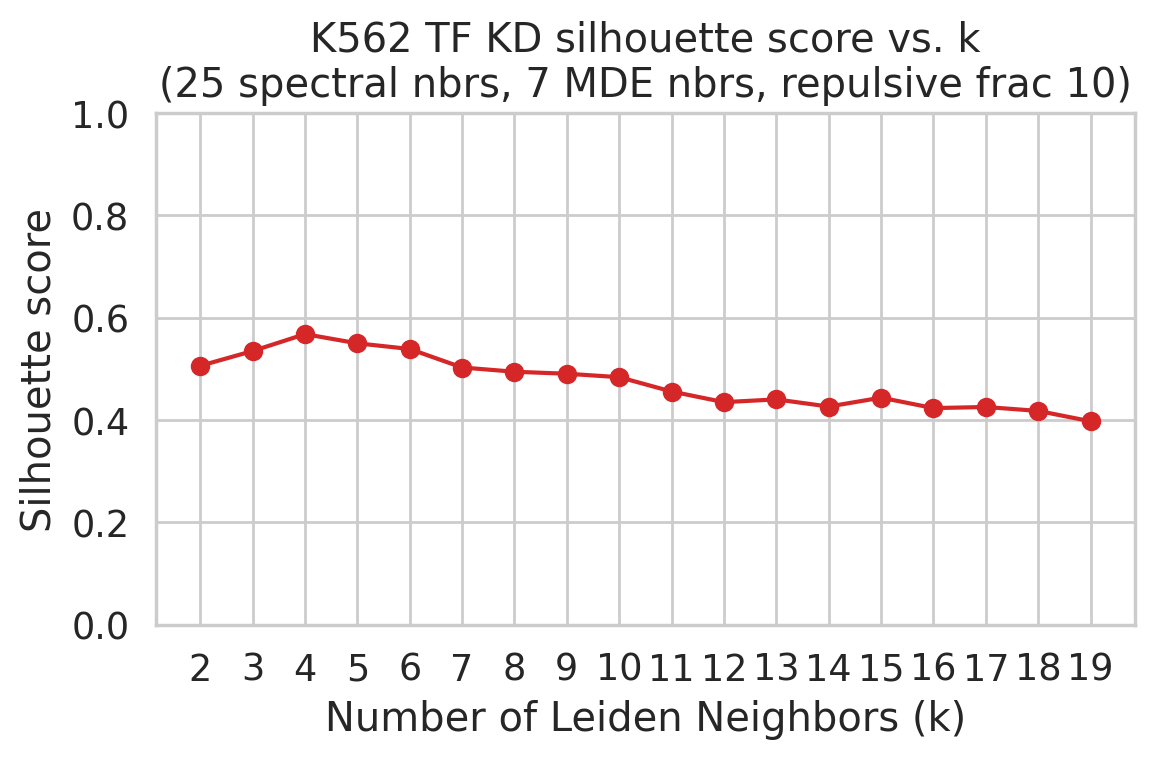

In [56]:
title = "K562 TF KD silhouette score vs. k\n(25 spectral nbrs, 7 MDE nbrs, repulsive frac 10)"
silhouette_score_df = plot_silhouette_scores(mde_embedding, title=title)

In [59]:
silhouette_score_df.head(10)

,Silhouette score
2,0.506
3,0.535
4,0.568
5,0.550
6,0.539
7,0.503
8,0.494
9,0.490
10,0.484
11,0.456


### 6 KNN nbrs

In [110]:
embedding_df = build_mde_df(mde_embedding, bulks_mde, perturbation_HDBSCAN_labels,
                                   n_neighbors=6)

In [ ]:
_ = plot_mde_interactive(mde_embedding, bulks_mde, perturbation_HDBSCAN_labels,
                         n_neighbors=6, # number of neighbors for KNN graph
                         title="K562 TF KD MDE (25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 5)")

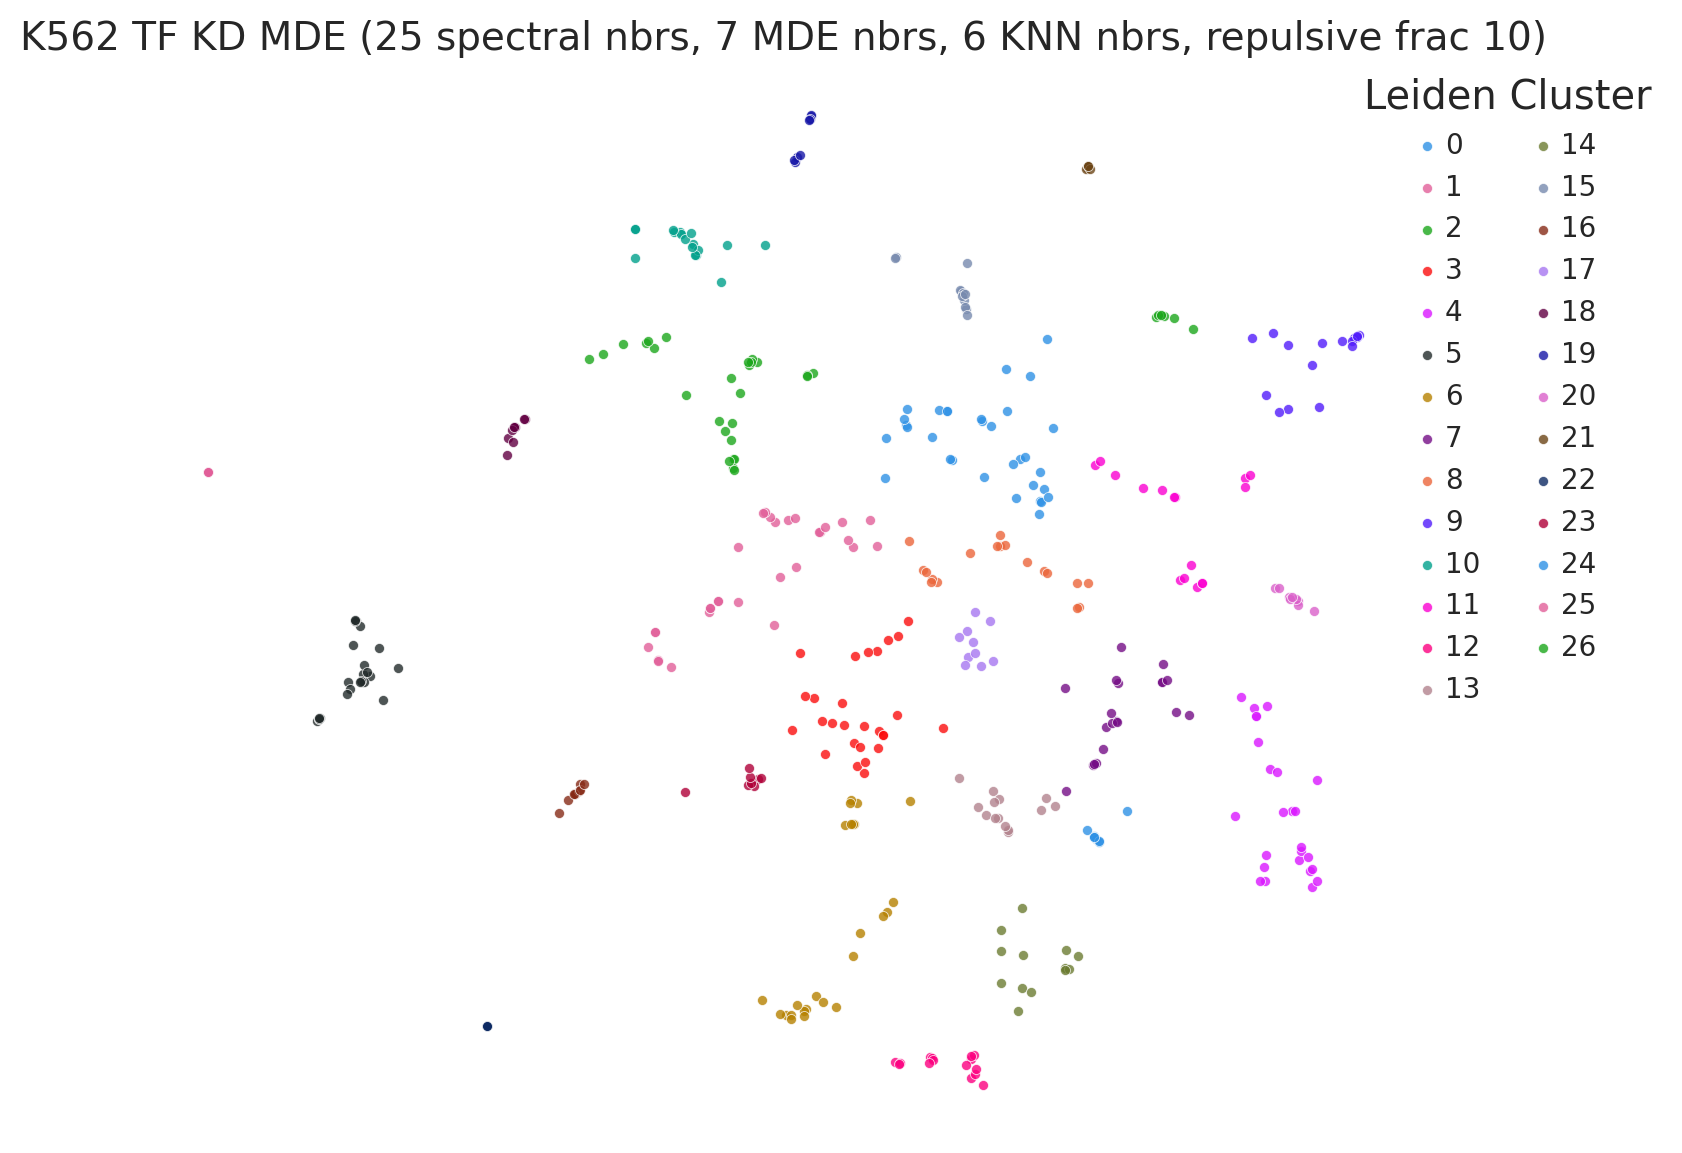

In [61]:
title = "K562 TF KD MDE (25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 10)"
_ = plot_mde_static(mde_embedding, 
                    bulks_mde, 
                    n_neighbors=6, # number of neighbors for KNN graph
                    title_fontsize=14,
                    title=title,
                    legend_ncol=2)

In [ ]:
title = "K562 MDE Leiden/HDBSCAN Clusters (25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 10)"
_ = plot_mde_leiden_hdbscan(mde_embedding, perturbation_HDBSCAN_labels, 
                            bulks_mde, n_neighbors=6, suptitle_fontsize=15,
                            suptitle=title, legend_ncol=2)

In [ ]:
# title="K562 TF KD MDE Leiden Clusters & CORUM Complexes (25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 5)"
# _ = plot_mde_leiden_corum(mde_embedding, bulks_mde, corum_complexes, n_neighbors=6,
#                           suptitle=title)

In [ ]:
title="K562 TF KD Pairwise Distance Matrix of Leiden Cluster Centroids\n(25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 10)"
plot_pairwise_distance_matrix(mde_embedding, bulks_mde, n_neighbors=6, tick_fontsize=11,
                              title=title, title_y_position=1.07)

In [111]:
leiden_cluster_kds = gene_targets_per_cluster(embedding_df, "leiden cluster")
leiden_cluster_kds.head(10)

,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,24,25,26
0,AHCTF1,CREBZF,ARID2,BAZ2B,CDX2,ARID5B,ALX3,CTCFL,FOXI1,ADNP,...,KIN,AKAP8L,FIGLA,AEBP1,DR1,EVX2,CXXC4,FEZF1,CREBL2,ELF4
1,ATF1,E2F1,E2F3,FOS,DLX4,CPEB1,ARID3B,ISL1,GZF1,ADNP2,...,KLF11,CARF,FOXL2,CLOCK,DRAP1,FOXG1,DLX2,IKZF5,FLI1,JAZF1
2,CHAMP1,ELF3,FOXK1,FOXQ1,EMX1,CXXC1,FOXO1,JUNB,MAFK,BHLHE40,...,LIN54,E2F8,HIC2,RFX5,HOXD3,IKZF2,GPBP1L1,KLF9,MTF1,SETDB1
3,ERG,FBXL19,FOXN2,GBX2,FOXD3,DNMT1,HOXA9,MBD1,MYOD1,CEBPG,...,NRL,GTF3A,PRMT3,SP100,PPARA,IRF5,TBX18,KLF15,SNAPC5,SNAPC2
4,FOSL1,FLYWCH1,FOXO4,GLYR1,FOXO3,HHEX,HOXB4,NAIF1,PKNOX1,CHCHD3,...,RUNX3,HMX3,SPI1,TIGD3,SIX6,PRDM5,ZNF20,POU4F1,SP5,ZBTB5
5,FOXM1,FOXN1,MAX,HOXB5,FOXP1,HLF,HOXC4,NKX2-8,SIX2,DMBX1,...,TEAD3,NR2C1,TFDP1,ZNF22,TBPL1,PRDM13,ZNF470,SOHLH2,UNCX,ZNF34
6,GLI4,FOXR2,MEF2A,IRF3,FOXR1,HOXA3,IKZF4,PAX6,SON,DNTTIP1,...,TP73,NR2F2,ZBTB39,ZNF182,ZNF189,TET1,ZNF674,ZNF619,ZBTB44,ZNF557
7,GMEB1,GCM2,MYB,KCNIP3,GRHL1,KLF16,KLF1,PTF1A,TCF15,E4F1,...,XBP1,PA2G4,ZNF71,ZNF211,ZNF317,ZNF326,ZSCAN21,ZNF683,NaN,NaN
8,GPBP1,HNF4A,NRF1,KLF7,HEYL,MEIS3,LHX8,RFX3,ZBTB7A,ETS1,...,ZNF586,ZNF574,ZNF549,ZNF672,NaN,NaN,NaN,NaN,NaN,NaN
9,HMGA1,HSF5,PRDM4,MYPOP,KLF5,MXD4,LYL1,RFX8,ZBTB37,HSF4,...,ZNF718,ZNF787,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [112]:
leiden_filepath = \
    "/home/ranwyl/output_files_tf_project/K562_leiden_clusters_spectral25-mde7-knn6-repulsive10_6-4-26.csv"
leiden_cluster_kds.to_csv(leiden_filepath)

In [ ]:
leiden_filepath = \
    "/home/ranwyl/output_files_tf_project/K562_leiden_clusters_spectral25-mde7-knn6-repulsive10_6-4-26.csv"
leiden_cluster_kds = pd.read_csv(leiden_filepath, header=0, index_col=0)
leiden_cluster_kds.head()

[32, 30, 27, 27, 25, 25, 25, 21, 18, 17, 17, 16, 15, 14, 14, 12, 10, 10, 10, 9, 9, 8, 8, 8, 8, 7, 7]


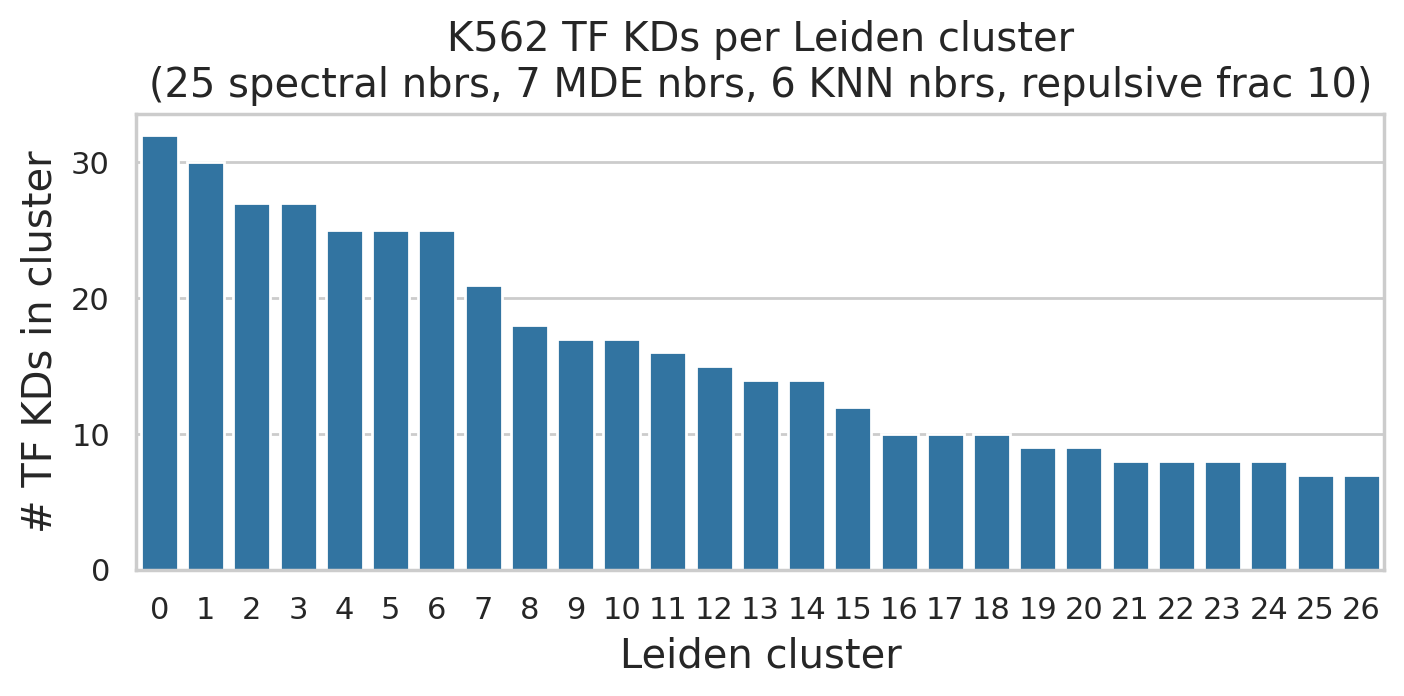

In [63]:
title = "K562 TF KDs per Leiden cluster\n(25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 10)"
plot_n_perts_per_cluster(leiden_cluster_kds, title=title, xlabel="Leiden cluster",
                         figsize=(8,3))

In [64]:
pd.options.display.float_format = '{:,.0f}'.format

In [65]:
leiden_corum_df = find_corum_complexes_in_clusters(corum_perturb, leiden_cluster_kds)
leiden_corum_df

,Leiden cluster,CORUM complex
0,2,FOXO4-SMAD4
1,0,HMGA1-PDX1
2,2,SKIL-SMAD4
3,2,SMAD4-SP1


Which clusters contain KDs of TFs with known functions

In [66]:
erythroid_tfs = ["GATA1", "LDB1", "LMO2", "GATA2", "KLF1", "TAL1", "ZFPM1", "LRF", 
                 "SCL", "MYB", "JUNB", "MYC"]
# GATA2 is downregulated in erythropoiesis
myeloid_tfs = ["SPI1", "CEBPA", "CEBPB", "CEBPE", "GFI1", "RUNX1", "IRF8"]
myeloid_tf_synonyms = ['AML1', 'CBFA2', 'PEPB2A', 'ICSBP']
lymphoid_tfs = ["PAX5", "IKZF1", # B-cell
                "TCF1", "BCL11B", # T-cell
                "GATA3", "ID2"]

In [67]:
print("Erythroid TFs")
find_kds_in_leiden_hdbscan_clusters(erythroid_tfs, leiden_cluster_kds, 
                                    hdbscan_cluster_kds, sort_by="leiden")

Erythroid TFs


,Leiden cluster,HDBSCAN cluster
ZFPM1,1,
MYB,2,7
TAL1,6,6
KLF1,6,
JUNB,7,
GATA1,,
LDB1,,
LMO2,,
GATA2,,
LRF,,


In [68]:
print("Myeloid TFs")
find_kds_in_leiden_hdbscan_clusters(myeloid_tfs, leiden_cluster_kds, 
                                    hdbscan_cluster_kds, sort_by="leiden")

Myeloid TFs


,Leiden cluster,HDBSCAN cluster
CEBPB,14,
SPI1,19,0
CEBPA,,
CEBPE,,
GFI1,,
RUNX1,,
IRF8,,


In [69]:
find_kds_in_leiden_hdbscan_clusters(lymphoid_tfs, leiden_cluster_kds, 
                                    hdbscan_cluster_kds, sort_by="leiden")

,Leiden cluster,HDBSCAN cluster
IKZF1,11,
PAX5,,
TCF1,,
BCL11B,,
GATA3,,
ID2,,


Which clusters contain TF KDs with highest DEG counts?

In [70]:
kds_high_degs = n_degs_df.sort_values(by="n_DEGs", ascending=False).head(20).index.tolist()

In [71]:
find_kds_in_leiden_hdbscan_clusters(kds_high_degs, leiden_cluster_kds,
                                    hdbscan_cluster_kds, sort_by="leiden")

,Leiden cluster,HDBSCAN cluster
MBD3,1,
MAX,2,7
MYB,2,7
NRF1,2,
SP1,2,
CXXC1,5,4
TBP,5,4
ZNF84,5,4
DNMT1,5,
NKX6-1,5,


Which Leiden clusters contain HDBSCAN cluster TF KDs?

In [72]:
hdbscan_tf_kds = hdbscan_cluster_kds.to_numpy().flatten().tolist()
hdbscan_tf_kds = [kd for kd in hdbscan_tf_kds if not isinstance(kd, float)]
print(len(hdbscan_tf_kds))

58


In [73]:
leiden_hdbscan_df = \
    find_kds_in_leiden_hdbscan_clusters(hdbscan_tf_kds, leiden_cluster_kds,
                                    hdbscan_cluster_kds, sort_by="hdbscan")

In [74]:
leiden_hdbscan_df[leiden_hdbscan_df["HDBSCAN cluster"].isin([0, 1, 2, 3])]

,Leiden cluster,HDBSCAN cluster
PRMT3,19,0
SPI1,19,0
TFDP1,19,0
ZBTB39,19,0
DR1,21,1
DRAP1,21,1
TBPL1,21,1
ZNF317,21,1
FLI1,25,2
MTF1,25,2


In [75]:
leiden_hdbscan_df[leiden_hdbscan_df["HDBSCAN cluster"].isin([4, 5])]

,Leiden cluster,HDBSCAN cluster
ERG,0,4
ARID5B,5,4
CPEB1,5,4
CXXC1,5,4
HHEX,5,4
HOXA3,5,4
MYSM1,5,4
TBP,5,4
ZNF84,5,4
ZNF236,5,4


In [76]:
leiden_hdbscan_df[leiden_hdbscan_df["HDBSCAN cluster"].isin([6,7])]

,Leiden cluster,HDBSCAN cluster
PRDM14,1,6
PRDM8,6,6
TAL1,6,6
HMBOX1,16,6
E2F1,1,7
ZNF560,1,7
MAX,2,7
MYB,2,7
PRDM4,2,7
STAT5B,2,7


In [77]:
sns.set_style("whitegrid")

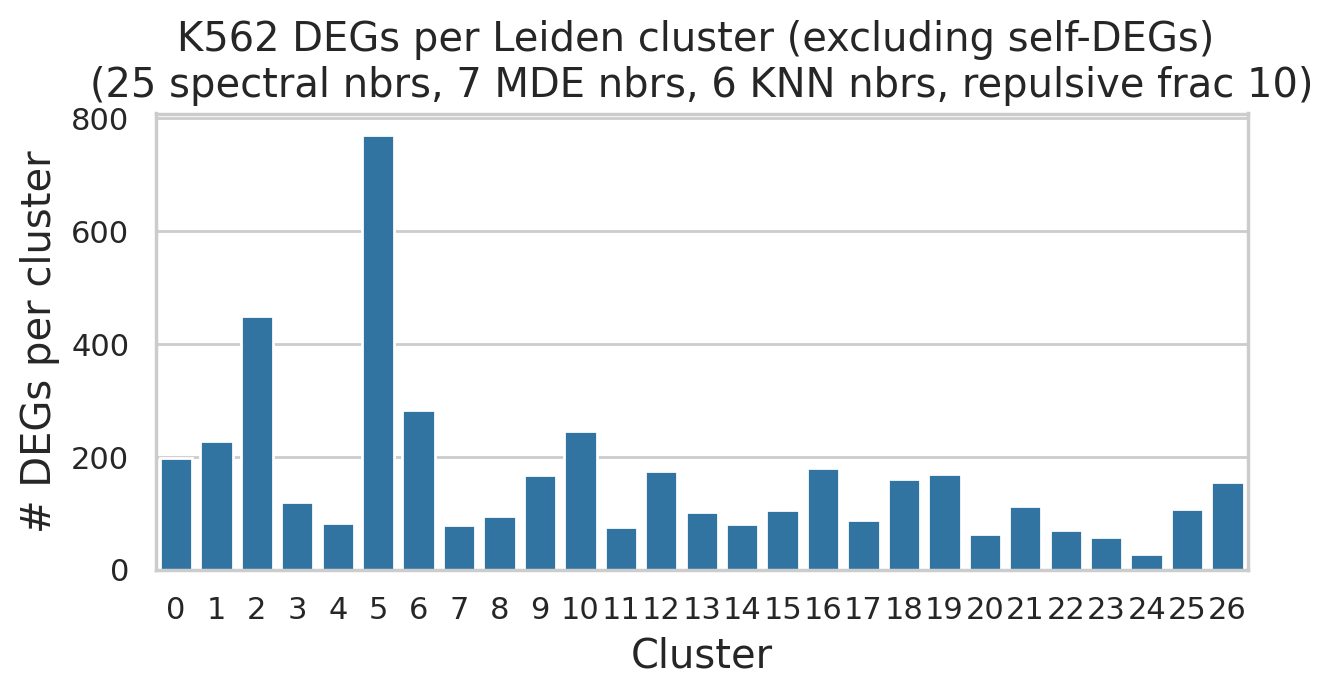

In [78]:
cluster_deg_dict_k562 = build_cluster_DEGs_dict(kd_deg_dict_k562,
                                                leiden_cluster_kds)
title = "K562 DEGs per Leiden cluster (excluding self-DEGs) \n(25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 10)"
_ = plot_n_DEGs_per_cluster(cluster_deg_dict_k562, title=title, figsize=(7,3))

In [79]:
build_n_DEGs_per_cluster_df(cluster_deg_dict_k562)

,n_DEGs
Cluster,
0,197
1,228
2,450
3,120
4,82
5,770
6,283
7,79
8,95


### 9 KNN nbrs

In [85]:
embedding_df = build_mde_df(mde_embedding, bulks_mde, perturbation_HDBSCAN_labels,
                                   n_neighbors=9)

In [ ]:
_ = plot_mde_interactive(mde_embedding, bulks_mde, perturbation_HDBSCAN_labels,
                         n_neighbors=9, # number of neighbors for KNN graph
                         title="K562 TF KD MDE (25 spectral nbrs, 7 MDE nbrs, 9 KNN nbrs, repulsive frac 5)")

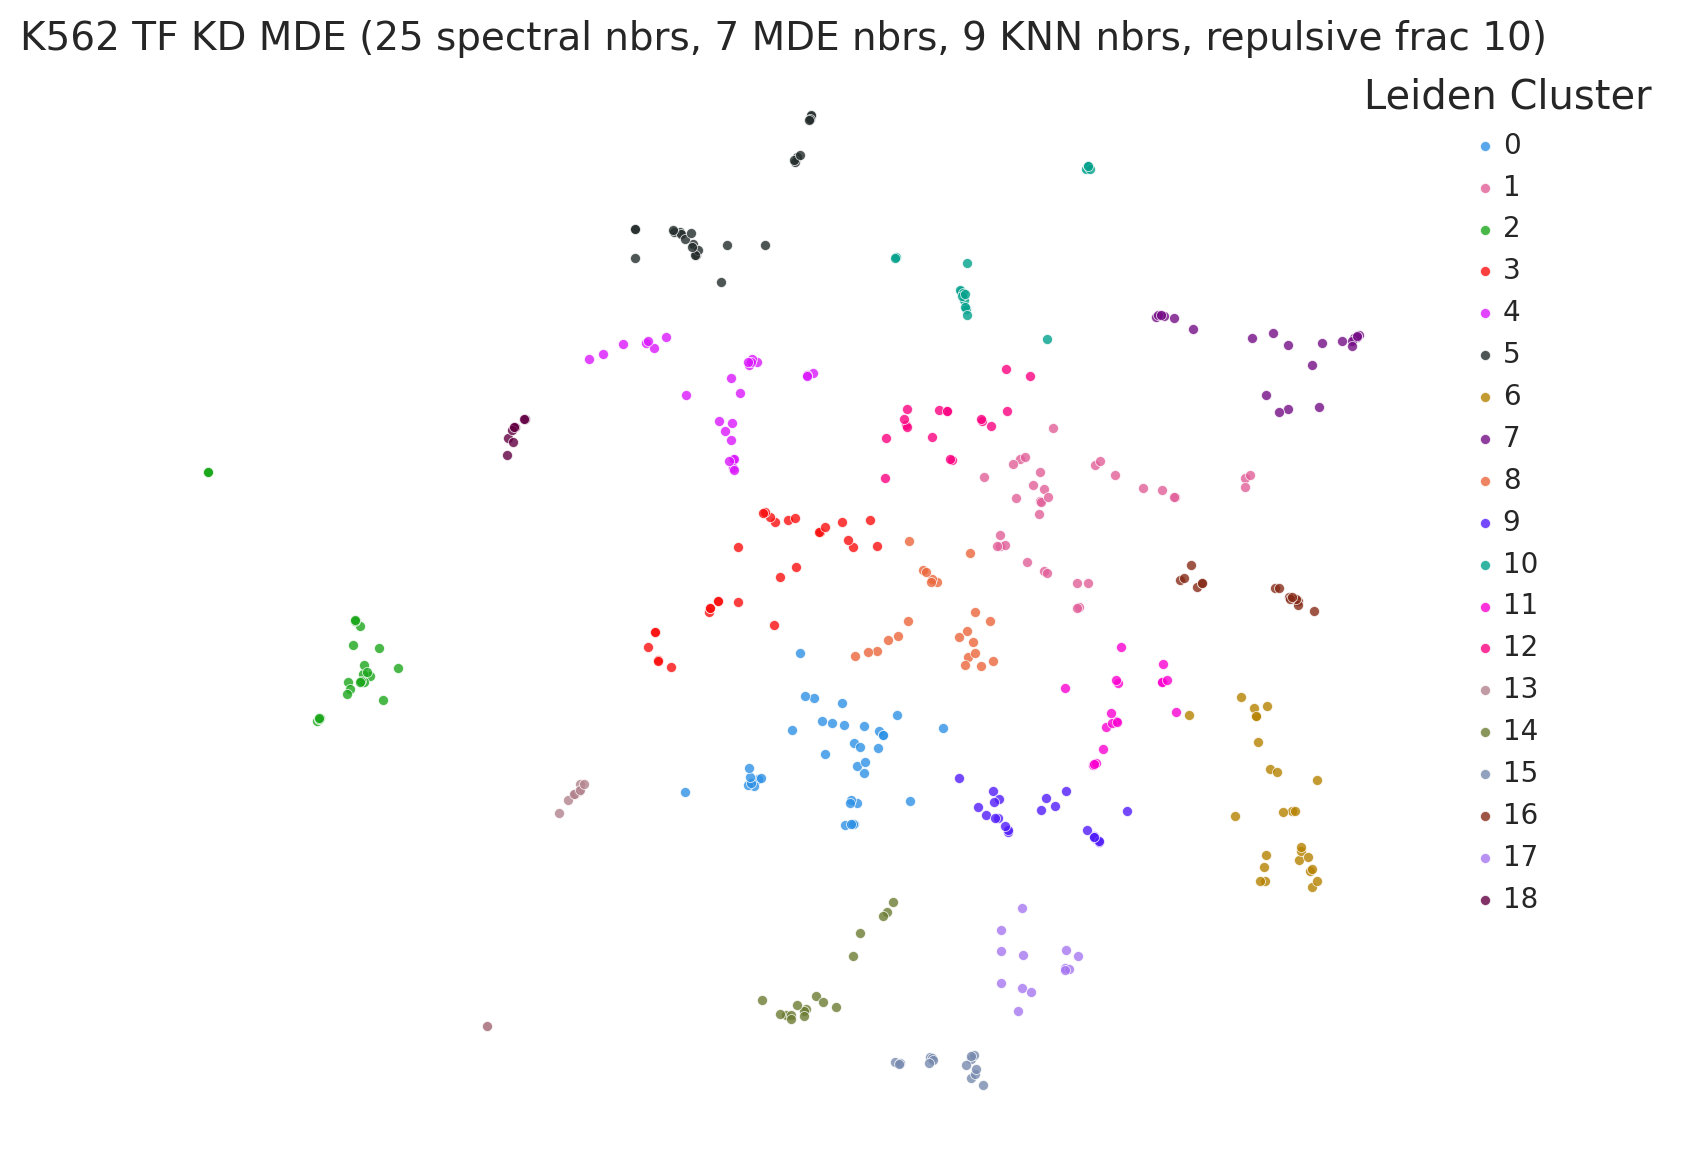

In [87]:
title = "K562 TF KD MDE (25 spectral nbrs, 7 MDE nbrs, 9 KNN nbrs, repulsive frac 10)"
_ = plot_mde_static(mde_embedding, 
                    bulks_mde, 
                    n_neighbors=9, # number of neighbors for KNN graph
                    title_fontsize=14,
                    title=title)

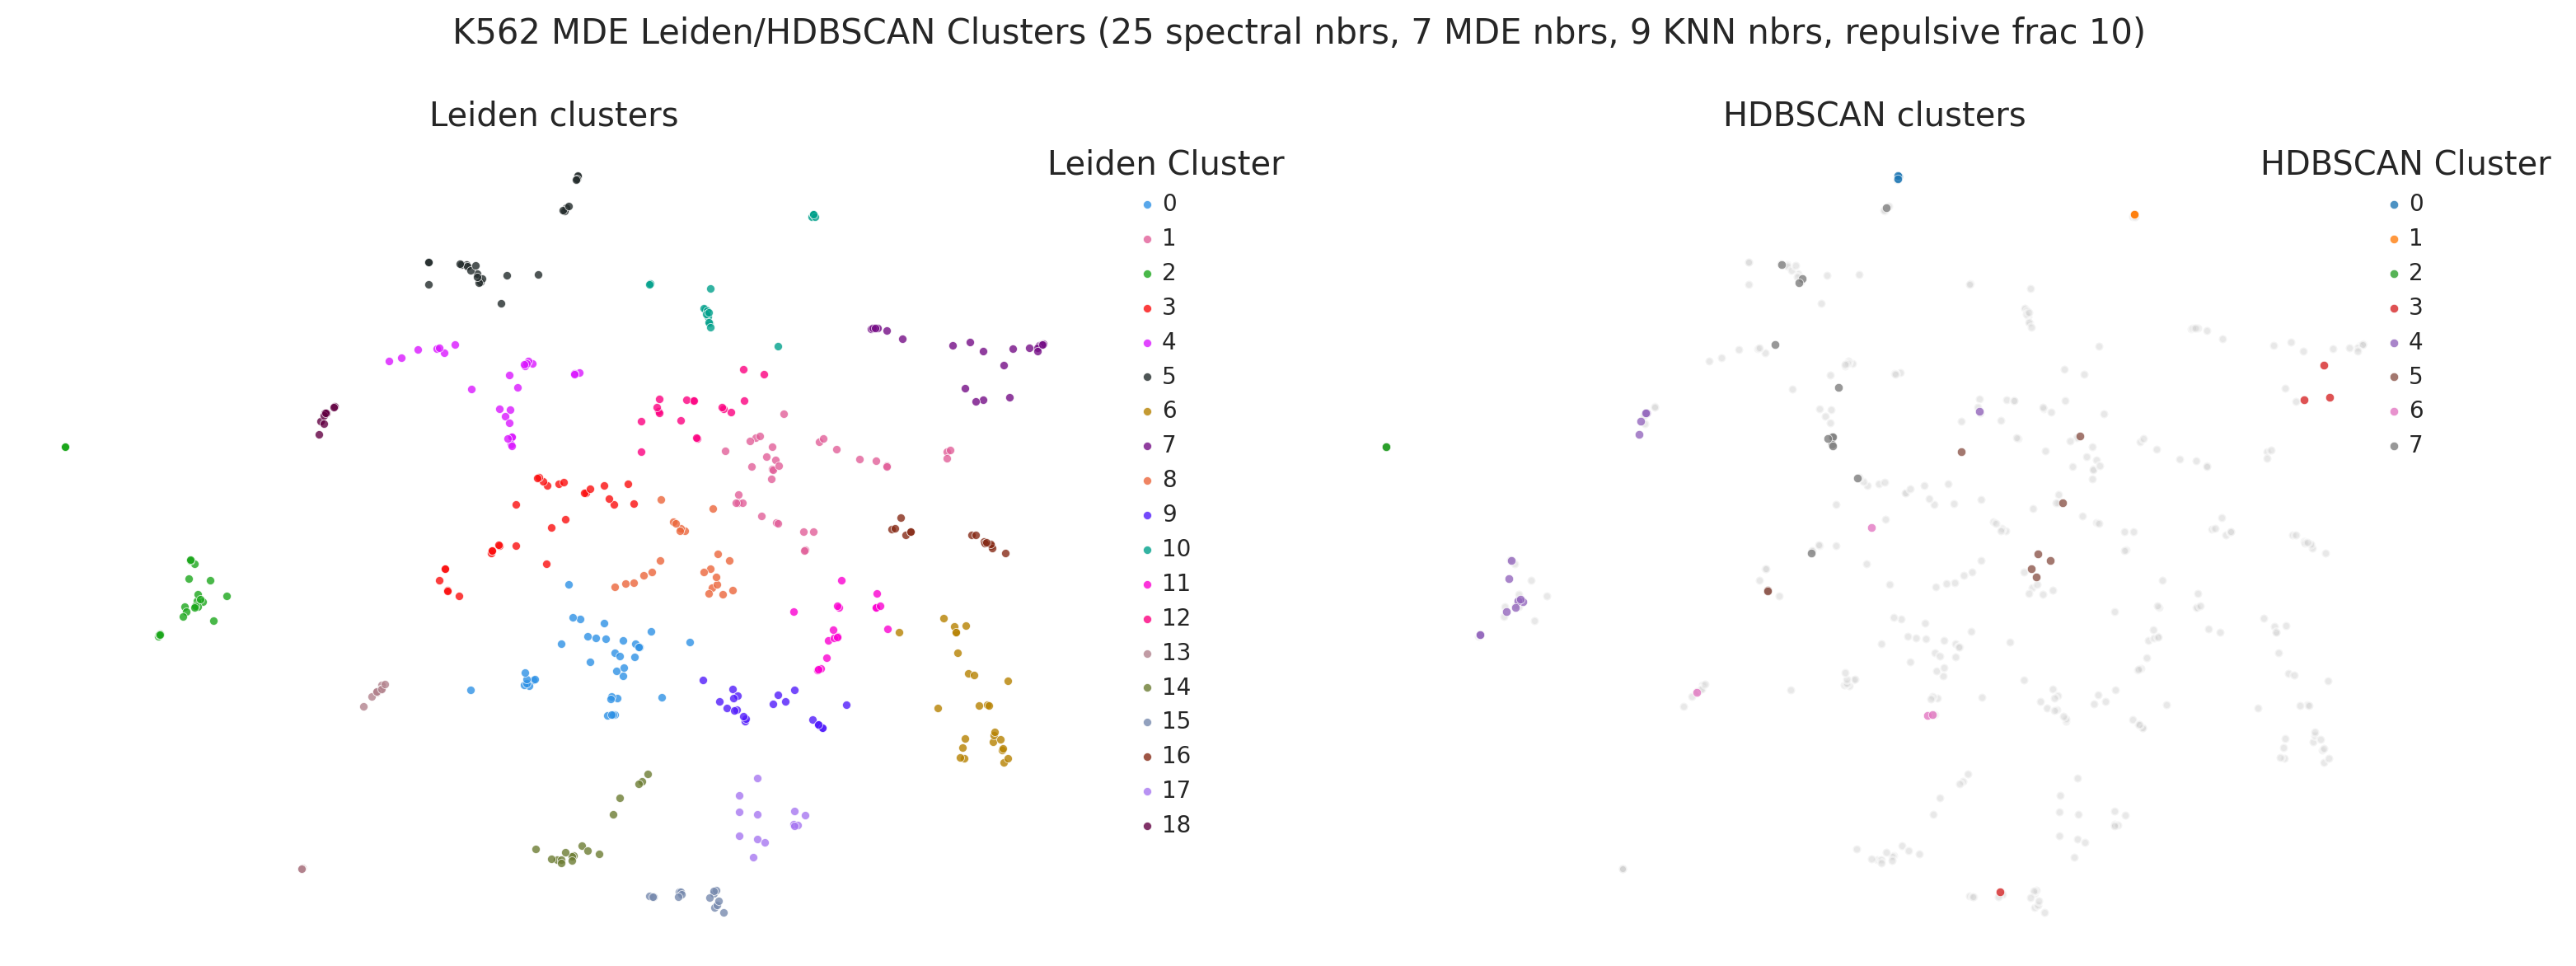

In [88]:
title = "K562 MDE Leiden/HDBSCAN Clusters (25 spectral nbrs, 7 MDE nbrs, 9 KNN nbrs, repulsive frac 10)"
_ = plot_mde_leiden_hdbscan(mde_embedding, perturbation_HDBSCAN_labels, 
                            bulks_mde, n_neighbors=9, suptitle_fontsize=15,
                            suptitle=title)

In [ ]:
# title="K562 TF KD MDE Leiden Clusters & CORUM Complexes (25 spectral nbrs, 7 MDE nbrs, 6 KNN nbrs, repulsive frac 5)"
# _ = plot_mde_leiden_corum(mde_embedding, bulks_mde, corum_complexes, n_neighbors=6,
#                           suptitle=title)

In [ ]:
title="K562 TF KD Pairwise Distance Matrix of Leiden Cluster Centroids\n(25 spectral nbrs, 7 MDE nbrs, 9 KNN nbrs, repulsive frac 10)"
plot_pairwise_distance_matrix(mde_embedding, bulks_mde, n_neighbors=9,
                              title=title, title_y_position=1.07)

In [90]:
leiden_cluster_kds = gene_targets_per_cluster(embedding_df, "leiden cluster")
leiden_cluster_kds.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,ALX3,AHRR,ARID5B,CREBZF,ARID2,ATMIN,CDX2,ADNP,FOS,CTCFL,BACH1,ISL1,AHCTF1,ETV4,ARID3B,FIZ1,AEBP1,BATF,AKAP8L
1,BAZ2B,ATF1,CPEB1,E2F1,E2F3,CAMTA2,DLX4,ADNP2,FOXQ1,FEZF1,BHLHA9,JUNB,CHAMP1,EVX2,FOXO1,IRF1,CLOCK,CEBPB,CARF
2,CXXC4,FOXI1,CREBL2,ELF3,FOXK1,CENPT,EMX1,BHLHE40,GLYR1,FOXI3,DR1,MBD1,ERG,FOXG1,HOXA9,KCMF1,KLF12,FOXD4L1,E2F8
3,DLX2,FOXM1,CXXC1,FBXL19,FOXN2,FIGLA,FOXD3,CEBPG,GZF1,HEY1,DRAP1,NAIF1,GMEB1,HMBOX1,HOXB4,LIN28B,NEUROG2,HIC1,GTF3A
4,GBX2,GLI4,DNMT1,FLYWCH1,FOXO4,FOXL2,FOXO3,CHCHD3,KIN,IKZF5,FOSL1,NKX2-8,GPBP1,IKZF2,IKZF4,MAFA,RFX1,LIN28A,HMX3
5,GPBP1L1,HES4,FLI1,FOXN1,MAX,FOXS1,FOXP1,DMBX1,KLF11,KLF9,GSC,PAX6,HOXB6,IRF5,KLF1,POU3F1,RFX5,MAFB,NR2C1
6,HOXB5,HMGA1,HHEX,FOXR2,MEF2A,HIC2,FOXR1,DNTTIP1,LIN54,KLF10,GTF2IRD2,PTF1A,HSFX1,MSANTD4,LYL1,SRF,SP100,MAFF,NR2F2
7,HOXC4,HNF4G,HLF,GCM2,MYB,HINFP,GRHL1,E4F1,NRL,KLF15,HOXD3,RFX3,IRX1,PRDM5,NFYA,TSHZ2,TIGD3,MAFG,PA2G4
8,IRF3,HOXA10,HOXA3,HNF4A,NRF1,KAT7,HEYL,ELF4,PKNOX1,MGA,INSM2,RFX8,IRX2,PRDM13,PAX2,YY1,ZBTB48,OVOL1,ZNF574
9,KCNIP3,HOXB8,KLF16,HSF5,PRDM4,NFIC,KLF5,ETS1,PRR12,NKX2-6,LBX1,TCF24,NR2C2,RBPJL,POU2F2,ZBTB1,ZNF22,ZNF335,ZNF787


In [109]:
leiden_filepath = \
    "/home/ranwyl/output_files_tf_project/K562_leiden_clusters_spectral25-mde7-knn9-repulsive10_6-4-26.csv"
leiden_cluster_kds.to_csv(leiden_filepath)

In [ ]:
leiden_filepath = \
    "/home/ranwyl/output_files_tf_project/K562_leiden_clusters_spectral25-mde7-knn9-repulsive10_6-4-26.csv"
leiden_cluster_kds = pd.read_csv(leiden_filepath, header=0, index_col=0)
leiden_cluster_kds.head()

[37, 34, 32, 30, 27, 26, 26, 24, 23, 23, 21, 19, 18, 18, 17, 15, 15, 14, 10]


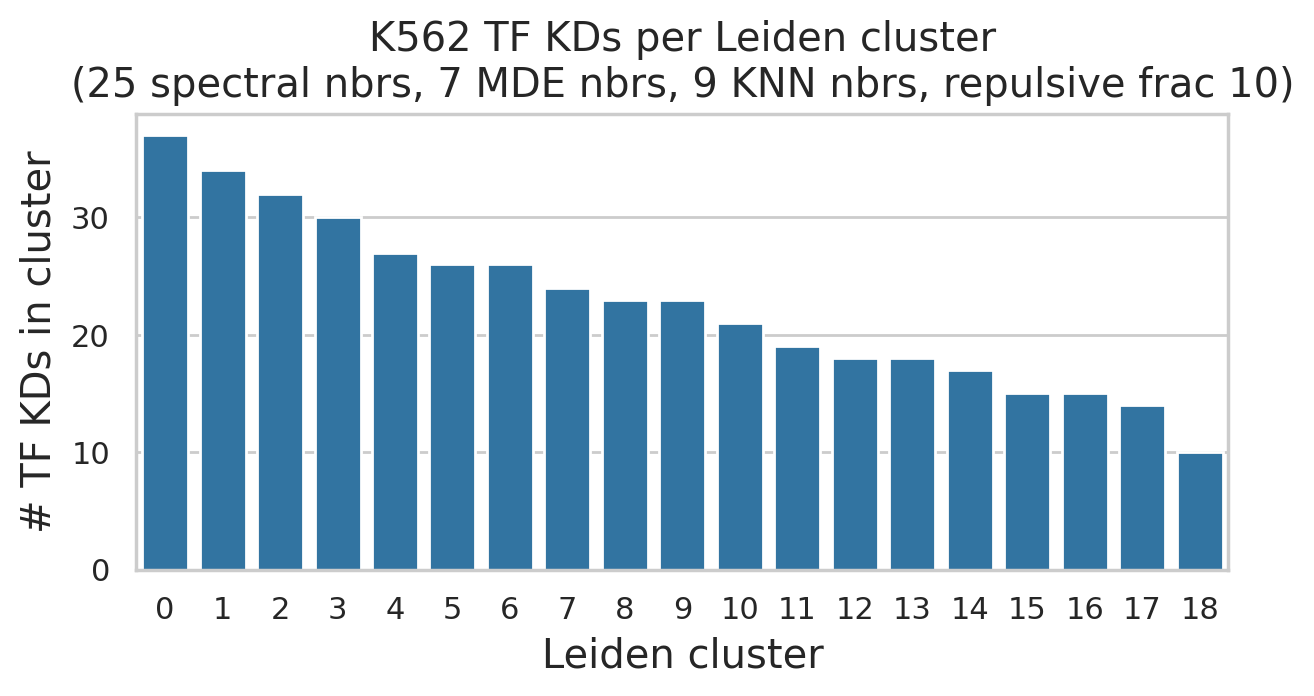

In [91]:
title = "K562 TF KDs per Leiden cluster\n(25 spectral nbrs, 7 MDE nbrs, 9 KNN nbrs, repulsive frac 10)"
plot_n_perts_per_cluster(leiden_cluster_kds, title=title, xlabel="Leiden cluster",
                         figsize=(6,3))

In [93]:
pd.options.display.float_format = '{:,.0f}'.format

In [94]:
leiden_corum_df = find_corum_complexes_in_clusters(corum_perturb, leiden_cluster_kds)
leiden_corum_df

,Leiden cluster,CORUM complex
0,4,FOXO4-SMAD4
1,1,HMGA1-PDX1
2,4,SKIL-SMAD4
3,4,SMAD4-SP1


Which clusters contain KDs of TFs with known functions

In [95]:
erythroid_tfs = ["GATA1", "LDB1", "LMO2", "GATA2", "KLF1", "TAL1", "ZFPM1", "LRF", 
                 "SCL", "MYB", "JUNB", "MYC"]
# GATA2 is downregulated in erythropoiesis
myeloid_tfs = ["SPI1", "CEBPA", "CEBPB", "CEBPE", "GFI1", "RUNX1", "IRF8"]
myeloid_tf_synonyms = ['AML1', 'CBFA2', 'PEPB2A', 'ICSBP']
lymphoid_tfs = ["PAX5", "IKZF1", # B-cell
                "TCF1", "BCL11B", # T-cell
                "GATA3", "ID2"]

In [96]:
print("Erythroid TFs")
find_kds_in_leiden_hdbscan_clusters(erythroid_tfs, leiden_cluster_kds, 
                                    hdbscan_cluster_kds, sort_by="leiden")

Erythroid TFs


,Leiden cluster,HDBSCAN cluster
TAL1,0,6
ZFPM1,3,
MYB,4,7
JUNB,11,
KLF1,14,
GATA1,,
LDB1,,
LMO2,,
GATA2,,
LRF,,


In [97]:
print("Myeloid TFs")
find_kds_in_leiden_hdbscan_clusters(myeloid_tfs, leiden_cluster_kds, 
                                    hdbscan_cluster_kds, sort_by="leiden")

Myeloid TFs


,Leiden cluster,HDBSCAN cluster
SPI1,5,0
CEBPB,17,
CEBPA,,
CEBPE,,
GFI1,,
RUNX1,,
IRF8,,


In [98]:
find_kds_in_leiden_hdbscan_clusters(lymphoid_tfs, leiden_cluster_kds, 
                                    hdbscan_cluster_kds, sort_by="leiden")

,Leiden cluster,HDBSCAN cluster
IKZF1,1,
PAX5,,
TCF1,,
BCL11B,,
GATA3,,
ID2,,


Which clusters contain TF KDs with highest DEG counts?

In [99]:
kds_high_degs = n_degs_df.sort_values(by="n_DEGs", ascending=False).head(20).index.tolist()

In [100]:
find_kds_in_leiden_hdbscan_clusters(kds_high_degs, leiden_cluster_kds,
                                    hdbscan_cluster_kds, sort_by="leiden")

,Leiden cluster,HDBSCAN cluster
CXXC1,2,4
TBP,2,4
ZNF84,2,4
DNMT1,2,
NKX6-1,2,
ZBTB17,2,
MBD3,3,
MAX,4,7
MYB,4,7
NRF1,4,


Which Leiden clusters contain HDBSCAN cluster TF KDs?

In [101]:
hdbscan_tf_kds = hdbscan_cluster_kds.to_numpy().flatten().tolist()
hdbscan_tf_kds = [kd for kd in hdbscan_tf_kds if not isinstance(kd, float)]
print(len(hdbscan_tf_kds))

58


In [102]:
leiden_hdbscan_df = \
    find_kds_in_leiden_hdbscan_clusters(hdbscan_tf_kds, leiden_cluster_kds,
                                    hdbscan_cluster_kds, sort_by="hdbscan")

In [103]:
leiden_hdbscan_df[leiden_hdbscan_df["HDBSCAN cluster"].isin([0, 1, 2, 3])]

,Leiden cluster,HDBSCAN cluster
PRMT3,5,0
SPI1,5,0
TFDP1,5,0
ZBTB39,5,0
DR1,10,1
DRAP1,10,1
TBPL1,10,1
ZNF317,10,1
FLI1,2,2
MTF1,2,2


In [104]:
leiden_hdbscan_df[leiden_hdbscan_df["HDBSCAN cluster"].isin([4, 5])]

,Leiden cluster,HDBSCAN cluster
ARID5B,2,4
CPEB1,2,4
CXXC1,2,4
HHEX,2,4
HOXA3,2,4
MYSM1,2,4
TBP,2,4
ZNF84,2,4
ZNF236,2,4
ERG,12,4


In [105]:
leiden_hdbscan_df[leiden_hdbscan_df["HDBSCAN cluster"].isin([6,7])]

,Leiden cluster,HDBSCAN cluster
PRDM8,0,6
TAL1,0,6
PRDM14,3,6
HMBOX1,13,6
E2F1,3,7
ZNF560,3,7
MAX,4,7
MYB,4,7
PRDM4,4,7
STAT5B,4,7


In [106]:
sns.set_style("whitegrid")

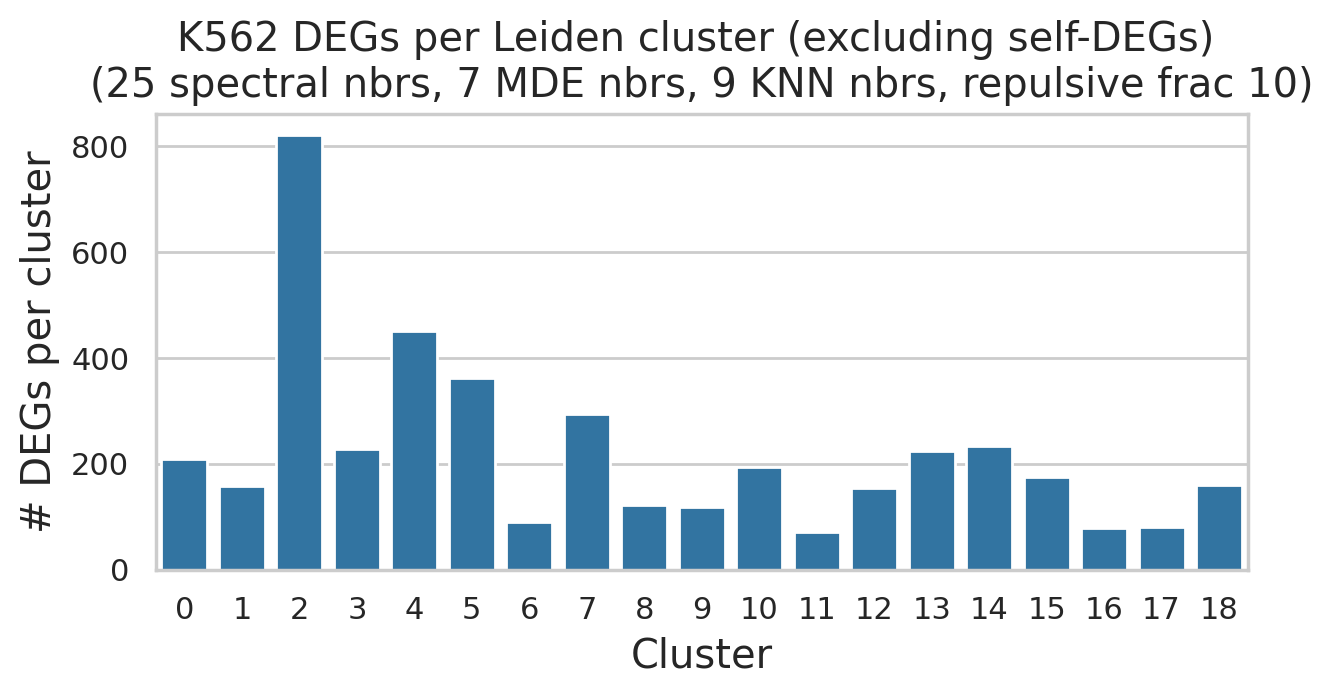

In [107]:
cluster_deg_dict_k562 = build_cluster_DEGs_dict(kd_deg_dict_k562,
                                                leiden_cluster_kds)
title = "K562 DEGs per Leiden cluster (excluding self-DEGs) \n(25 spectral nbrs, 7 MDE nbrs, 9 KNN nbrs, repulsive frac 10)"
_ = plot_n_DEGs_per_cluster(cluster_deg_dict_k562, title=title, figsize=(7,3))

In [108]:
build_n_DEGs_per_cluster_df(cluster_deg_dict_k562)

,n_DEGs
Cluster,
0,208
1,158
2,820
3,228
4,450
5,361
6,90
7,294
8,122


## MDE (7 spectral nbrs, 7 MDE nbrs)

In [80]:
mde_embedding = embed_spectral_mde(mp_standardized, 
                                    n_components=20,
                                    spectral_n_neighbors=7,
                                    mde_n_neighbors=7, 
                                    repulsive_fraction=5)

Jun 03 11:55:58 PM: Your dataset appears to contain duplicated items (rows); when embedding, you should typically have unique items.
Jun 03 11:55:58 PM: The following items have duplicates [194 366]
Jun 03 11:55:58 PM: Fitting a centered embedding into R^2, for a graph with 429 items and 12779 edges.
Jun 03 11:55:58 PM: `embed` method parameters: eps=1.0e-09, max_iter=2000, memory_size=10
Jun 03 11:55:58 PM: iteration 0000 | distortion 0.379041 | residual norm 0.0334119 | step length 5.505 | percent change 0.627932
Jun 03 11:55:59 PM: iteration 0200 | distortion 0.147797 | residual norm 0.000242163 | step length 1 | percent change 0.544478
Jun 03 11:56:00 PM: iteration 0400 | distortion 0.147353 | residual norm 0.000139364 | step length 1 | percent change 0.199412
Jun 03 11:56:00 PM: iteration 0600 | distortion 0.147217 | residual norm 0.000145475 | step length 1 | percent change 0.161219
Jun 03 11:56:01 PM: iteration 0800 | distortion 0.146937 | residual norm 1.77843e-05 | step length

Jun 03 11:56:06 PM: iteration 1200 | distortion 0.146936 | residual norm 1.75573e-05 | step length 0 | percent change 0
Jun 03 11:56:09 PM: iteration 1400 | distortion 0.146936 | residual norm 1.75573e-05 | step length 0 | percent change 0
Jun 03 11:56:12 PM: iteration 1600 | distortion 0.146936 | residual norm 1.75573e-05 | step length 0 | percent change 0
Jun 03 11:56:15 PM: iteration 1800 | distortion 0.146936 | residual norm 1.75573e-05 | step length 0 | percent change 0
Jun 03 11:56:18 PM: iteration 1999 | distortion 0.146936 | residual norm 1.75573e-05 | step length 0 | percent change 0
Jun 03 11:56:18 PM: Finished fitting in 19.828 seconds and 2000 iterations.
Jun 03 11:56:18 PM: average distortion 0.147 | residual norm 1.8e-05


In [83]:
mde_embedding = embed_spectral_mde(mp_standardized, 
                                    n_components=20,
                                    spectral_n_neighbors=7,
                                    mde_n_neighbors=7, 
                                    repulsive_fraction=10)

Jun 03 11:57:18 PM: Your dataset appears to contain duplicated items (rows); when embedding, you should typically have unique items.
Jun 03 11:57:18 PM: The following items have duplicates [194 366]
Jun 03 11:57:18 PM: Fitting a centered embedding into R^2, for a graph with 429 items and 23407 edges.
Jun 03 11:57:18 PM: `embed` method parameters: eps=1.0e-09, max_iter=2000, memory_size=10
Jun 03 11:57:18 PM: iteration 0000 | distortion 0.396546 | residual norm 0.04544 | step length 1 | percent change 0.155129
Jun 03 11:57:19 PM: iteration 0200 | distortion 0.101093 | residual norm 0.000157012 | step length 1 | percent change 0.511845
Jun 03 11:57:20 PM: iteration 0400 | distortion 0.100882 | residual norm 2.83238e-05 | step length 1 | percent change 0.00438188
Jun 03 11:57:21 PM: iteration 0600 | distortion 0.100863 | residual norm 3.36336e-05 | step length 1 | percent change 0.0244146


Jun 03 11:57:22 PM: iteration 0800 | distortion 0.100739 | residual norm 3.48755e-05 | step length 1 | percent change 0.0218288
Jun 03 11:57:25 PM: iteration 1000 | distortion 0.100736 | residual norm 9.45346e-06 | step length 0 | percent change 0
Jun 03 11:57:29 PM: iteration 1200 | distortion 0.100736 | residual norm 9.45346e-06 | step length 0 | percent change 0
Jun 03 11:57:33 PM: iteration 1400 | distortion 0.100736 | residual norm 9.45346e-06 | step length 0 | percent change 0
Jun 03 11:57:37 PM: iteration 1600 | distortion 0.100736 | residual norm 9.45346e-06 | step length 0 | percent change 0
Jun 03 11:57:41 PM: iteration 1800 | distortion 0.100736 | residual norm 9.45346e-06 | step length 0 | percent change 0
Jun 03 11:57:45 PM: iteration 1999 | distortion 0.100736 | residual norm 9.45346e-06 | step length 0 | percent change 0
Jun 03 11:57:45 PM: Finished fitting in 27.236 seconds and 2000 iterations.
Jun 03 11:57:45 PM: average distortion 0.101 | residual norm 9.5e-06
